## 1. Carga y configuración inicial

Antes de comenzar, vamos a importar todas las librerías a utilizar con el objetivo de tener la libreta organizada desde el principio:

In [1]:
# Standard
import warnings

# Third party
import matplotlib.pyplot as plt
import missingno as msno
import pandas as pd
import seaborn as sns
from sklearn import set_config
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import json

Además, configuramos la visualización de las gráficas:

In [2]:
%matplotlib inline
figsize = (12, 7)  # Width, height in inches
palette = "colorblind"  # Palette definition
plt.rcParams["figure.figsize"] = figsize
sns.set_palette(palette)

A su vez, fijamos una semilla para que los experimentos sean reproducibles:

In [3]:
random_state = seed = 41686

Vamos a indicarle a `scikit-learn` que la salida de sus transformadores sea un `DataFrame` de `pandas` siempre que sea posible, en lugar de un `array` de `NumPy` (que es el comportamiento por defecto). Hacemos esto ahora porque, aunque no afecta al modelo final, hace que el **proceso de definir y depurar los pasos de preprocesamiento sea mucho más cómodo**. Nos permitirá inspeccionar la salida de nuestros `Pipeline` en cualquier etapa y ver un `DataFrame` con nombres de columna legibles, facilitando la verificación de que nuestra lógica es correcta, en lugar de tener que descifrar un `array` numérico anónimo.

In [4]:
transform_output = "pandas"  # Pandas output
set_config(transform_output=transform_output)

Por último, filtramos los mensajes de advertencia para evitar salidas demasiado largas en la libreta:

In [5]:
action = "ignore"  # Never print matching warnings
warnings.filterwarnings(action)

## 2. Carga de datos


In [6]:
file = "/home/victor/Descargas/xmas_merged_data.json"
parameters = []  # Example: ["cbmac_details.cbmac_load", "buffer_usage.average"]

print("Processing Data...")

batch_size = 100_000  # número de líneas por lote
batches = []  # para acumulación temporal

for i, line in enumerate(open(file, "r", encoding="utf-8"), start=1):
    line = line.strip()
    if not line:
        continue
    try:
        obj = json.loads(line)
        batches.append(obj)
    except json.JSONDecodeError:
        continue

    # cada cierto número de líneas, convertimos y guardamos en disco o acumulamos
    if len(batches) >= batch_size:
        batch_df = pd.json_normalize(batches)
        if i == batch_size:
            data = batch_df  # primer lote
        else:
            data = pd.concat([data, batch_df], ignore_index=True)
        batches.clear()
        print(f"Procesadas {i:,} líneas...")

# procesar el resto
if batches:
    batch_df = pd.json_normalize(batches)
    data = pd.concat([data, batch_df], ignore_index=True) if "data" in locals() else batch_df

try:
    for col in data.select_dtypes(include=["int64", "float64"]).columns:
        if data[col].min() >= -32768 and data[col].max() <= 32767:
            data[col] = data[col].astype("Int16")
        else:
            print(f"⚠️  Columna {col} no cabe en int16")
except Exception as e:
    print(f"⚠️  Error al convertir tipos numéricos: {e}")

Processing Data...
Procesadas 100,000 líneas...
Procesadas 200,000 líneas...
Procesadas 300,000 líneas...
Procesadas 400,000 líneas...
Procesadas 500,000 líneas...
Procesadas 600,000 líneas...
Procesadas 700,000 líneas...
Procesadas 800,000 líneas...
Procesadas 900,000 líneas...
Procesadas 1,000,000 líneas...
Procesadas 1,100,000 líneas...
Procesadas 1,200,000 líneas...
Procesadas 1,300,000 líneas...
Procesadas 1,400,000 líneas...
Procesadas 1,500,000 líneas...
Procesadas 1,600,000 líneas...
Procesadas 1,700,000 líneas...
Procesadas 1,800,000 líneas...
Procesadas 1,900,000 líneas...
Procesadas 2,000,000 líneas...
Procesadas 2,100,000 líneas...
Procesadas 2,200,000 líneas...
Procesadas 2,300,000 líneas...
Procesadas 2,400,000 líneas...
Procesadas 2,500,000 líneas...
Procesadas 2,600,000 líneas...
Procesadas 2,700,000 líneas...
Procesadas 2,800,000 líneas...
Procesadas 2,900,000 líneas...
Procesadas 3,000,000 líneas...
⚠️  Columna travel_ms no cabe en int16
⚠️  Columna msg_id no cabe en 

In [7]:
print(data.head())
print(data.columns)

   travel_ms  src  src_ep  hops    msg_id  msg_type   msg_class        type  \
0       39.0  144       1     6  225523.0         0  StatusData  StatusData   
1       39.0  122       1     8  225518.0         0  StatusData  StatusData   
2        7.0  193       1     4  181152.0         0  StatusData  StatusData   
3       23.0   35       1     7  225517.0         0  StatusData  StatusData   
4       15.0   54       1     4  225517.0         0  StatusData  StatusData   

   state  outputState  ...  events.event11  cbmac_details  buffer_usage  \
0      1        16641  ...            <NA>            NaN           NaN   
1      1        16641  ...            <NA>            NaN           NaN   
2      1         4353  ...            <NA>            NaN           NaN   
3      1        16641  ...            <NA>            NaN           NaN   
4      1        16641  ...            <NA>            NaN           NaN   

   nexthop_details  Installation quality  events.event12  events.event13  

### 2.1. División estratégica: conjuntos de entrenamiento y prueba

Antes de transformar o analizar en profundidad cualquier dato, debemos realizar el paso metodológico más importante: **separar nuestro conjunto de datos en entrenamiento y prueba**.

#### **¿Por qué ahora?**

Para garantizar una evaluación honesta y robusta de nuestro modelo.

* El conjunto de **entrenamiento** (`X_train`, `y_train`) será utilizado para *todo*: análisis exploratorio, imputación de valores faltantes, detección de valores extremos, escalado y, por supuesto, el entrenamiento del modelo.
* El conjunto de **prueba** (`X_test`, `y_test`) se mantendrá "guardado bajo llave" y completamente intacto. No lo miraremos ni lo usaremos para tomar ninguna decisión de preprocesamiento.

De esta forma, simulamos un escenario real donde el modelo se enfrenta a datos que nunca ha visto, previniendo el ***data leakage*** (fuga de datos). Si calculáramos, por ejemplo, la media para escalar usando el conjunto de datos completo, el conjunto de prueba ya habría "contaminado" nuestro preprocesamiento.

Usaremos una división estratificada (`stratify = y`) para asegurar que la proporción de `"yes"` y `"no"` sea la misma tanto en el conjunto de entrenamiento como en el de prueba, lo cual es vital en problemas de clasificación (especialmente si están desbalanceados).

In [8]:
test_size = 0.2  # Proportion of the dataset to include in the test split

X_train, X_test = train_test_split(data, test_size=test_size, random_state=random_state)

In [9]:
n = 5
X_train.sample(n, random_state=random_state)

,travel_ms,src,src_ep,hops,msg_id,msg_type,msg_class,type,state,outputState,...,events.event11,cbmac_details,buffer_usage,nexthop_details,Installation quality,events.event12,events.event13,events.event14,events.event15,trace_options
1123301,70.0,181,1,6,235245.0,0,StatusData,StatusData,1,16641,...,<NA>,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,NaN
1807952,23.0,111,1,4,242017.0,0,StatusData,StatusData,1,257,...,<NA>,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,NaN
2884359,15.0,87,1,6,20312.0,0,StatusData,StatusData,1,16641,...,<NA>,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,NaN
2319067,23.0,43,1,9,36611.0,0,StatusData,StatusData,1,16641,...,<NA>,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,NaN
2655396,15.0,8,1,4,215959.0,0,StatusData,StatusData,1,16641,...,<NA>,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,NaN


In [10]:
X_test.sample(n, random_state=random_state)

,travel_ms,src,src_ep,hops,msg_id,msg_type,msg_class,type,state,outputState,...,events.event11,cbmac_details,buffer_usage,nexthop_details,Installation quality,events.event12,events.event13,events.event14,events.event15,trace_options
632976,23.0,79,1,5,231043.0,0,StatusData,StatusData,1,16641,...,<NA>,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,NaN
2740062,93.0,189,1,10,166572.0,0,StatusData,StatusData,1,257,...,<NA>,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,NaN
169455,7.0,4,1,2,226985.0,0,StatusData,StatusData,1,257,...,<NA>,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,NaN
555731,39.0,123,1,11,85064.0,0,StatusData,StatusData,1,16641,...,<NA>,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,NaN
1690871,78.0,162,1,2,241018.0,0,StatusData,StatusData,1,16641,...,<NA>,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,NaN


Las proporciones de la clase objetivo son casi idénticas en ambos conjuntos.

**A partir de este punto, guardamos `X_test` y `y_test` y nos olvidamos de ellos hasta la evaluación final.**

Todo el análisis y preprocesamiento se realizará **únicamente** sobre `X_train` y `y_train`.

## 3. Análisis exploratorio de datos

Ahora que hemos aislado nuestros datos de prueba, comienza el verdadero trabajo de preprocesamiento. Todo el análisis, decisiones y transformaciones se basarán **únicamente** en `X_train` y `y_train`.

Nuestro primer paso es un análisis exploratorio de datos profundo para entender la naturaleza de nuestras variables.

## 3.2. Análisis de las variables predictoras

#### 3.2.1. Numéricas

Ahora, veamos las variables numéricas en `X_train`. Usaremos `.describe()` para obtener estadísticas clave. Buscamos:

* **Escalas:** Diferencias drásticas en los rangos.
* **Valores extremos:** Diferencias grandes entre el 75% (`Q3`) y el máximo (`max`).
* **Asimetría:** Si la media es muy diferente de la mediana (`Q2`).

In [11]:
include = ["number"]  # Data types to include
numerical_features = X_train.select_dtypes(include=include).columns.tolist()

In [12]:
pd.set_option('display.max_rows', None)      # muestra todas las filas
pd.set_option('display.max_columns', None)   # muestra todas las columnas
pd.set_option('display.width', 2000)         # ancho total para evitar saltos
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:.0f}'.format)
X_train[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
travel_ms,2405118,37,563,0,15,23,39,247437
src,2417536,102,88,4,39,90,149,1000
src_ep,2405118,1,0,1,1,1,1,4
hops,2405118,5,2,1,3,5,7,15
msg_id,2405118,185791,192382,0,45769,214132,229947,1499258
msg_type,2405118,0,0,0,0,0,0,3
state,2404552,1,0,0,1,1,1,11
outputState,2404552,14457,5441,0,16641,16641,16641,16657
inputState,2404487,0,0,0,0,0,0,1
error,2404487,115,39,0,128,128,128,193


La tabla `.describe()` ya nos da pistas claras.

Lo primero que observamos es el `count`: para todas las variables numéricas, el `count` coincide exactamente con el número total de instancias en nuestro conjunto de entrenamiento, lo que indica que no existen valores perdidos explícitos (`NaN`).

Aunque estas estadísticas son increíblemente útiles para una detección rápida, no nos muestran la *forma* completa de la distribución. Un solo valor extremo puede sesgar la media, pero un histograma nos muestra *cuántos* valores extremos hay y cómo de "larga" es esa cola.

Para confirmar esto visualmente, podemos ayudarnos de **histogramas** (para ver la distribución y asimetría) y **diagramas de caja** (para identificar valores extremos).

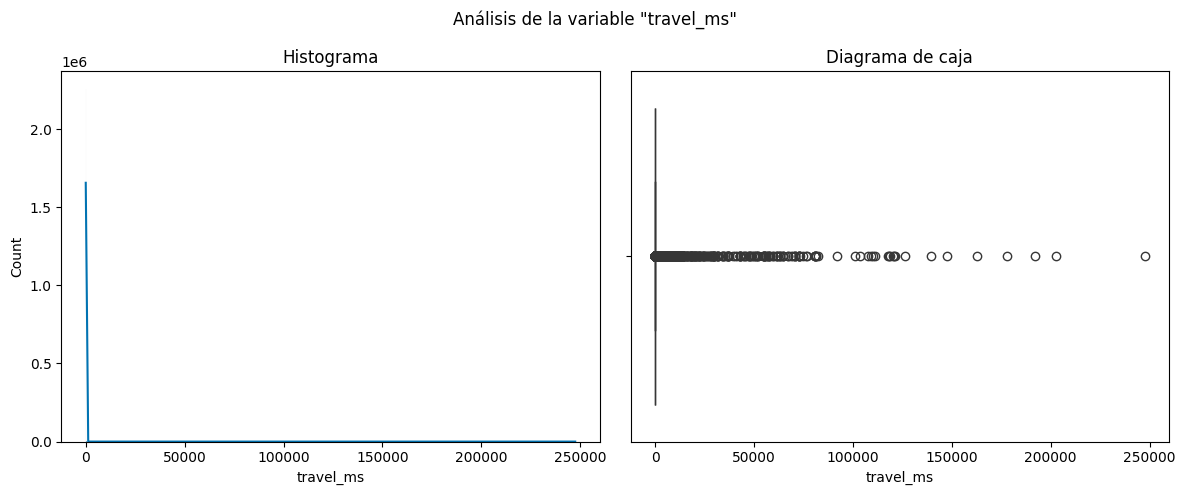

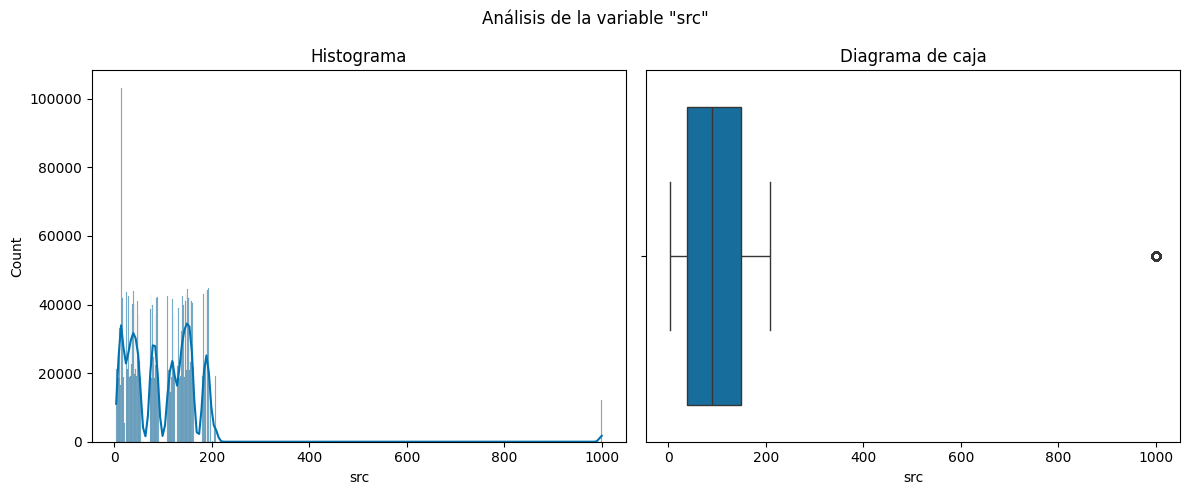

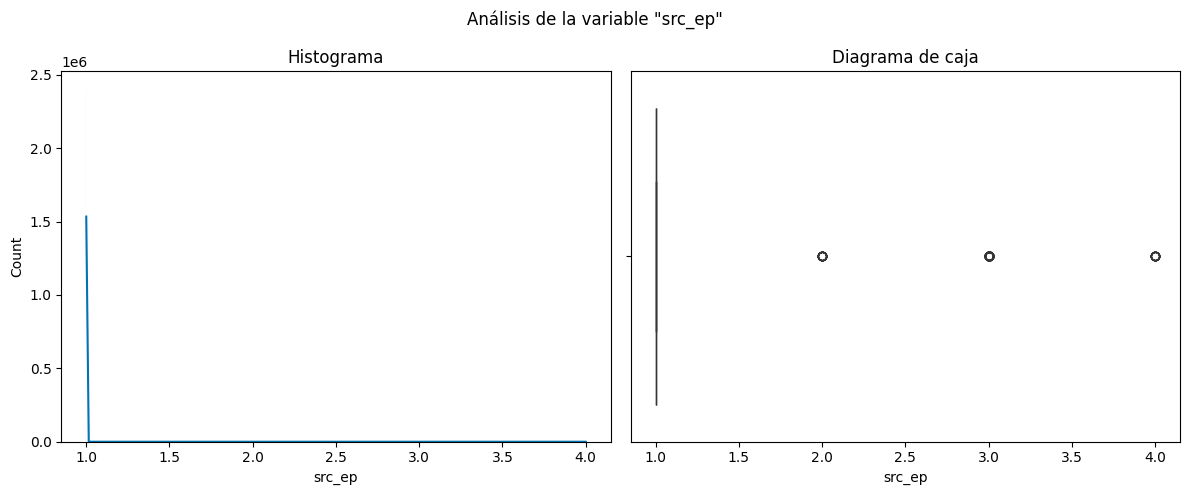

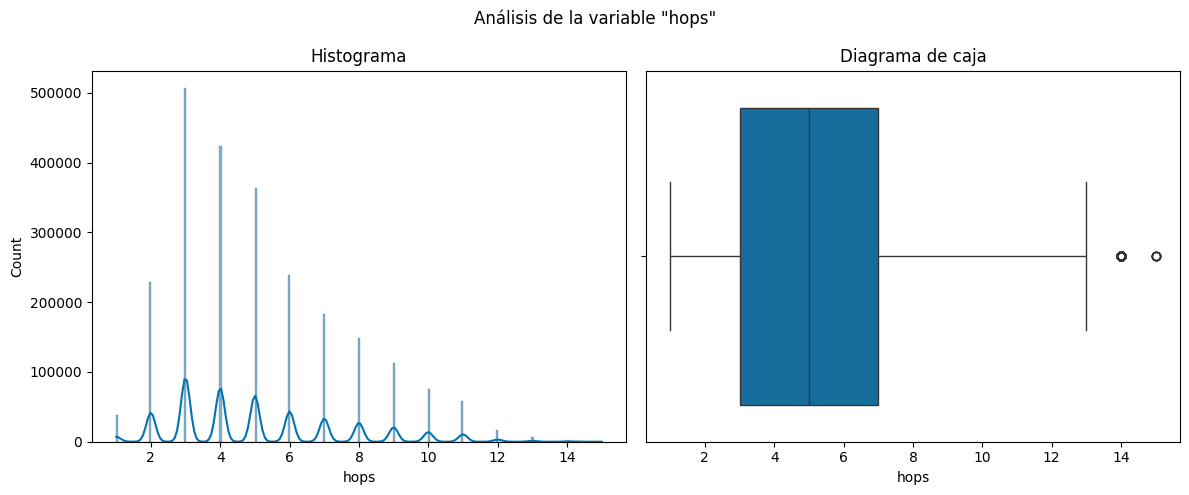

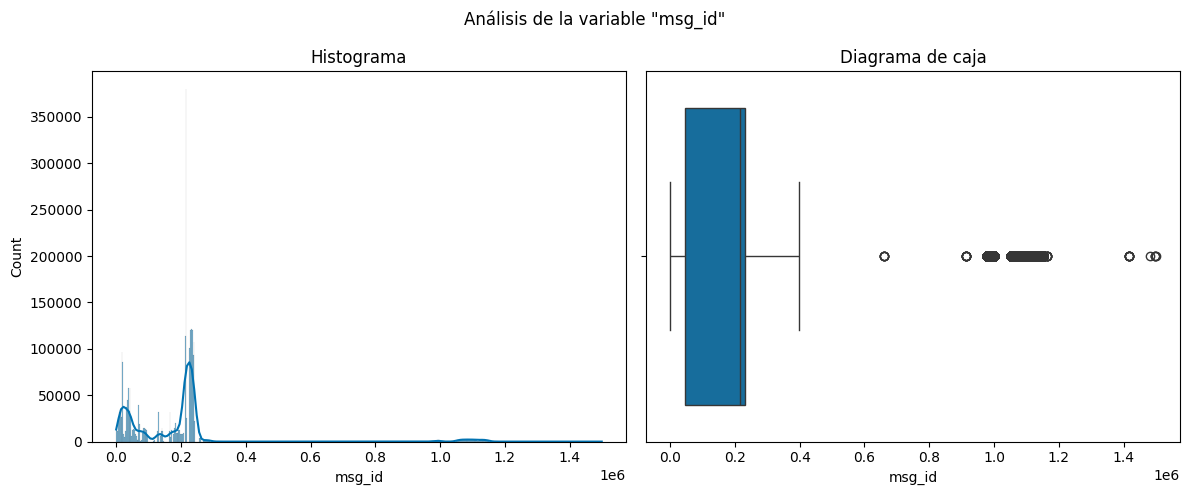

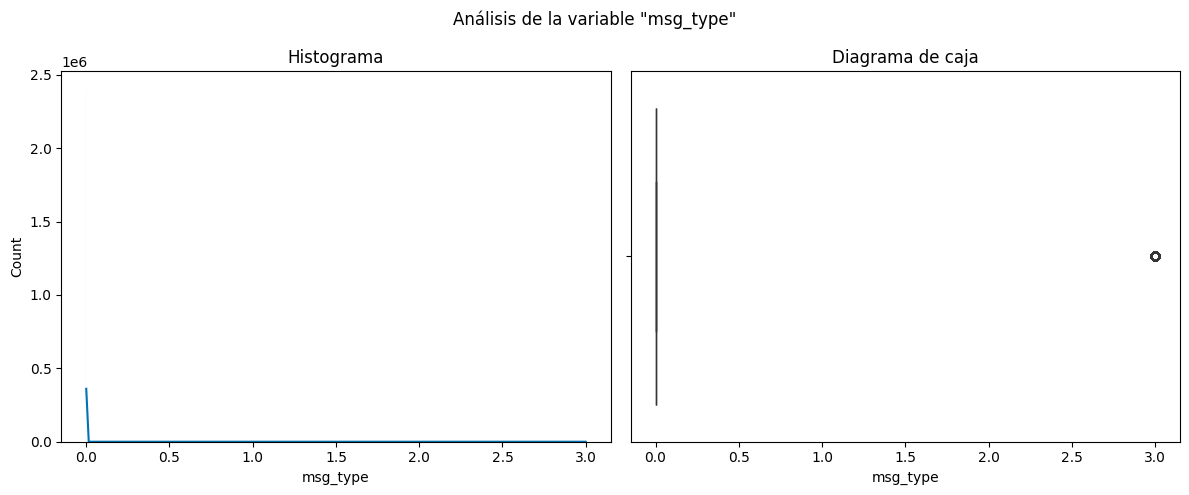

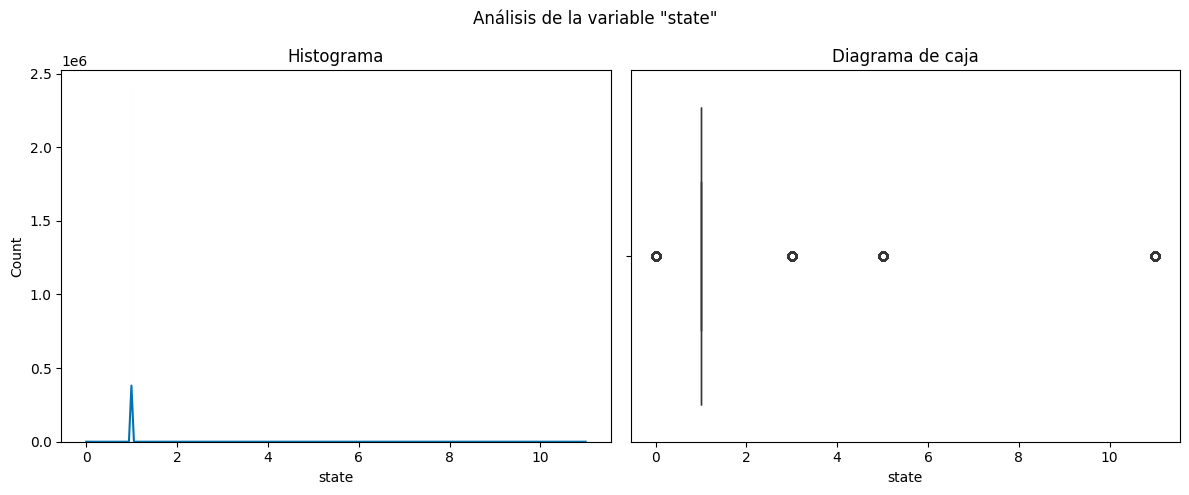

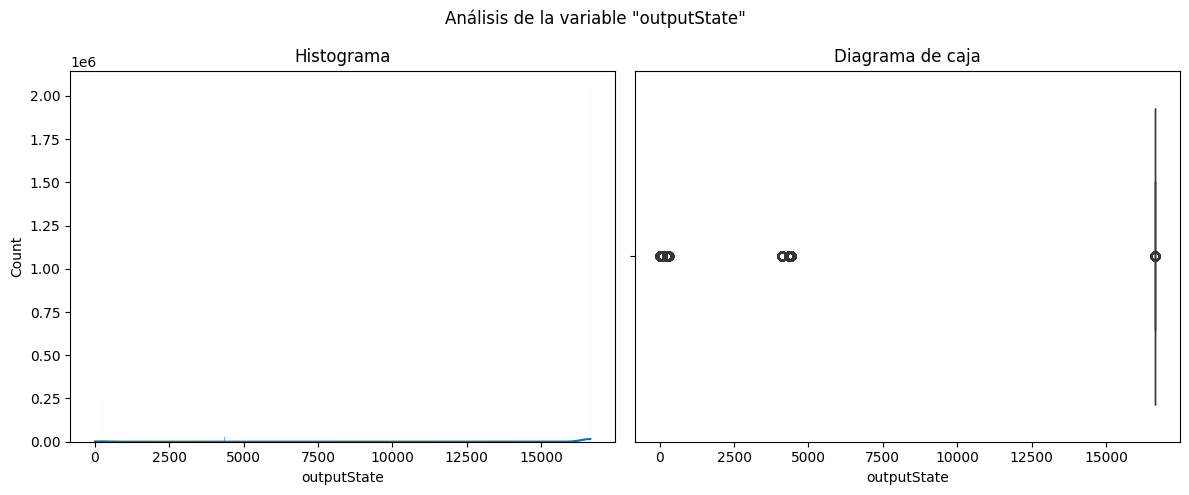

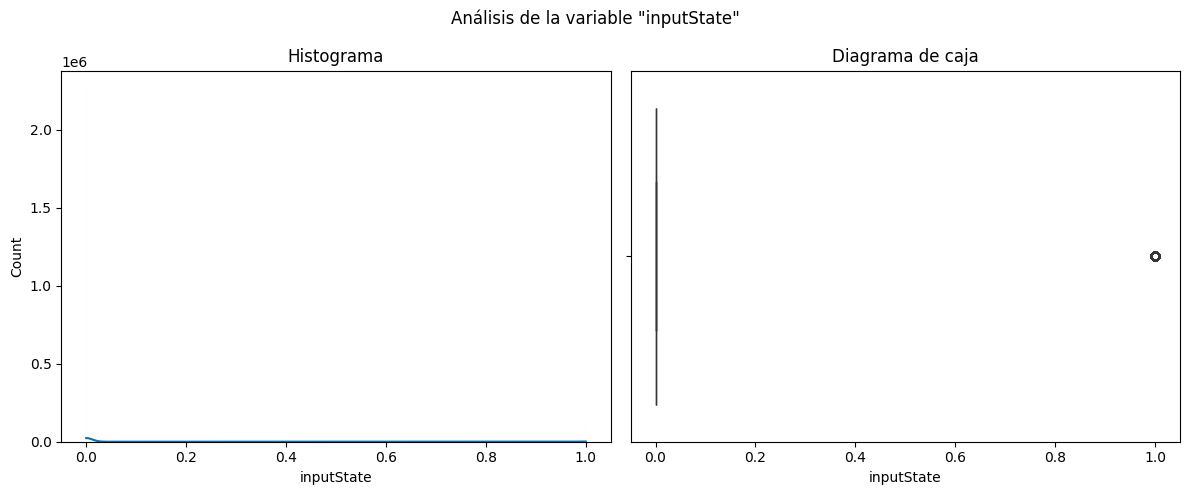

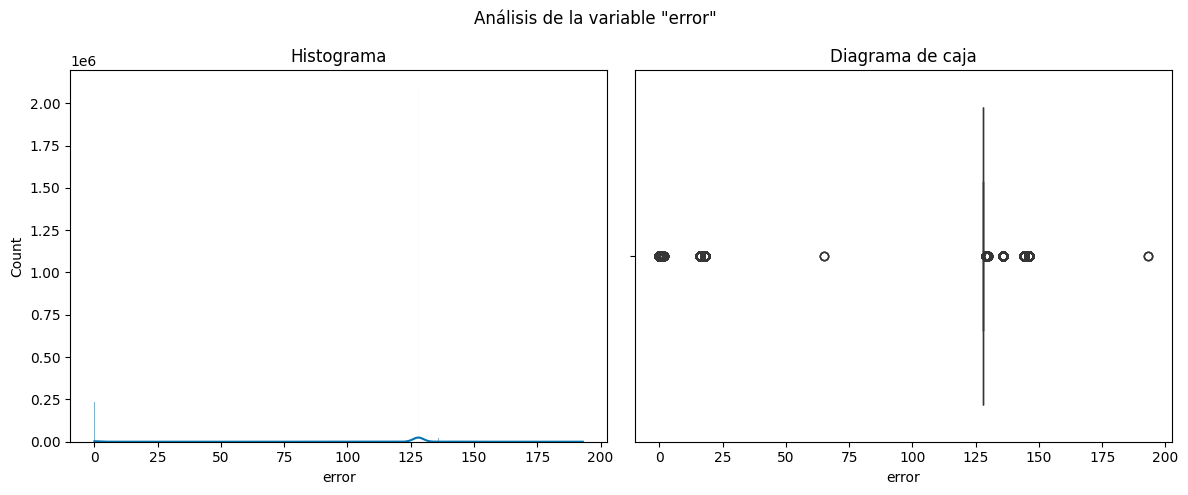

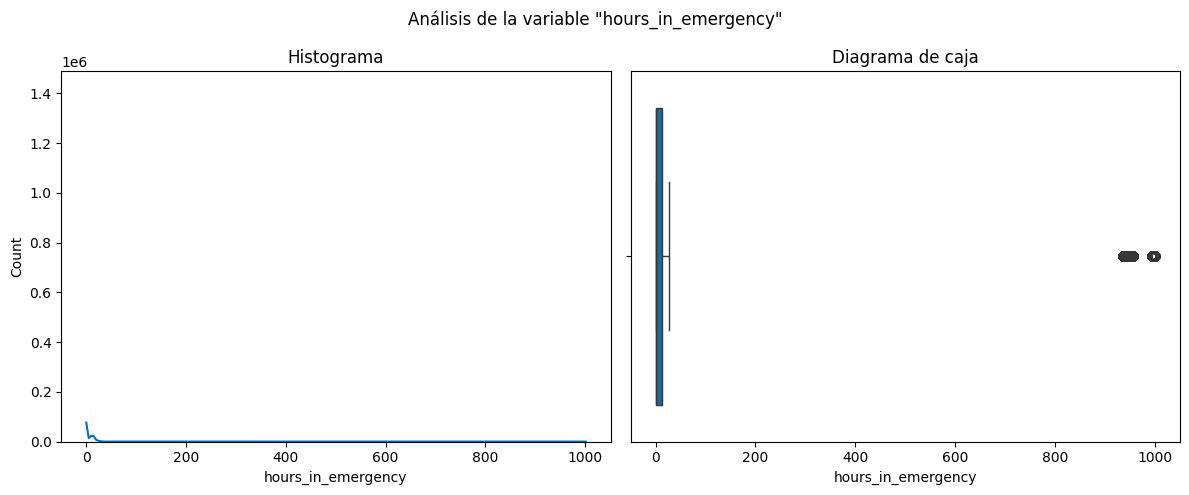

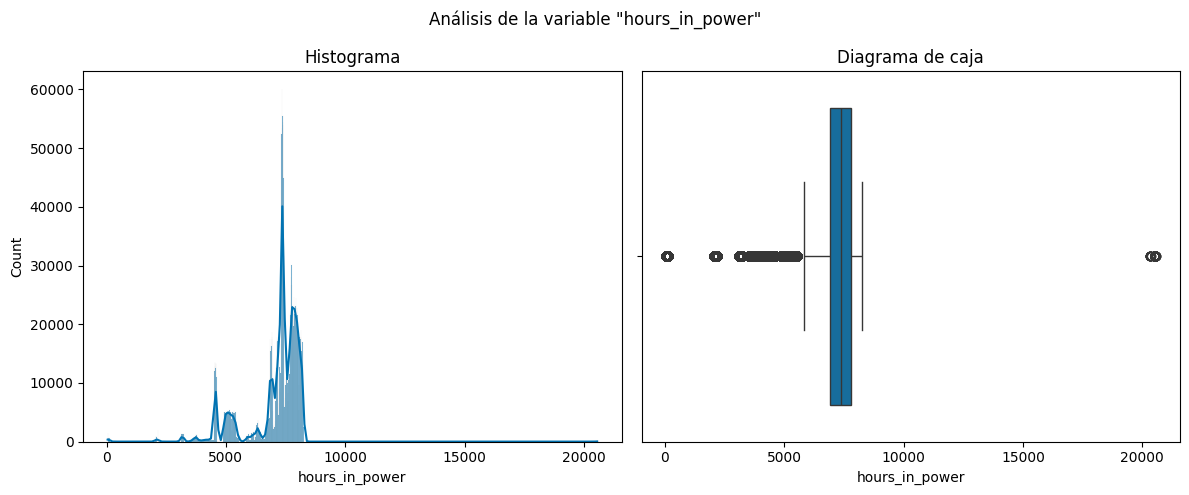

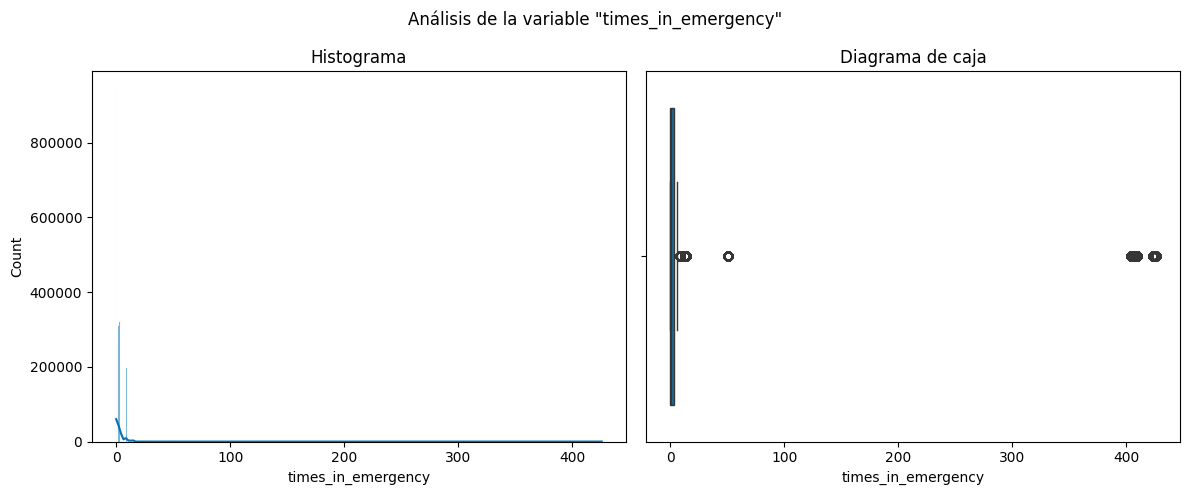

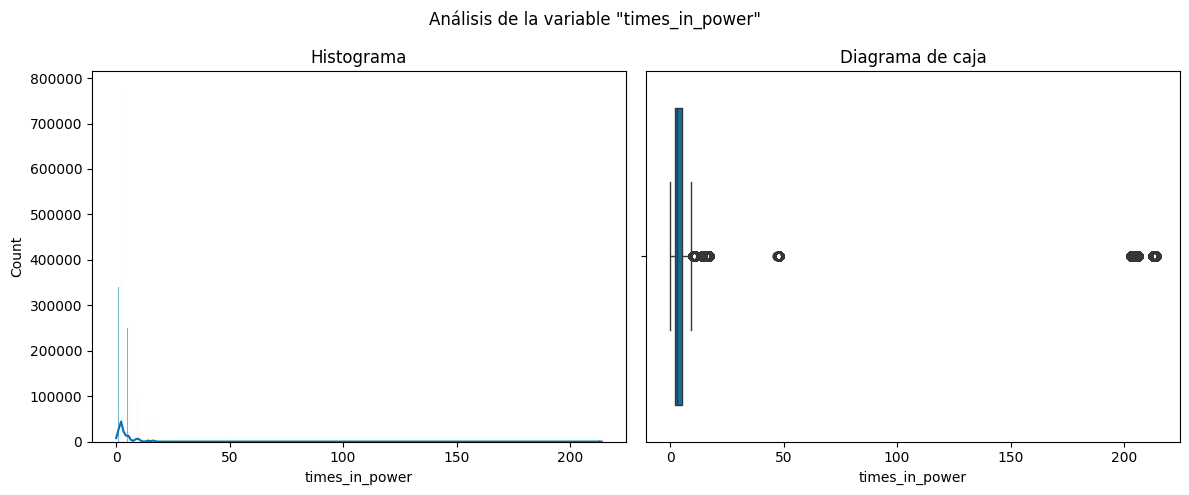

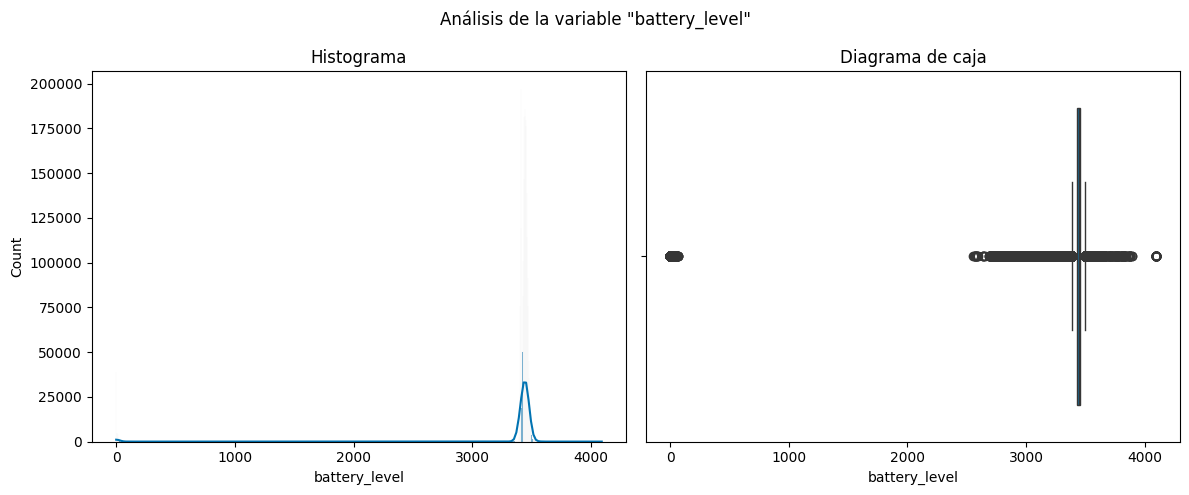

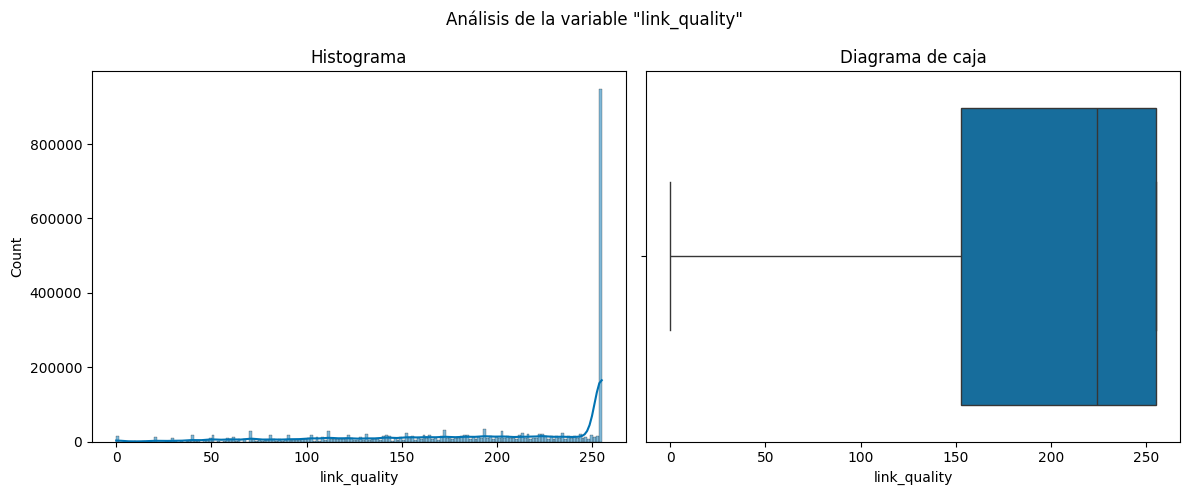

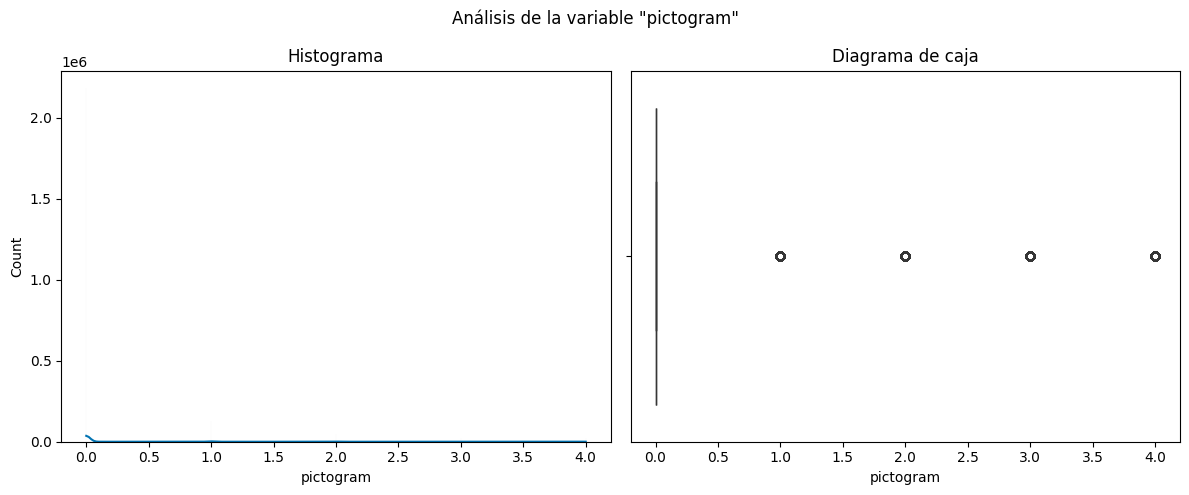

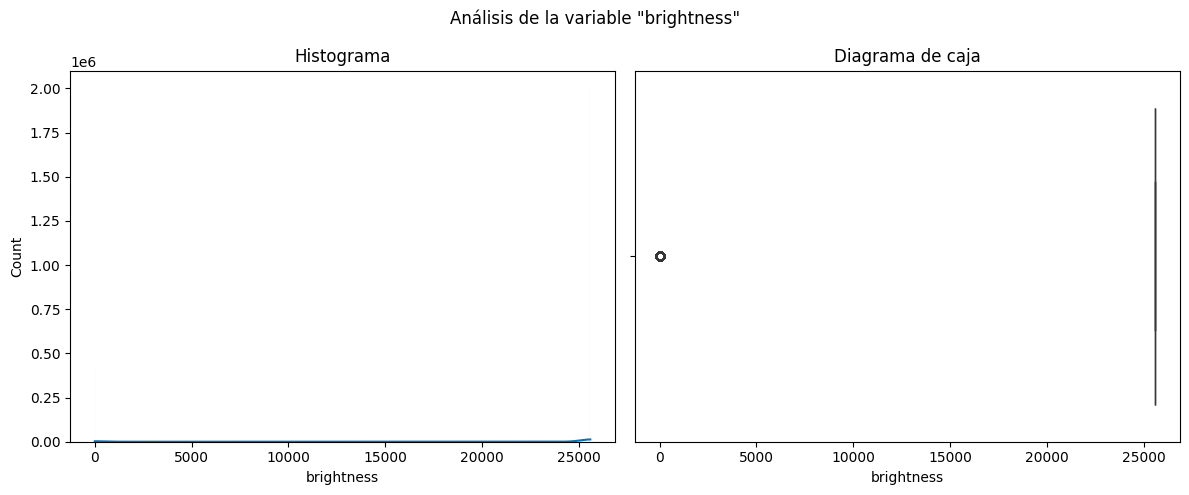

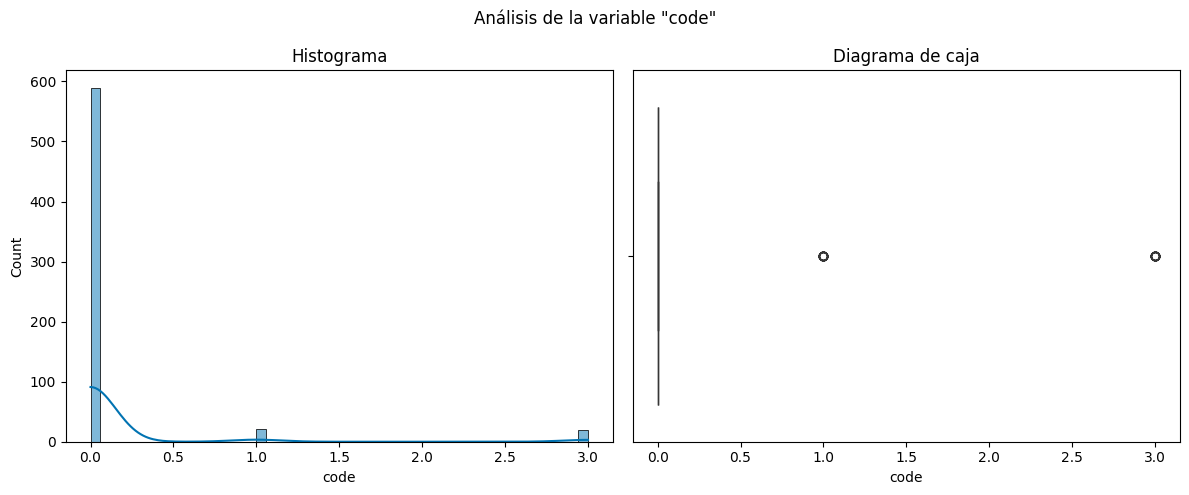

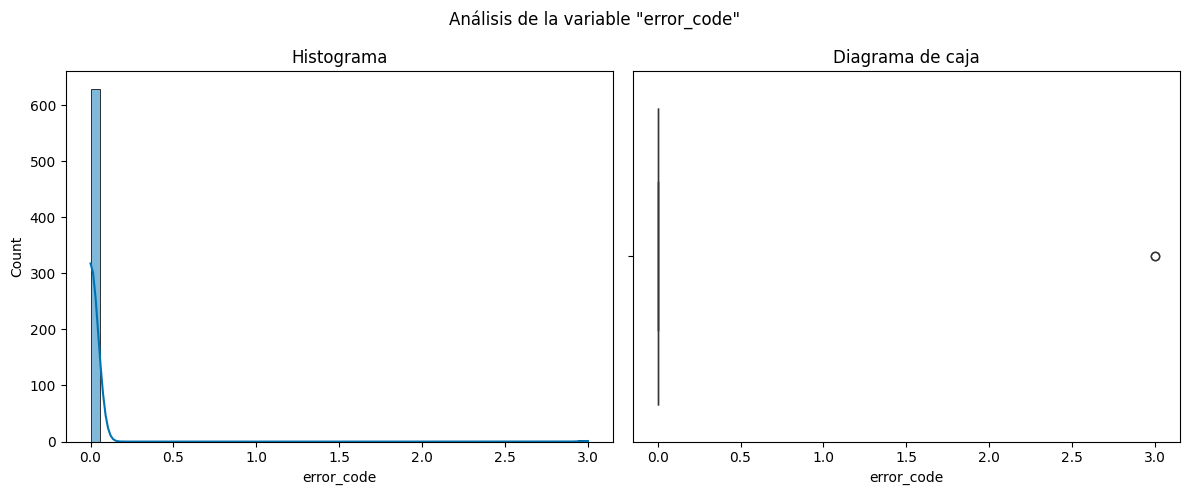

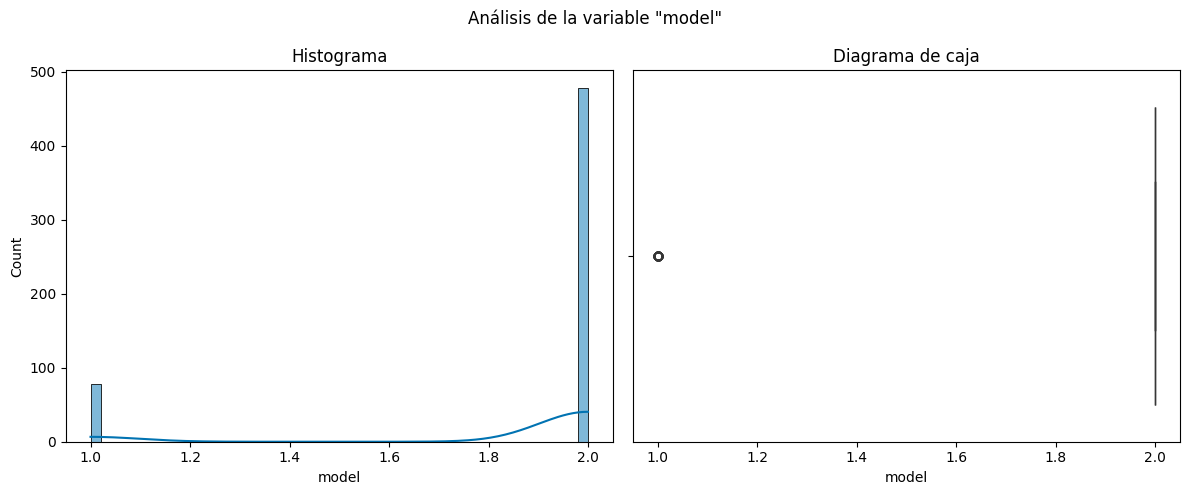

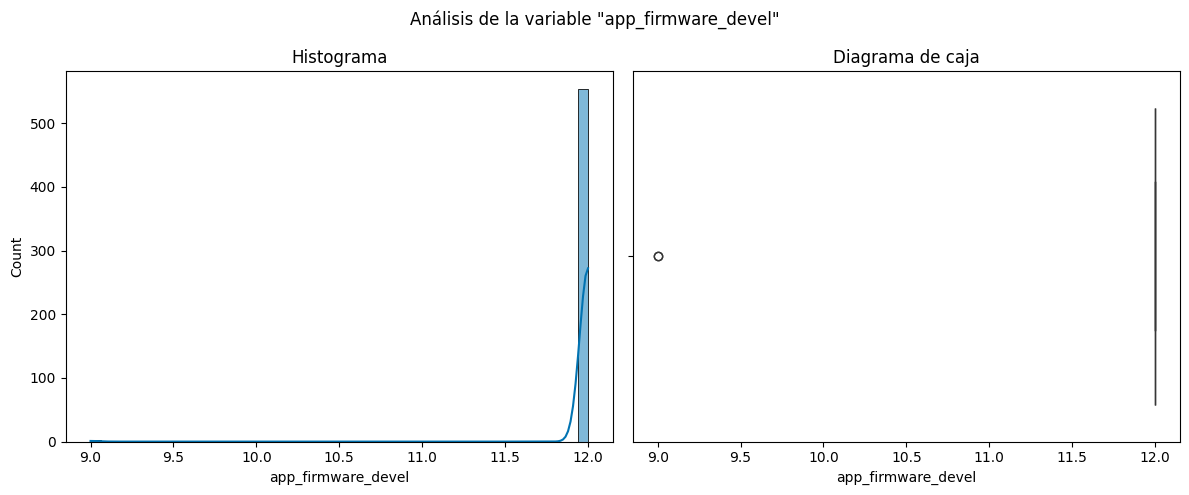

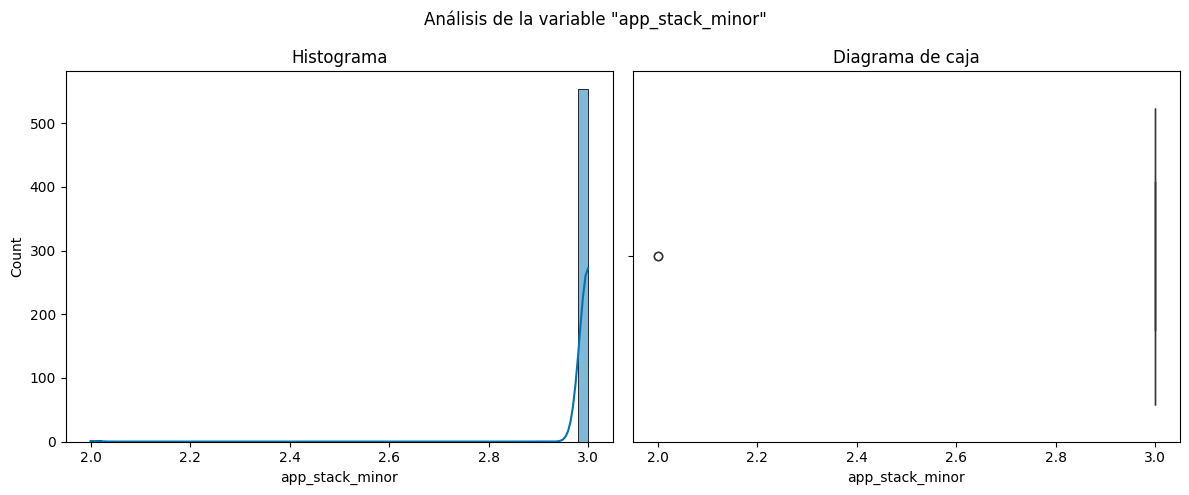

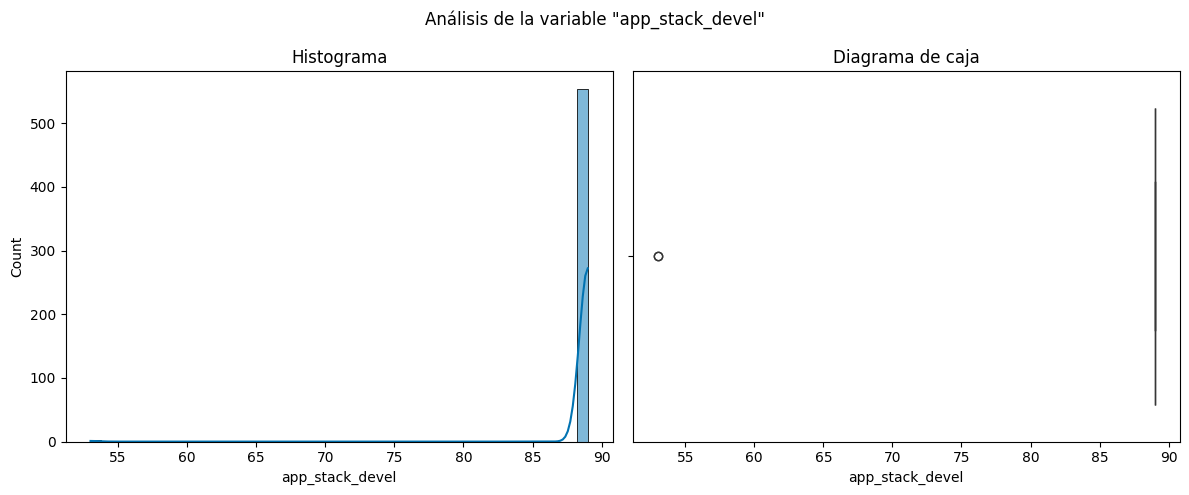

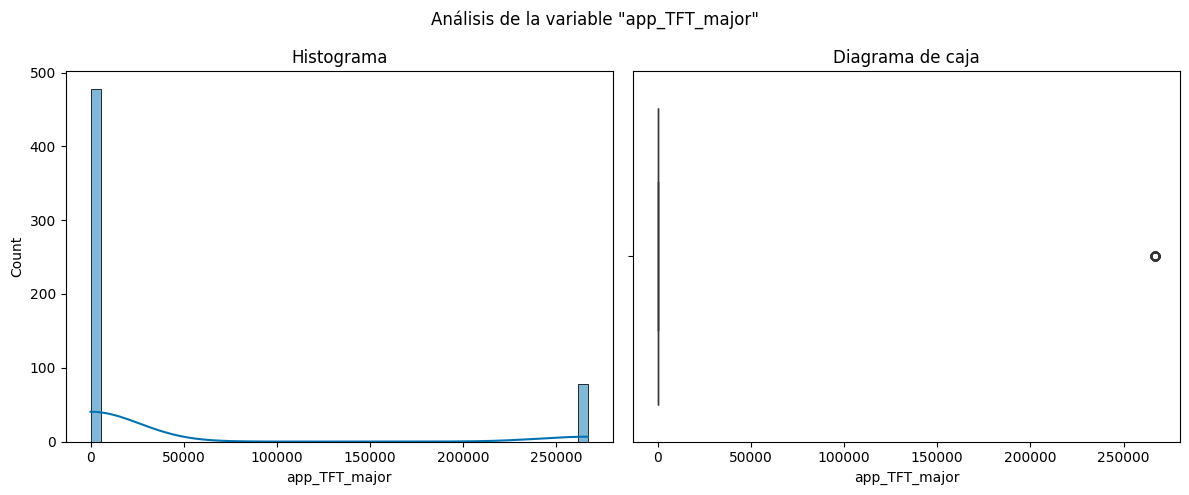

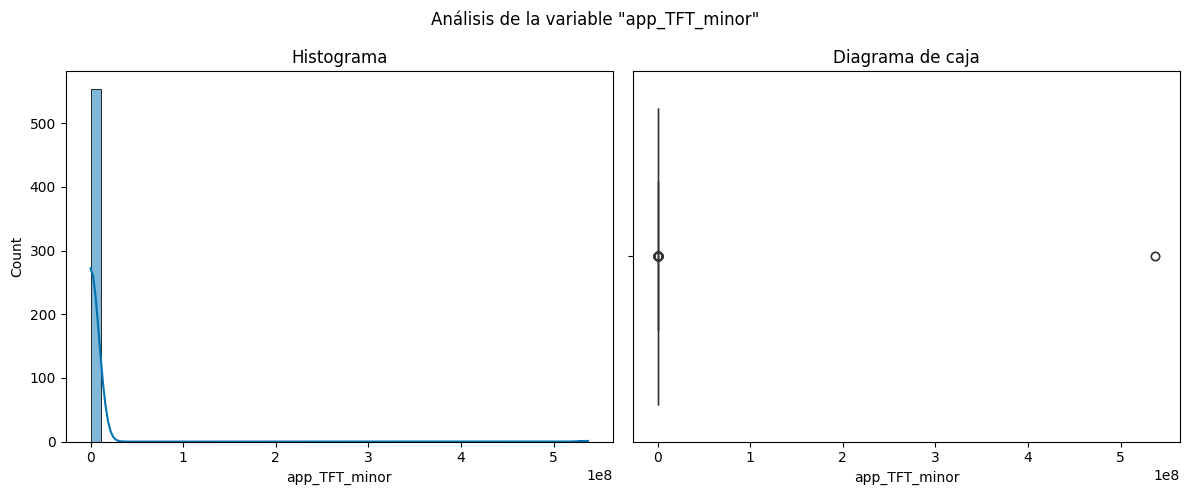

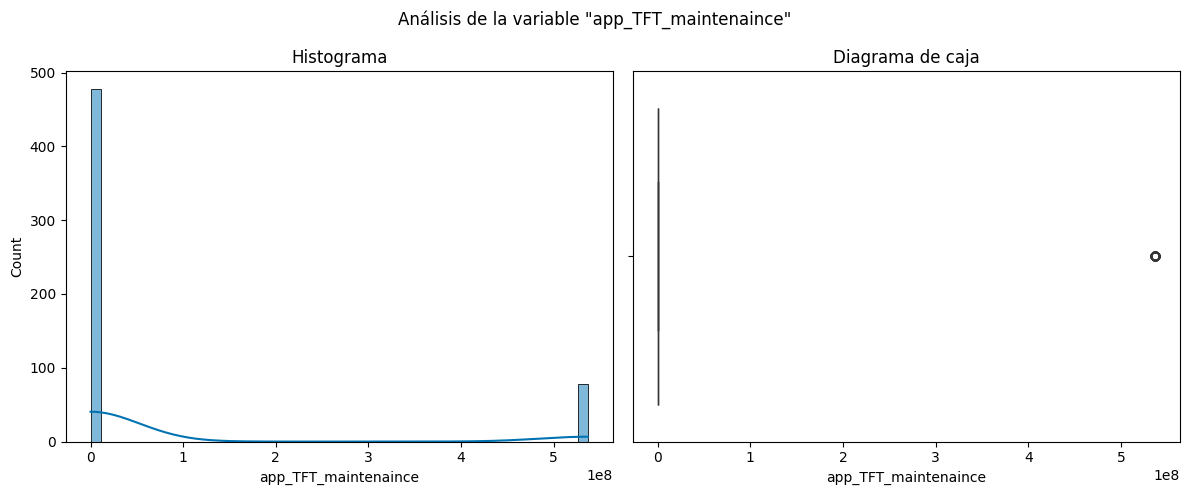

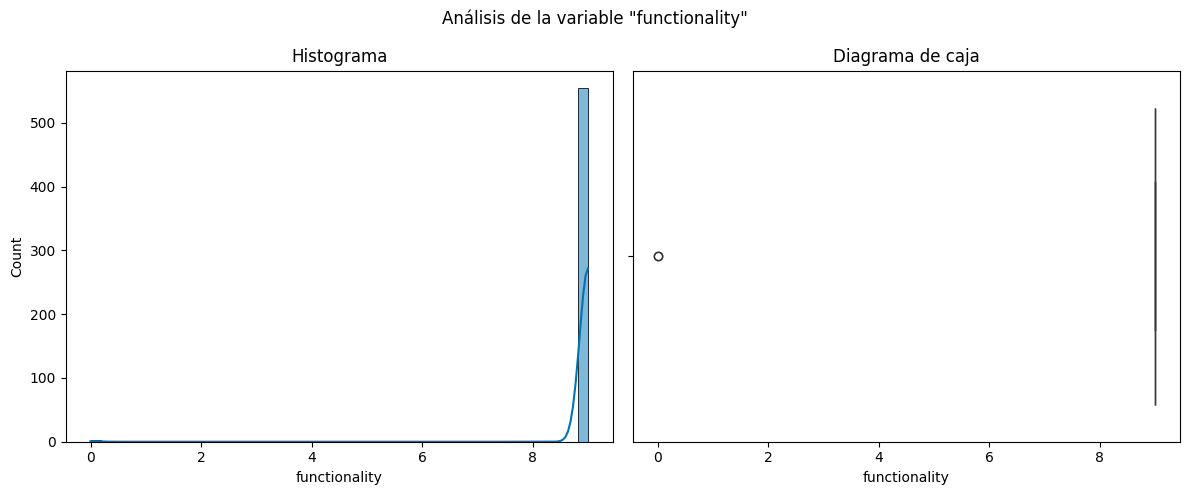

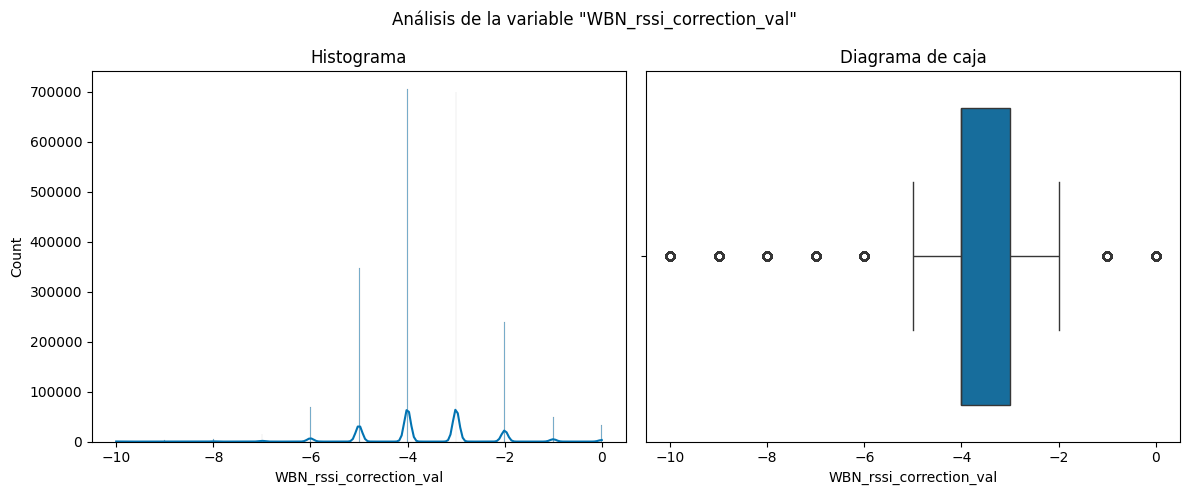

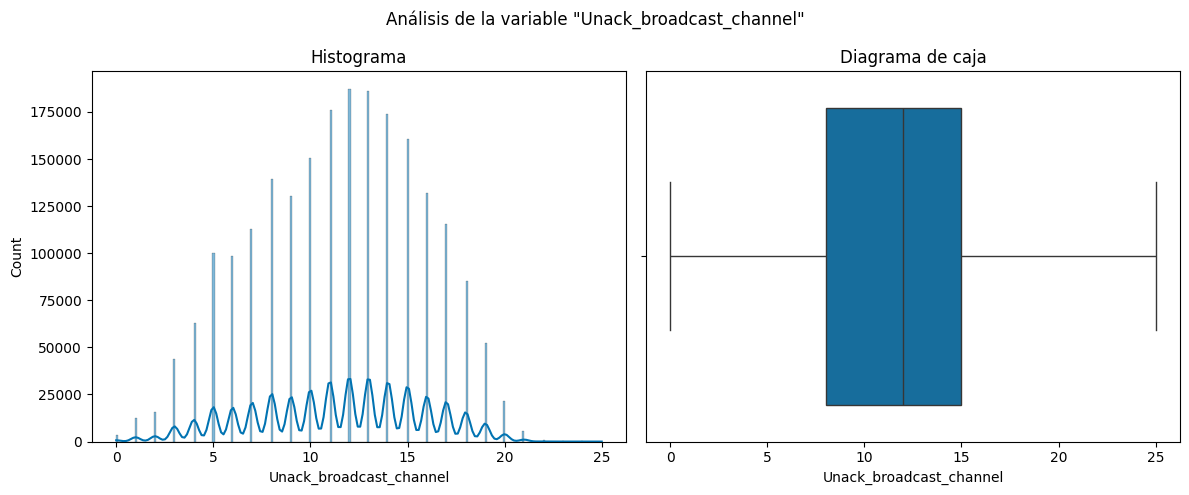

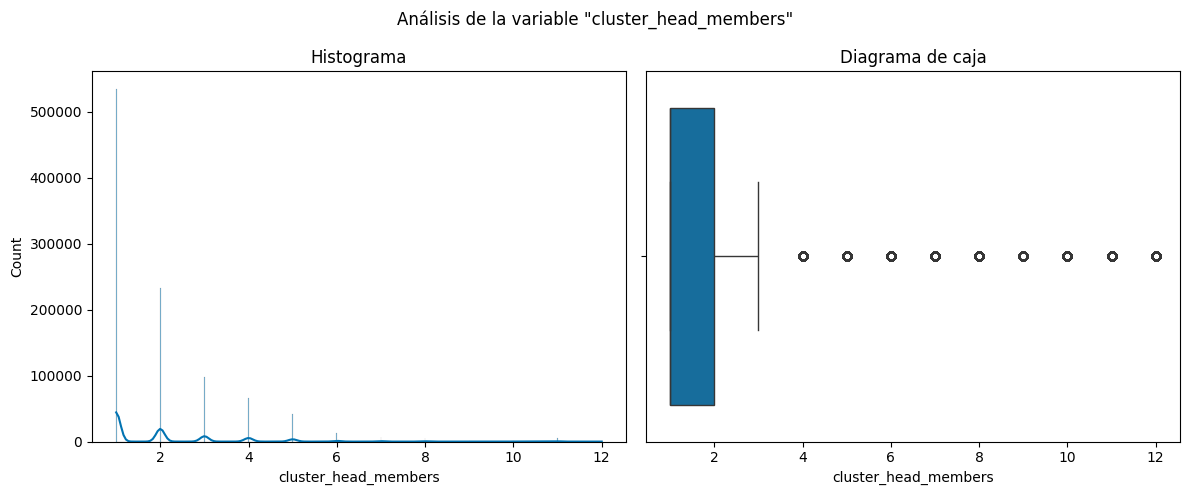

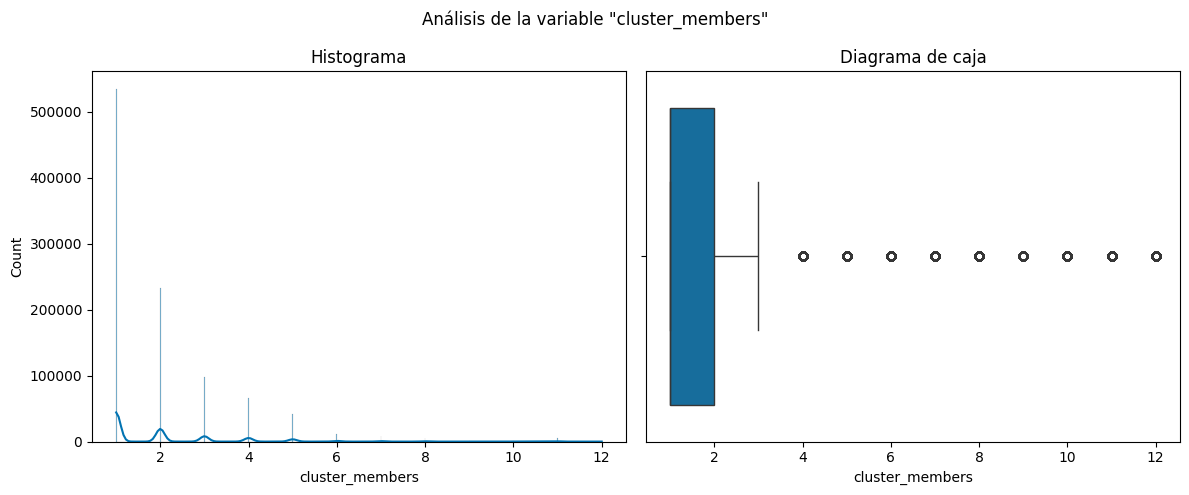

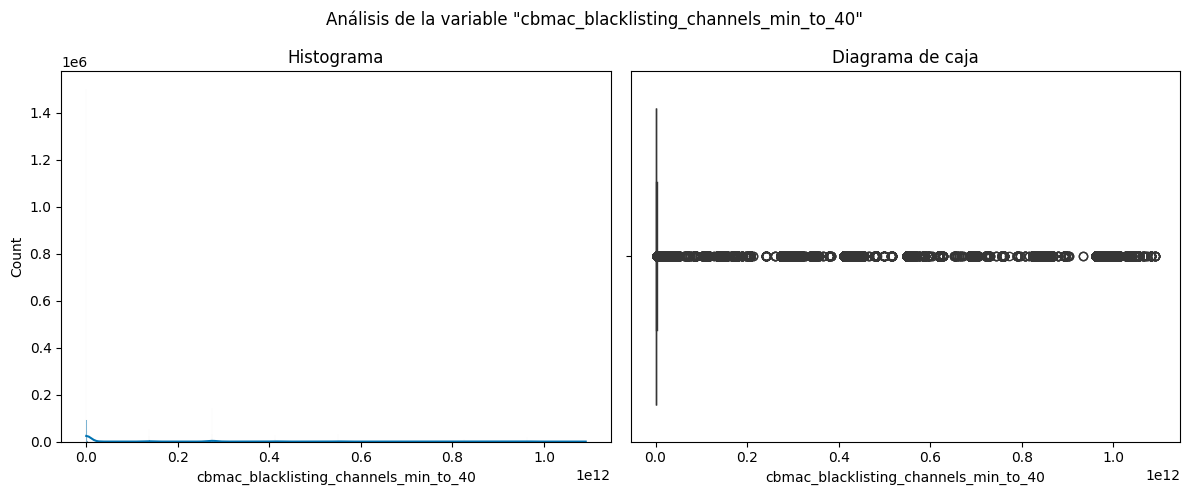

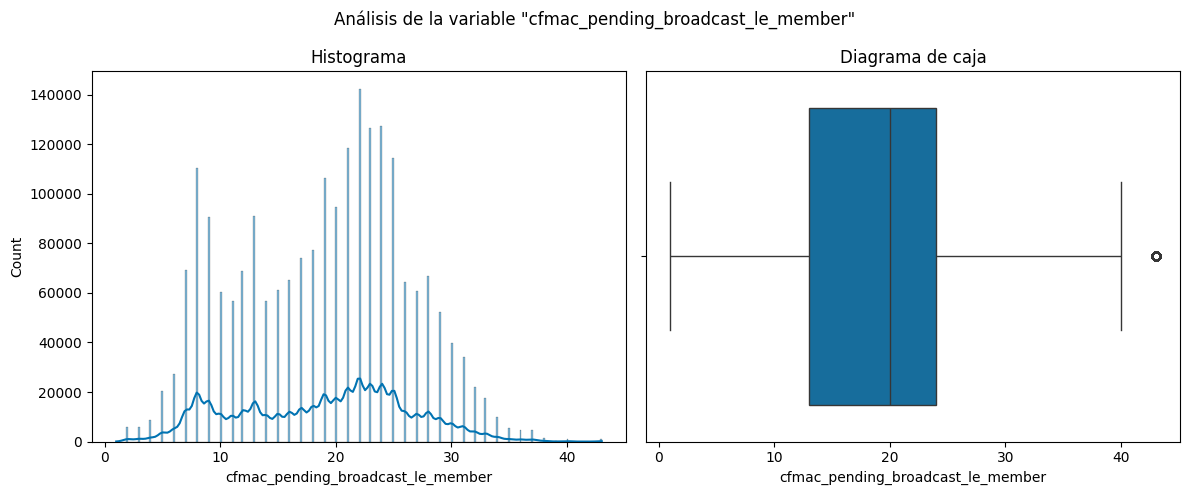

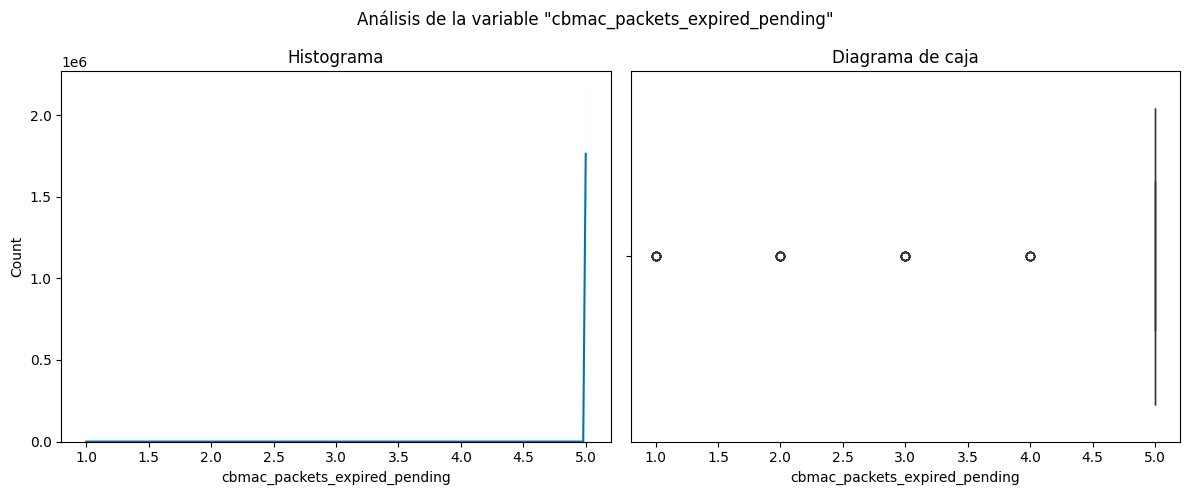

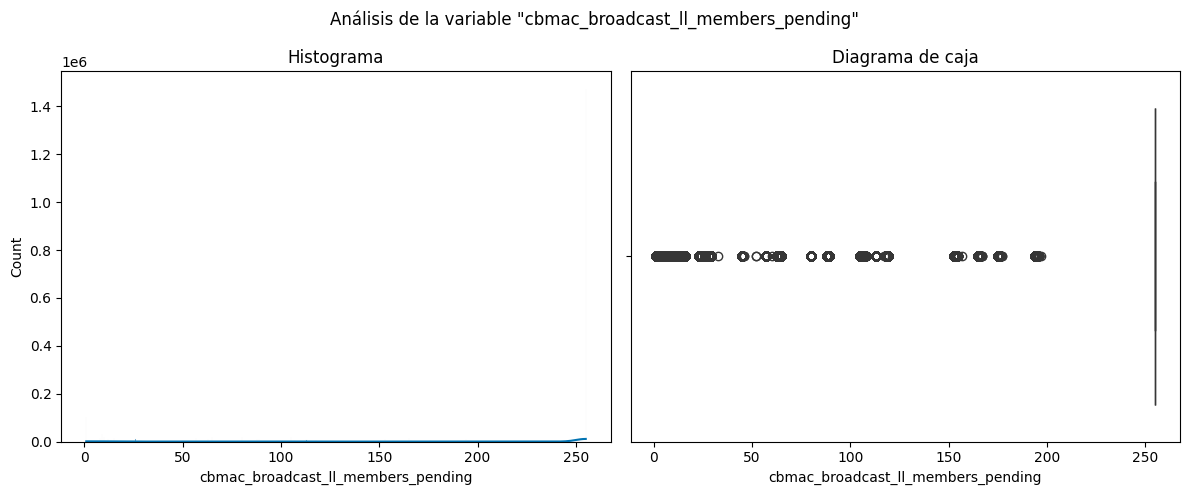

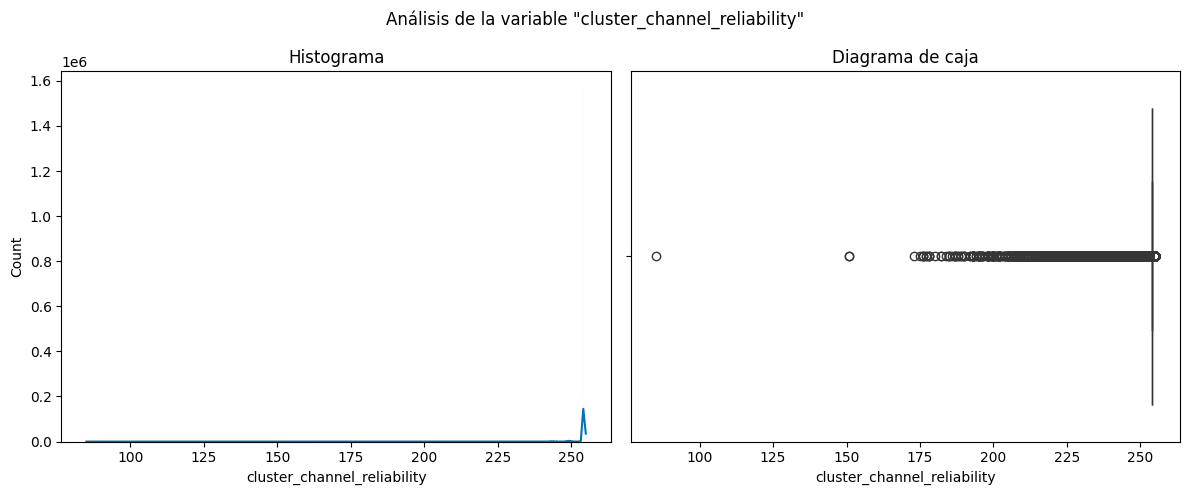

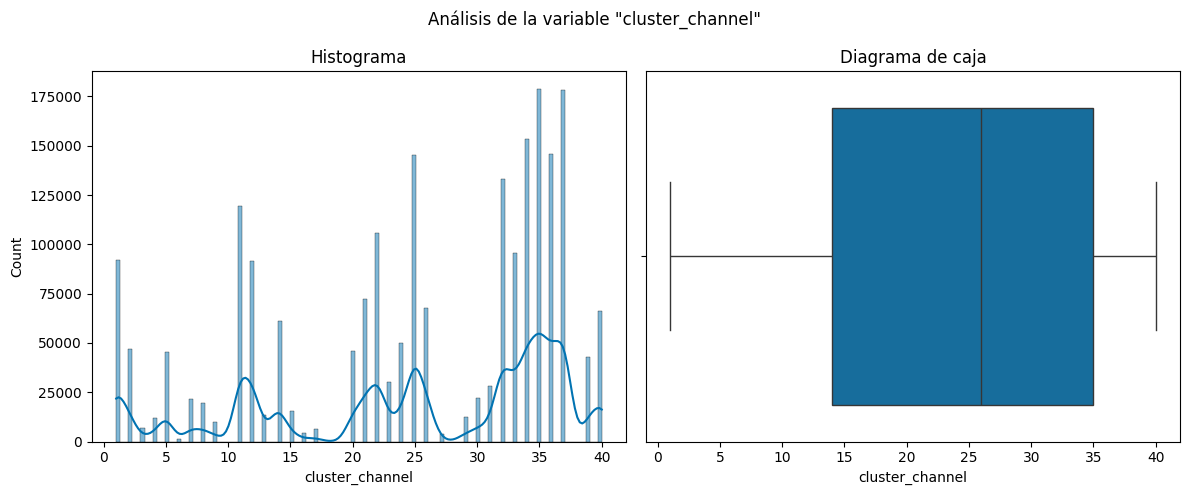

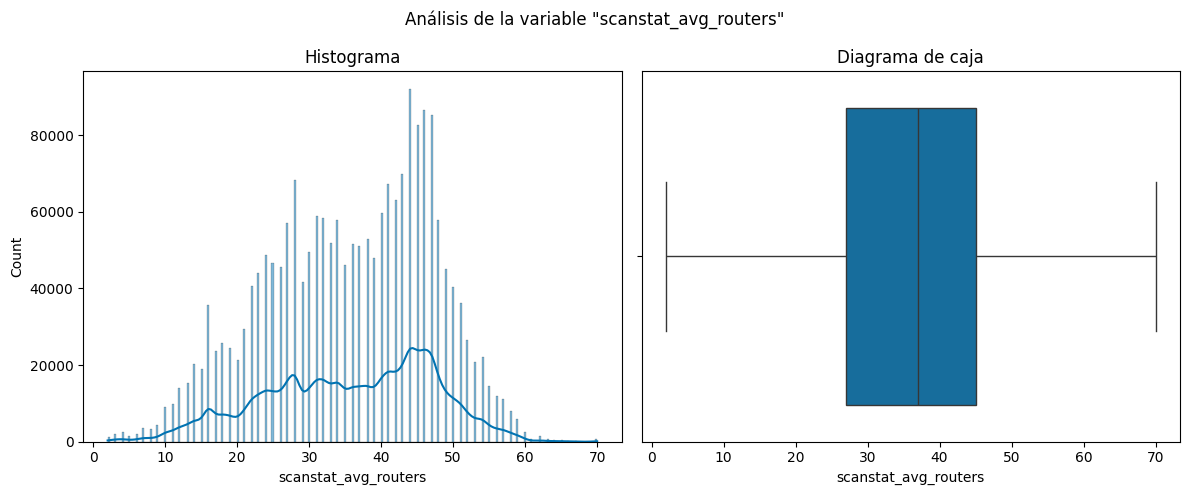

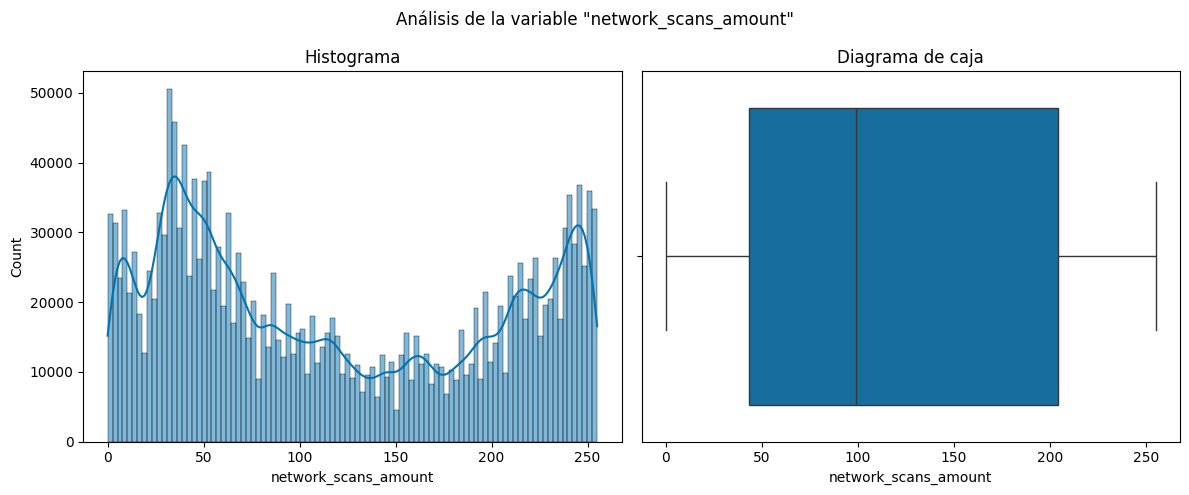

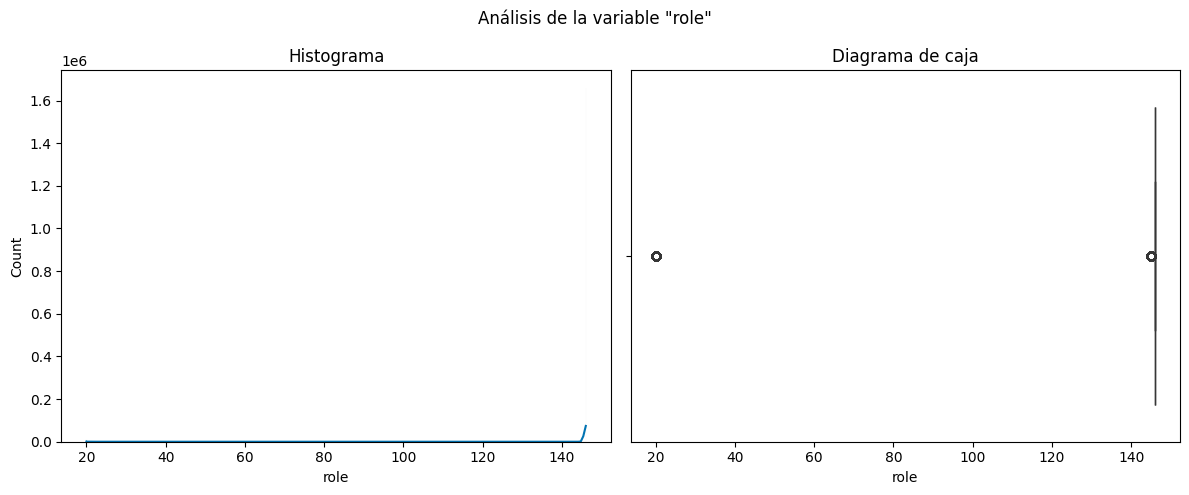

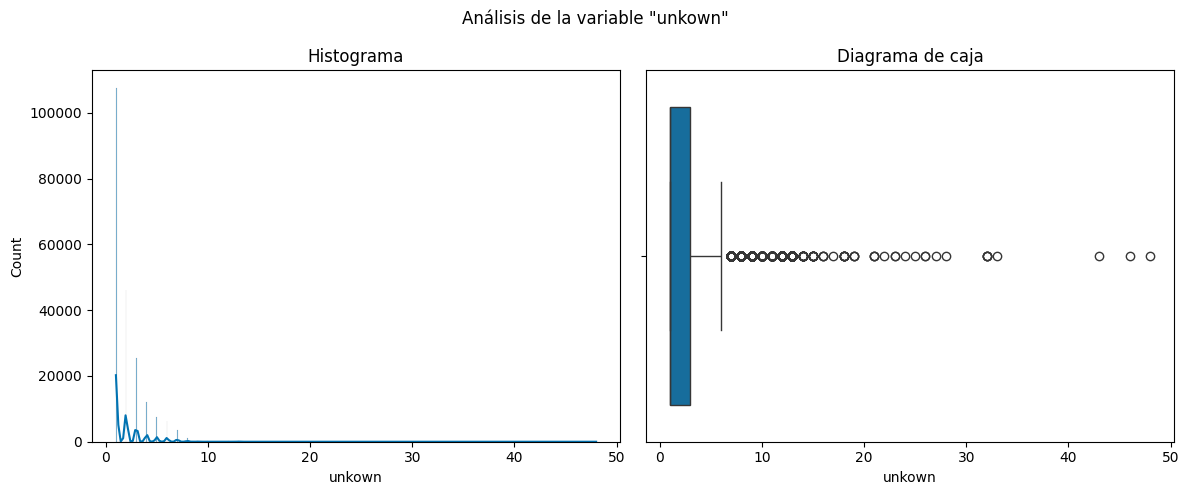

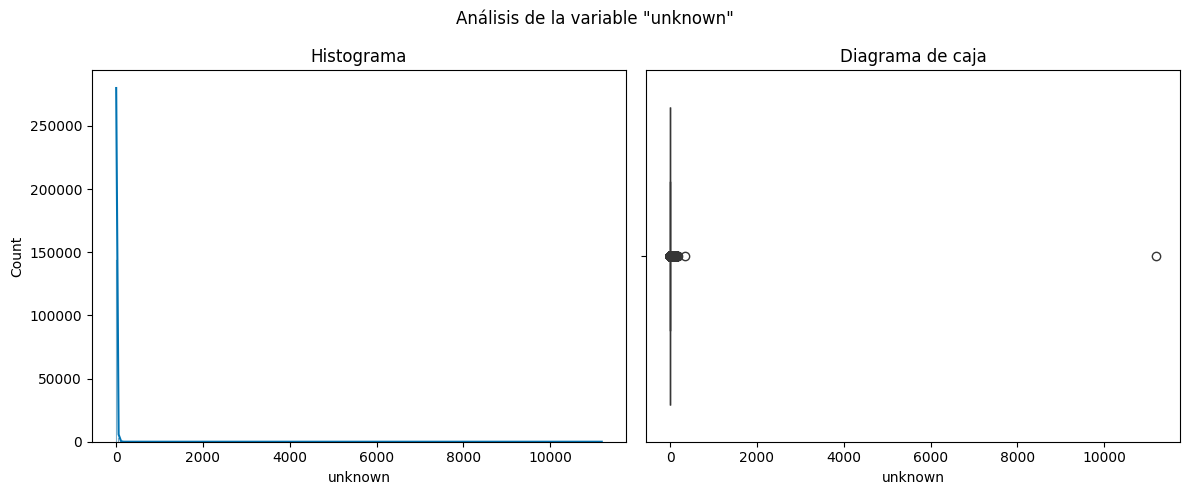

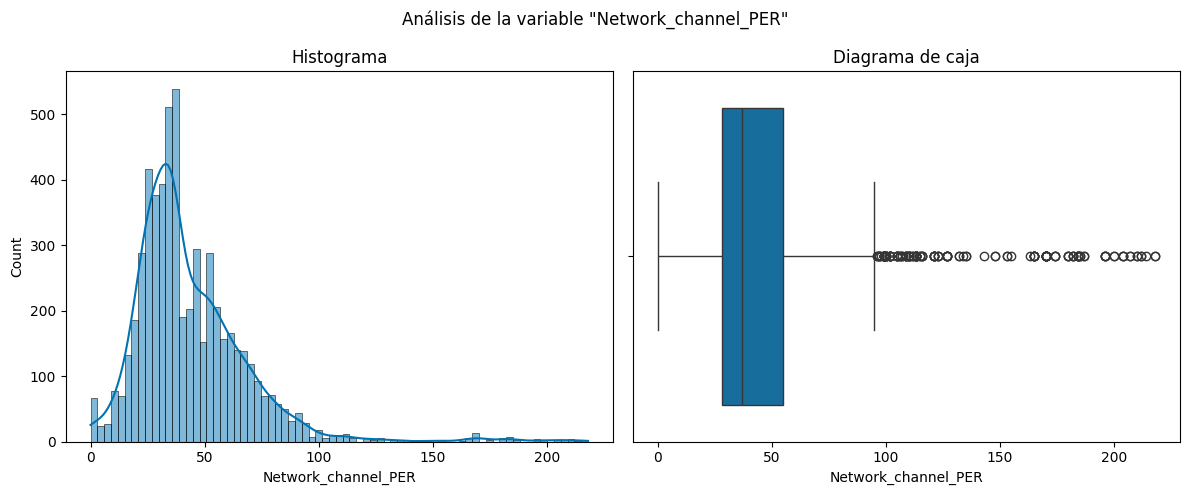

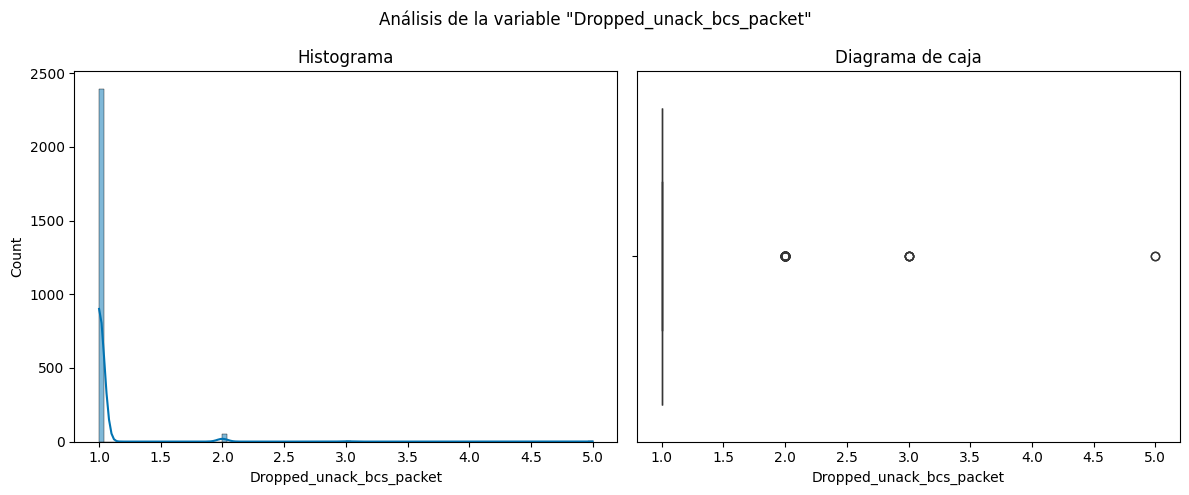

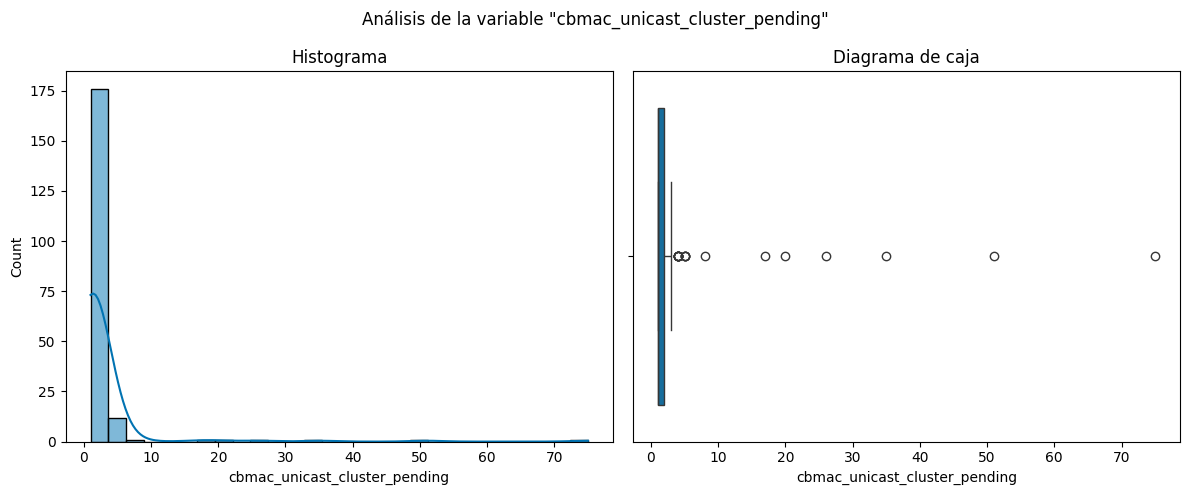

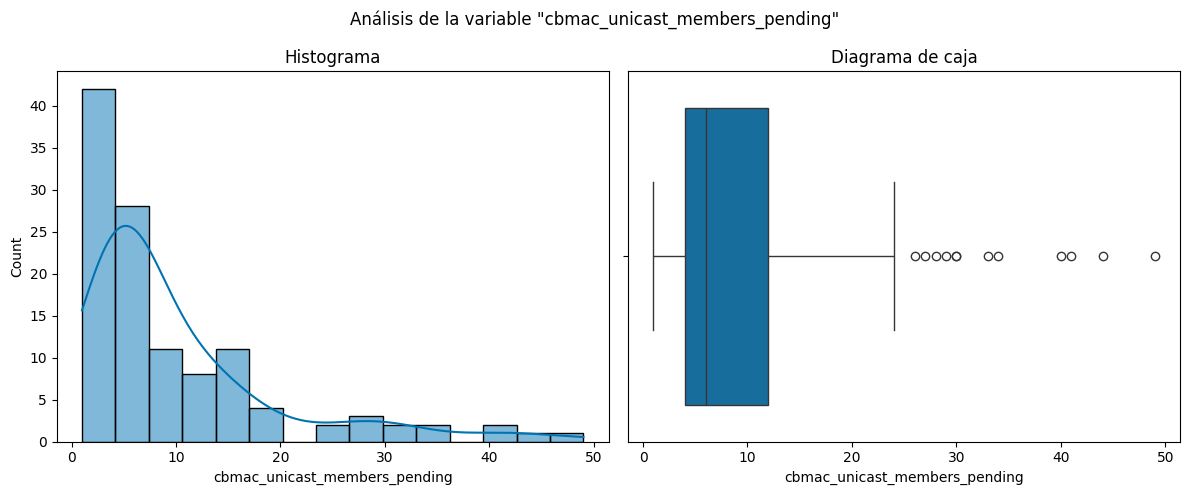

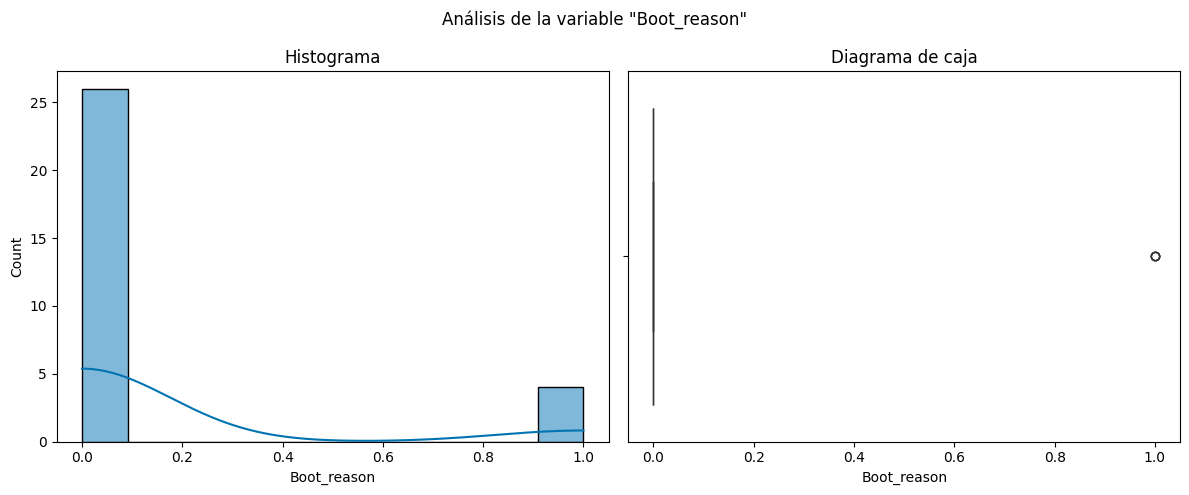

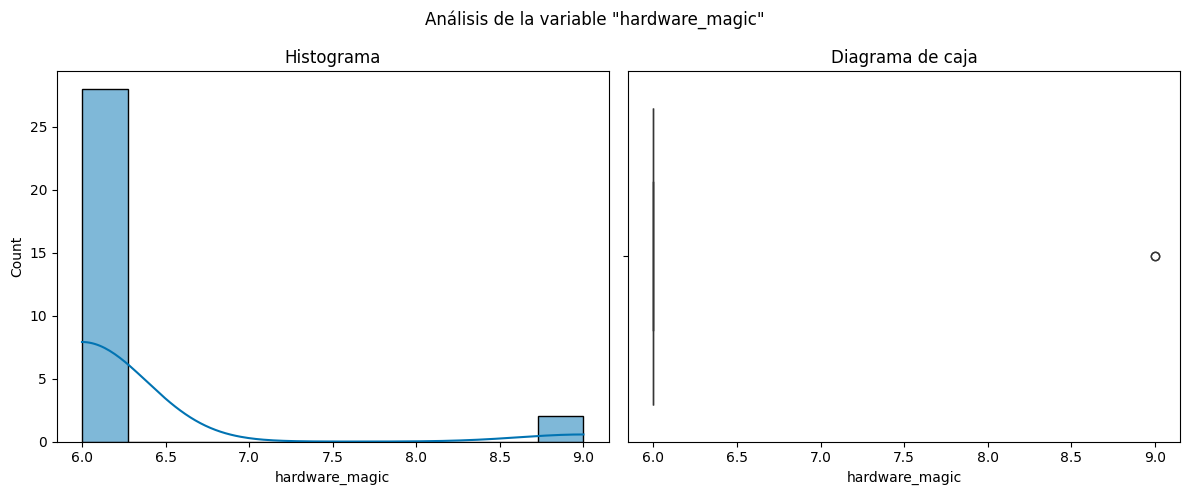

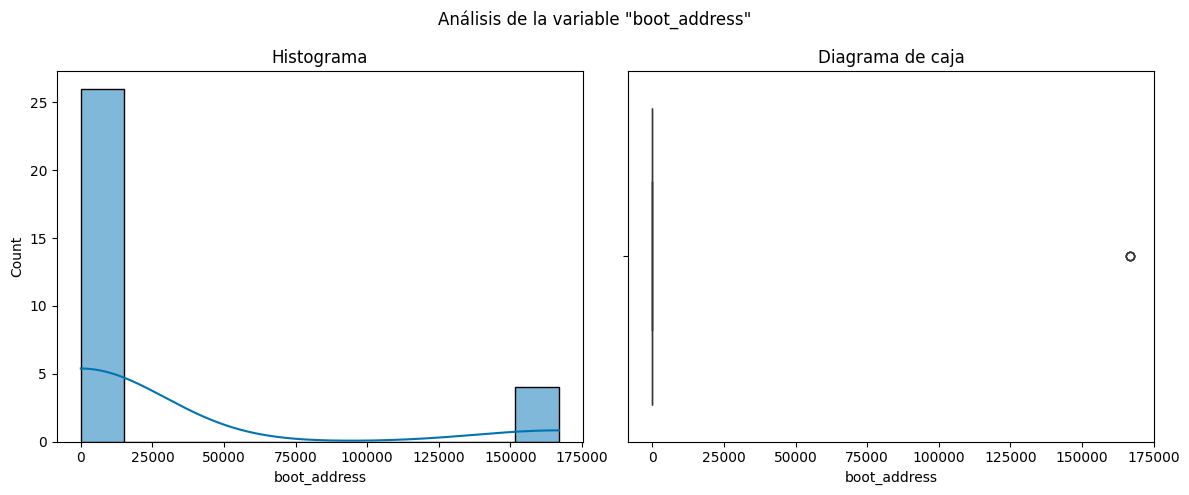

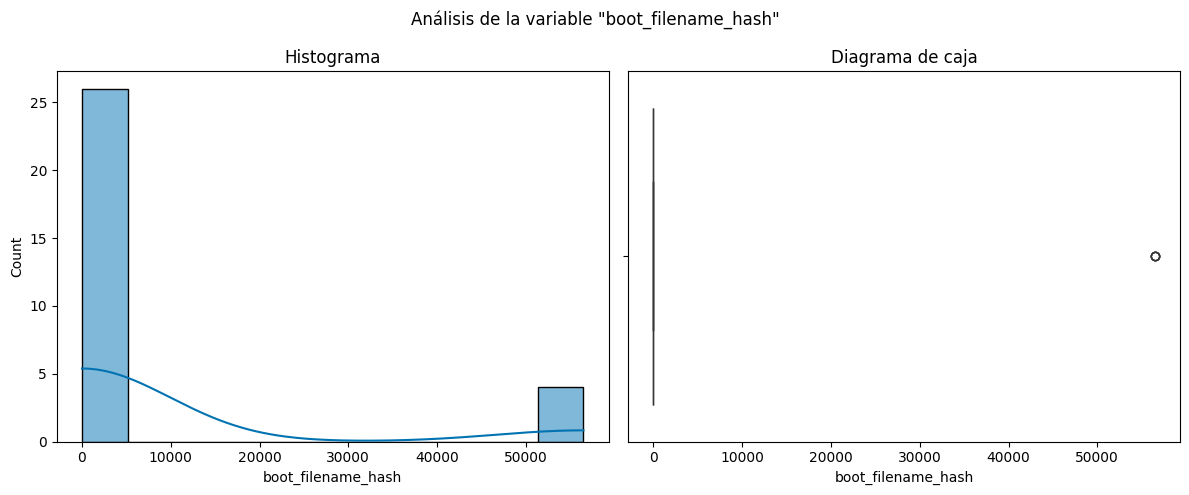

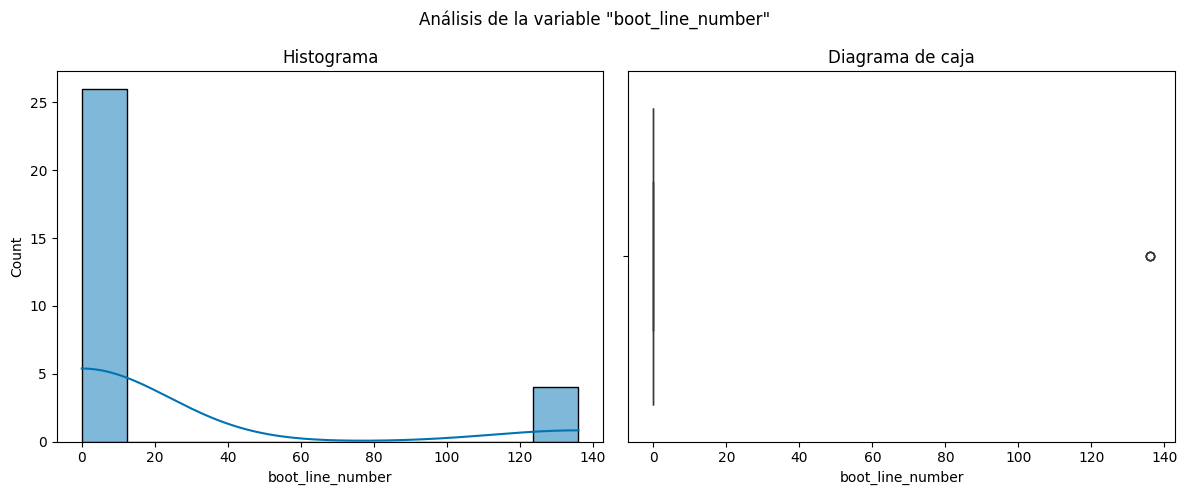

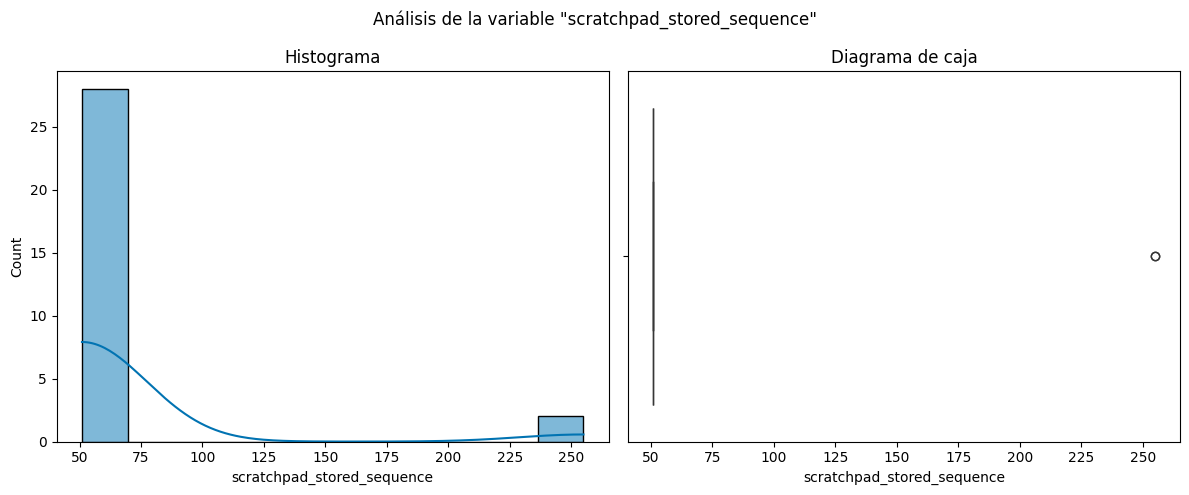

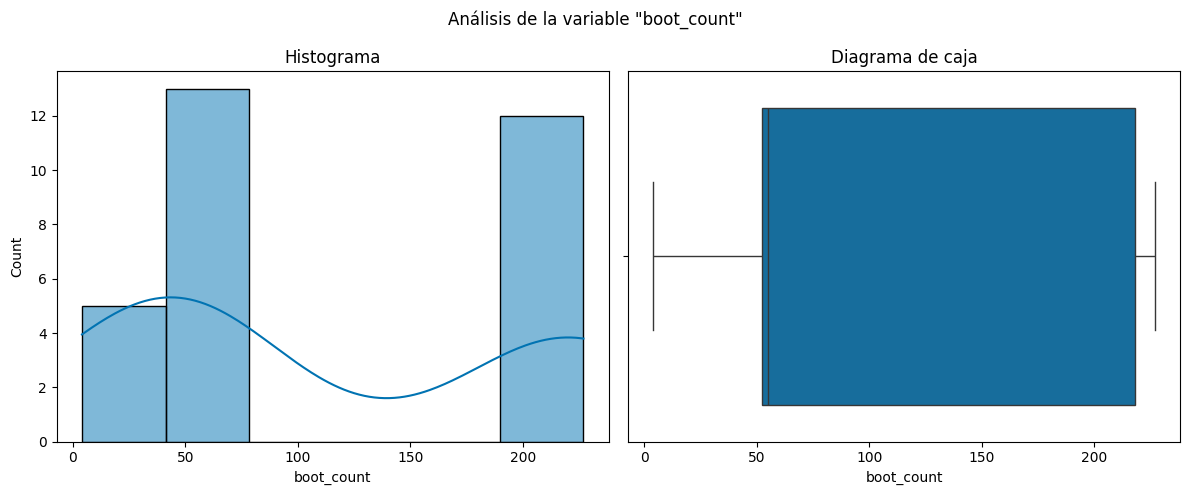

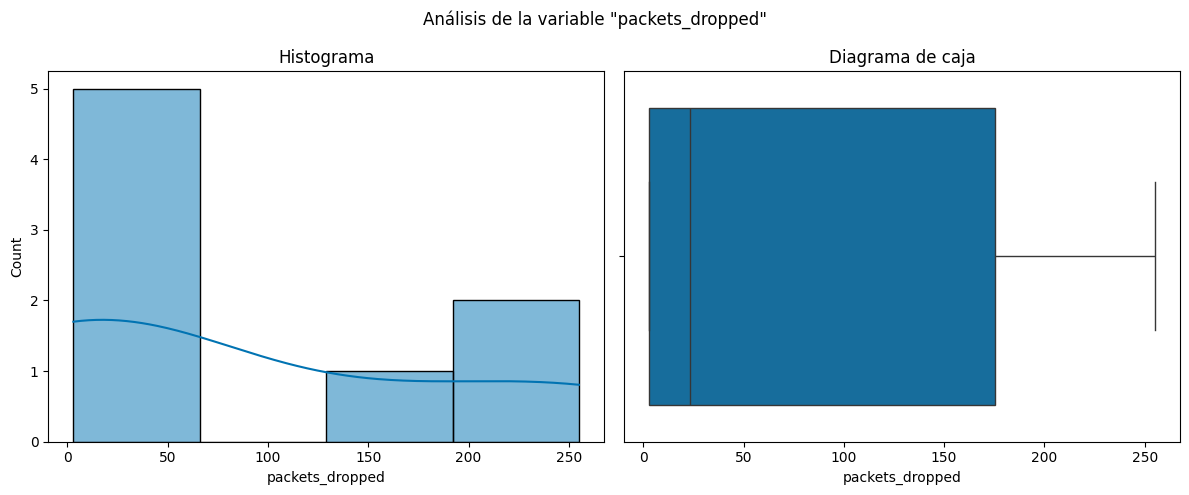

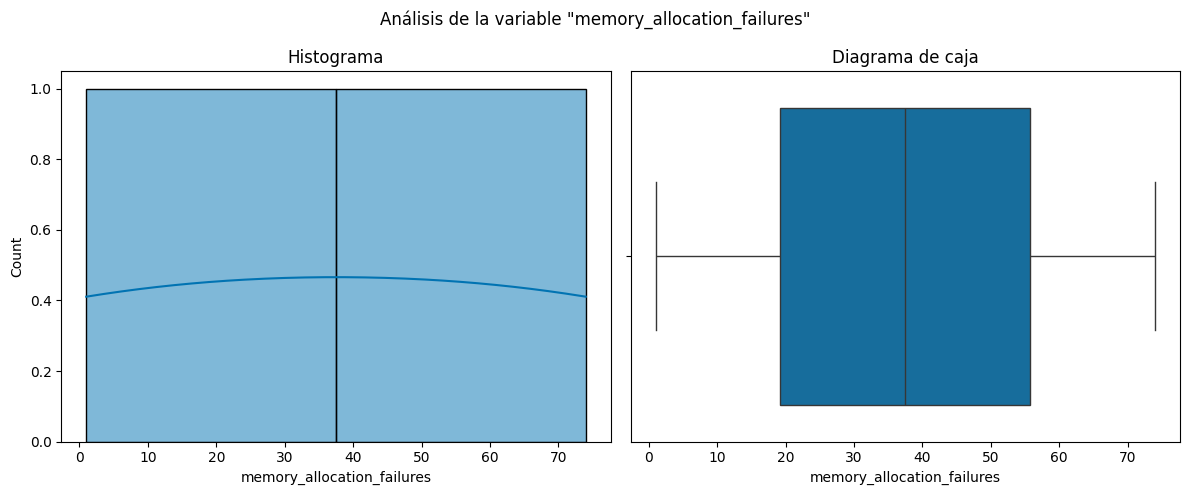

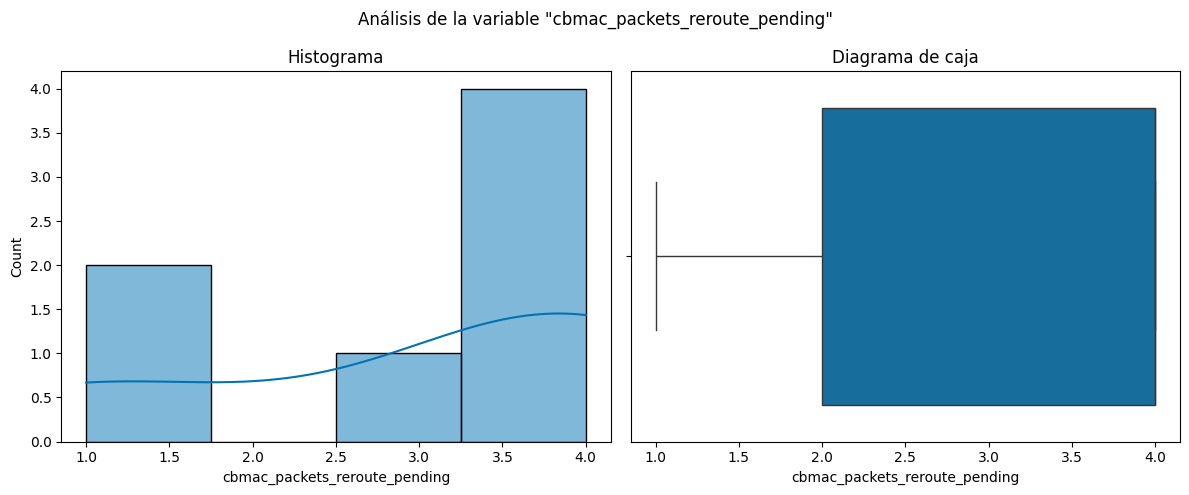

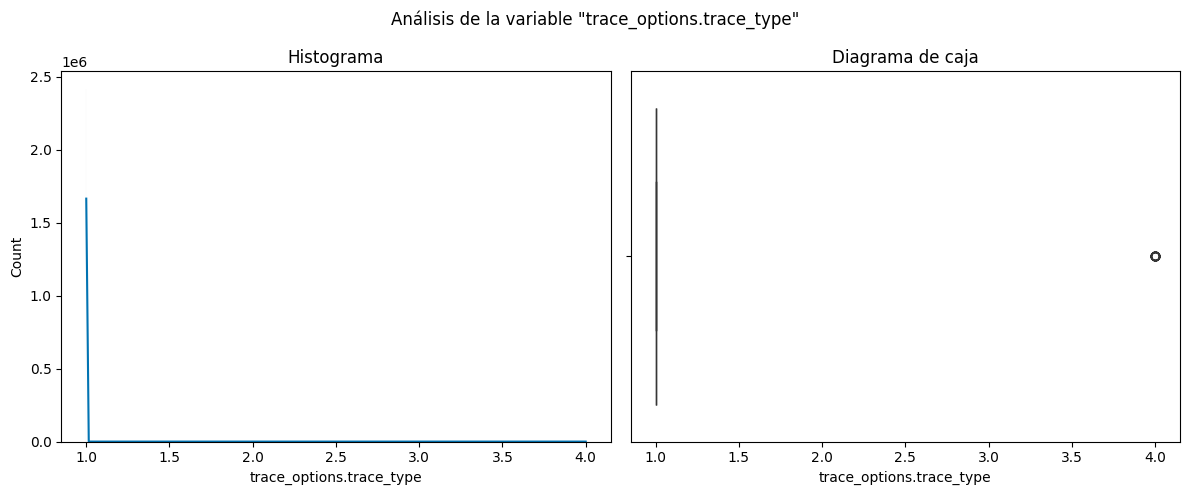

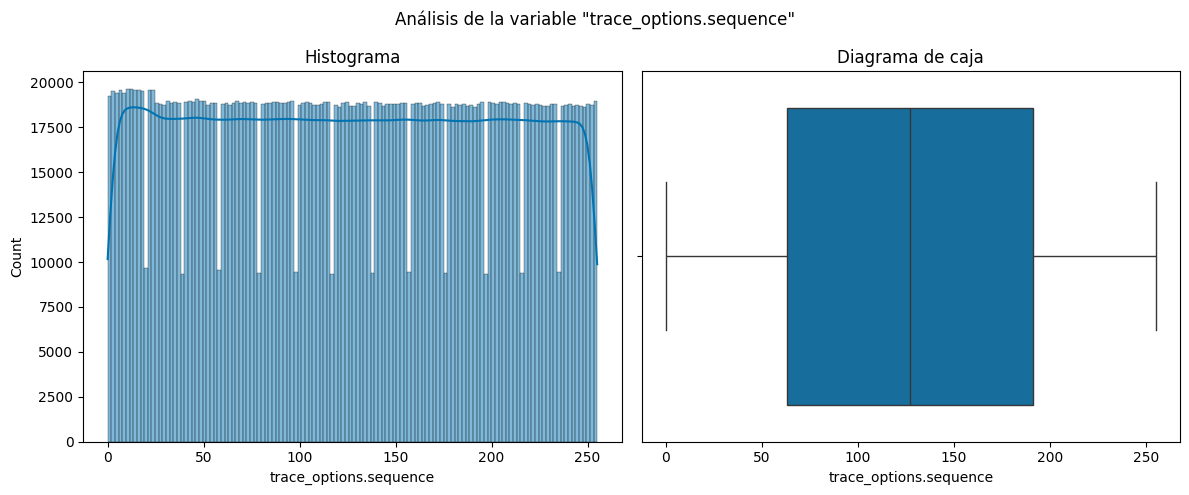

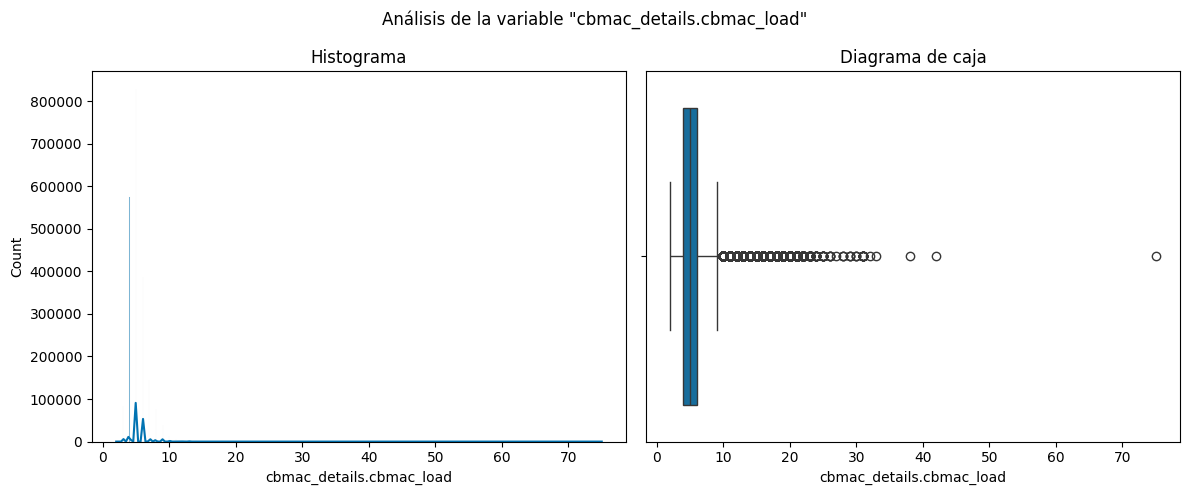

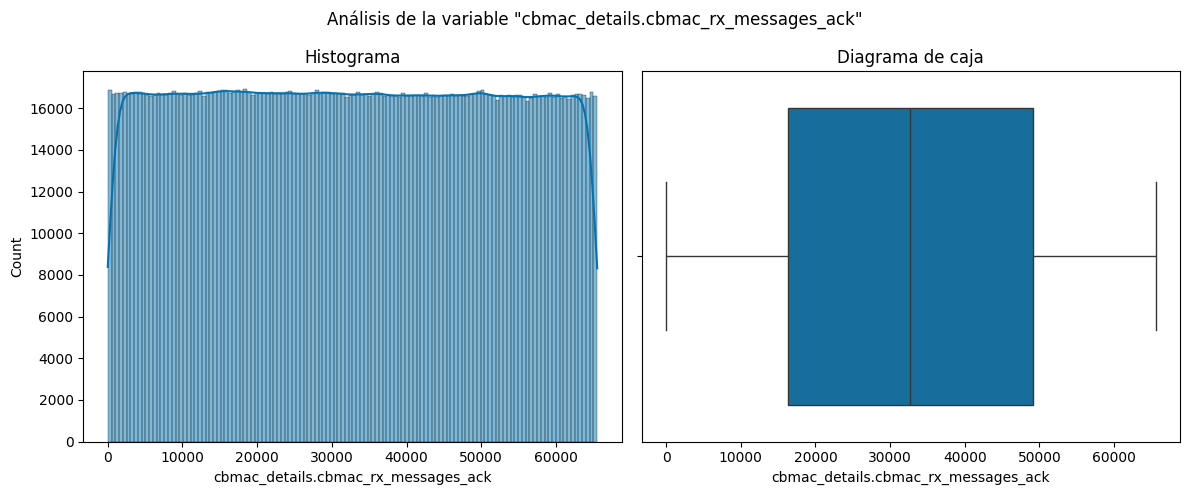

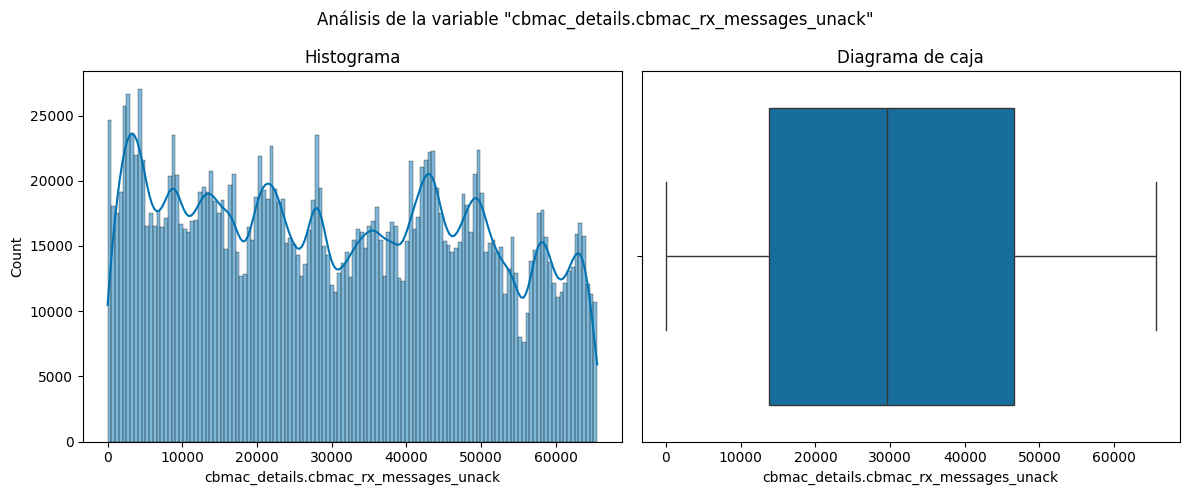

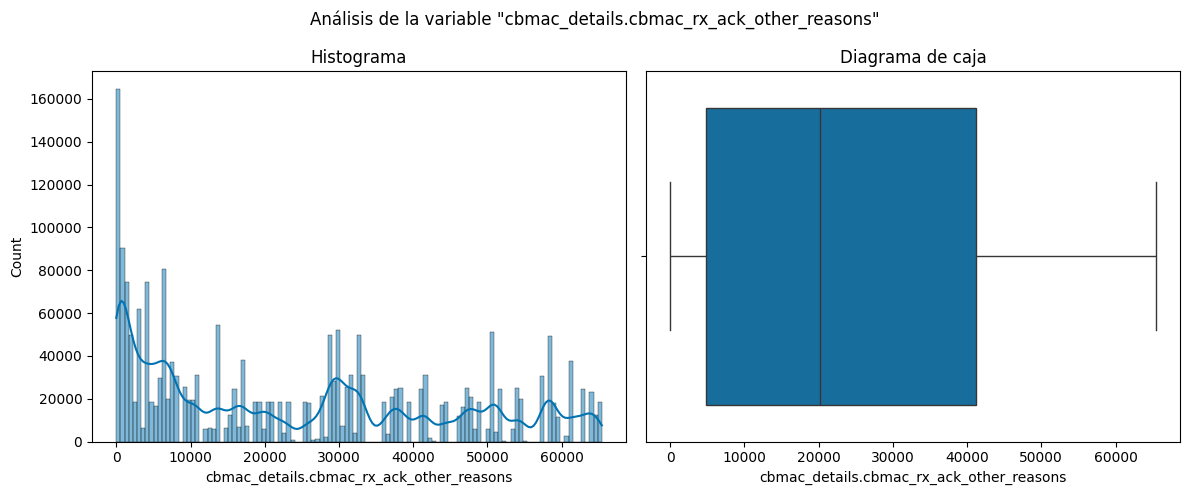

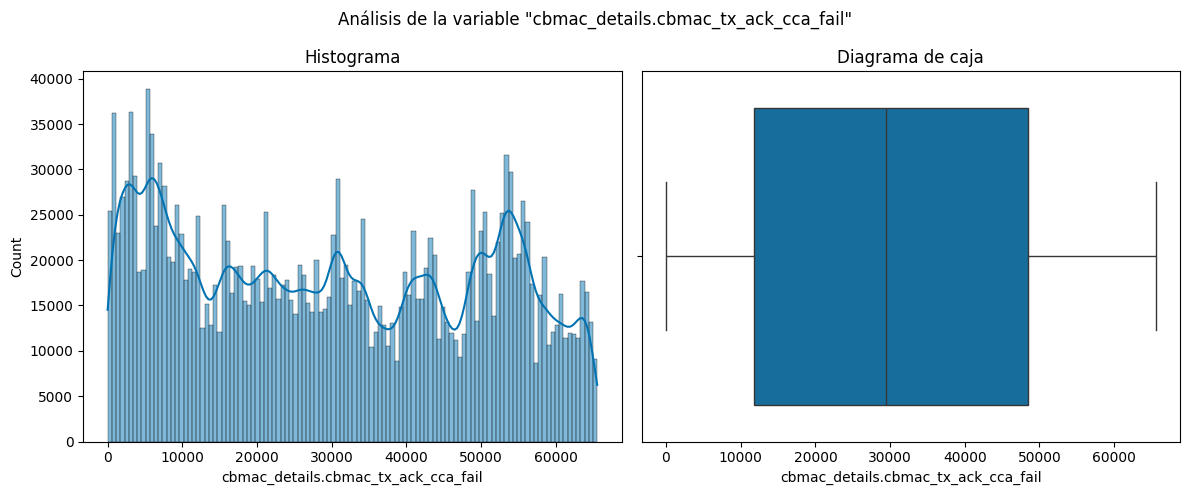

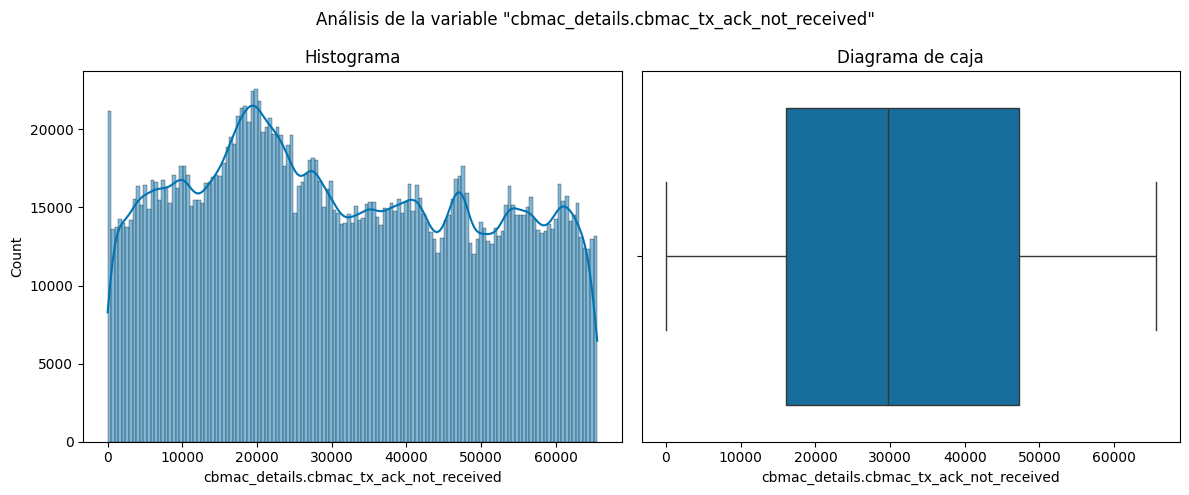

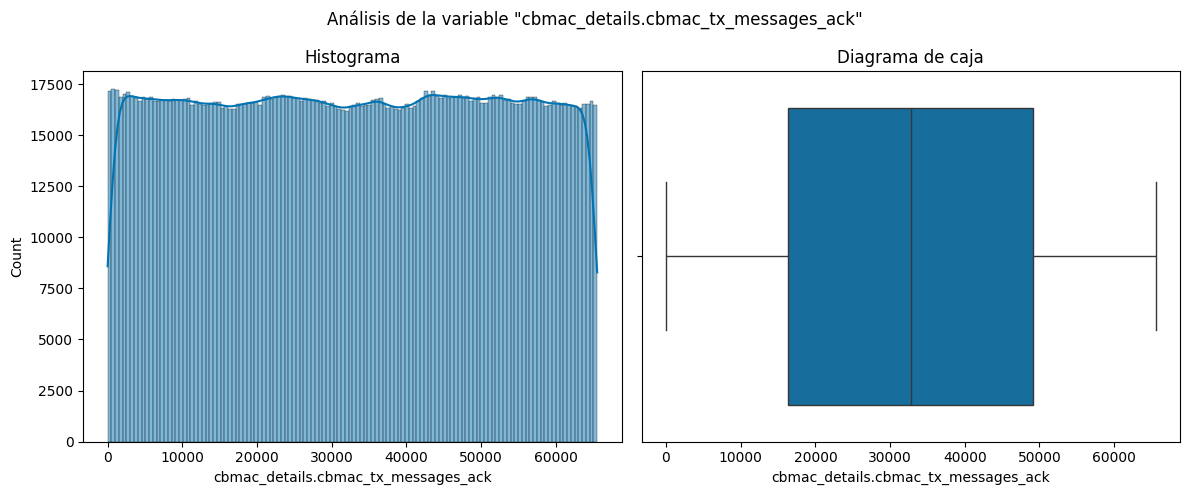

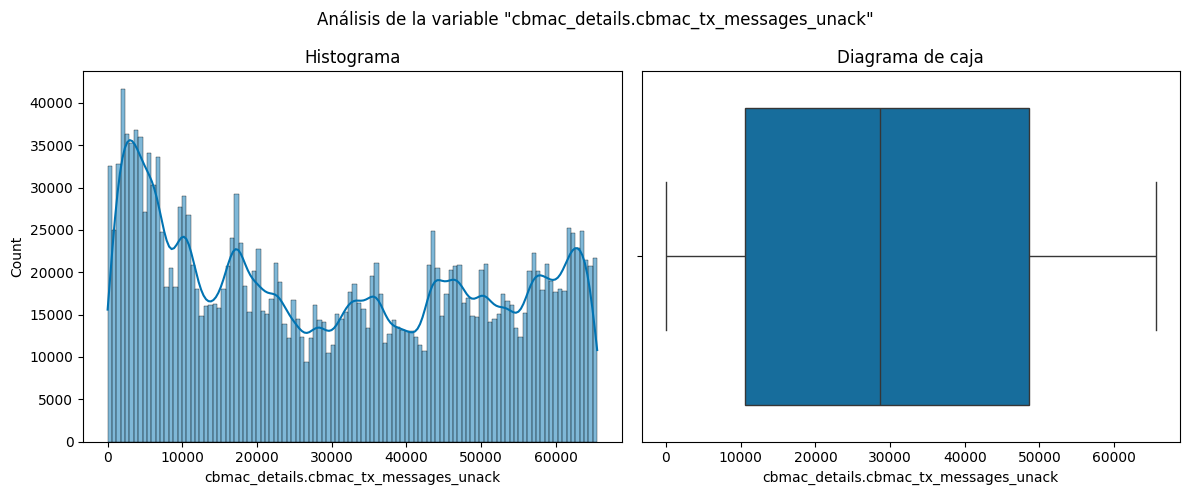

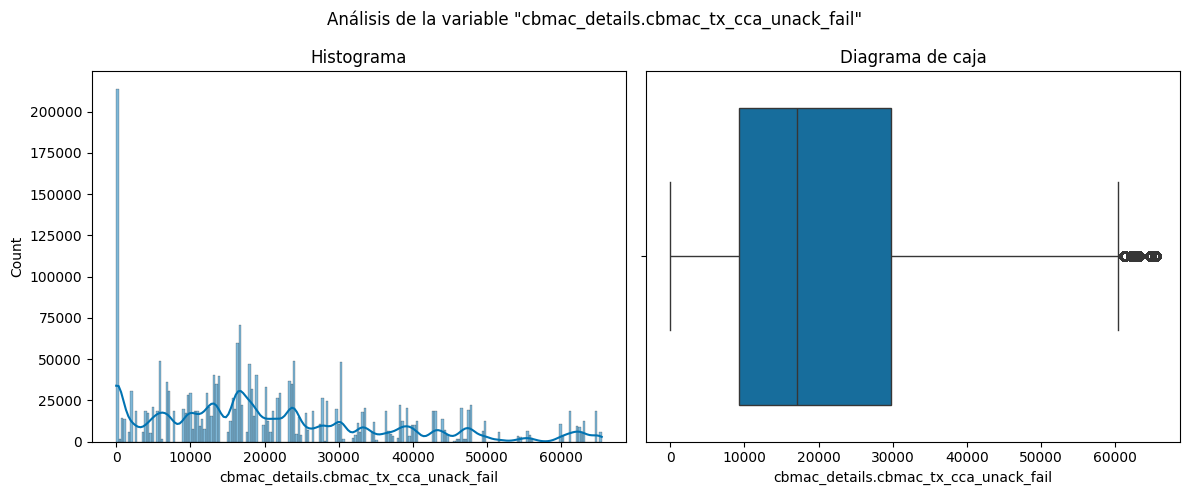

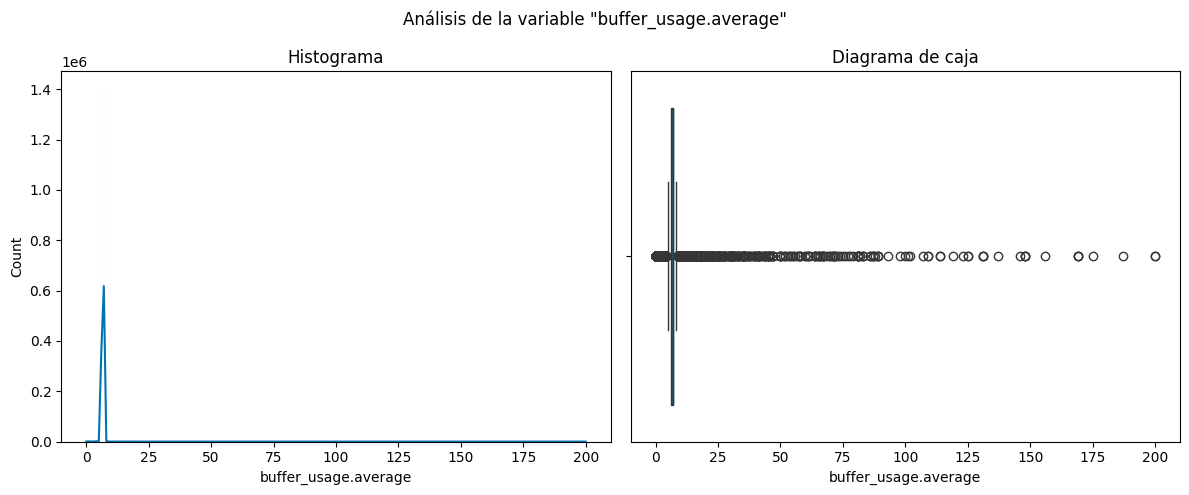

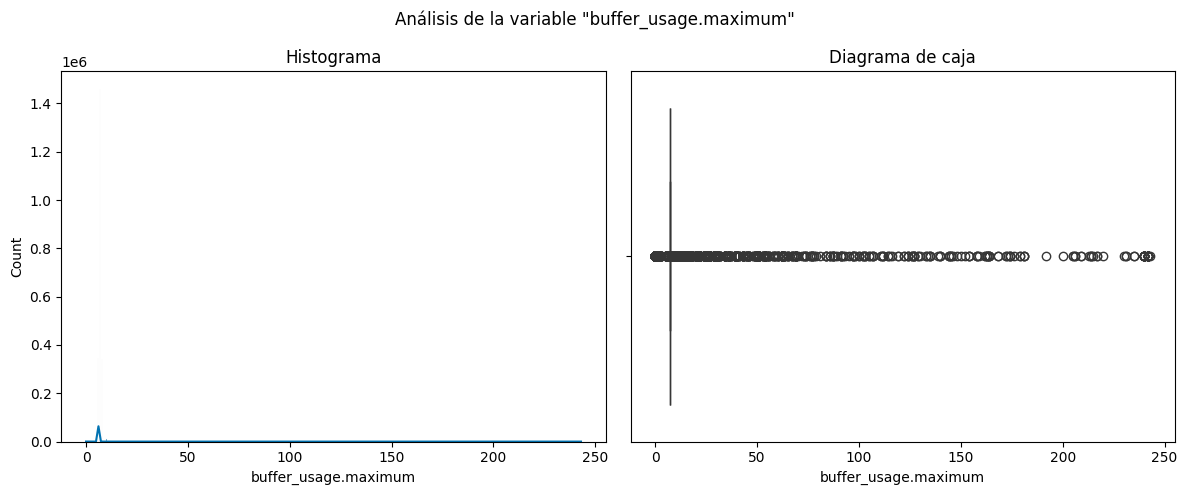

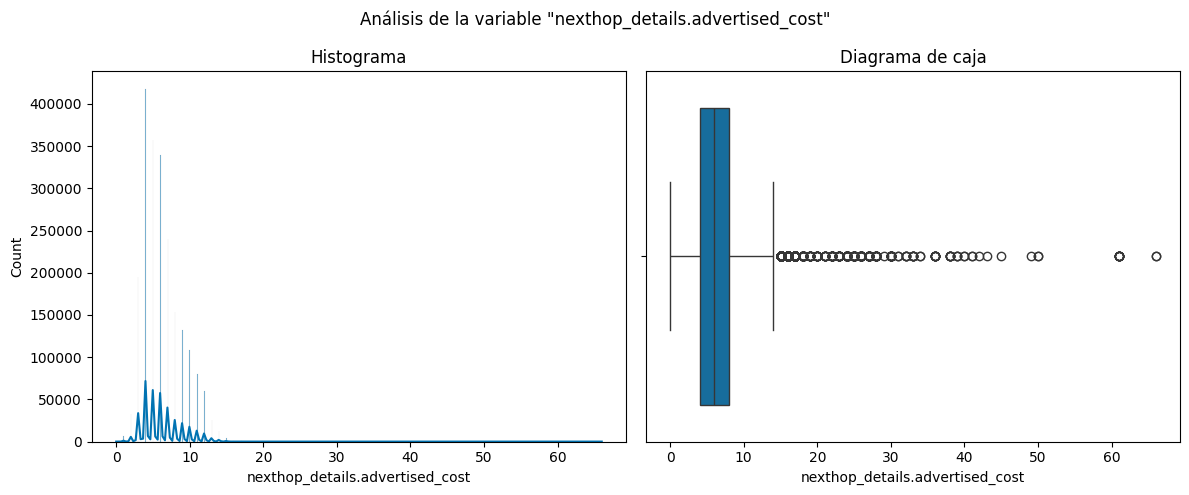

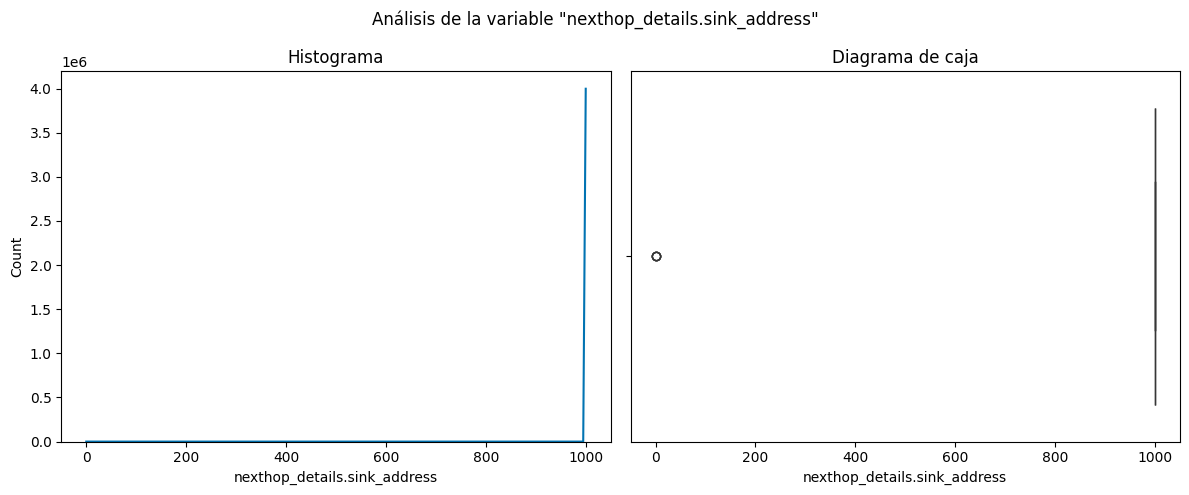

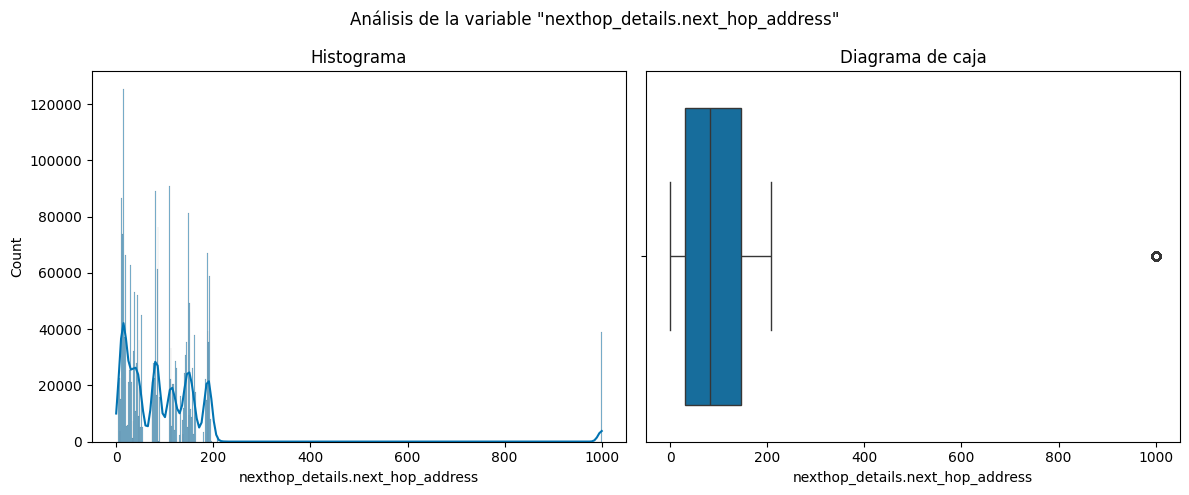

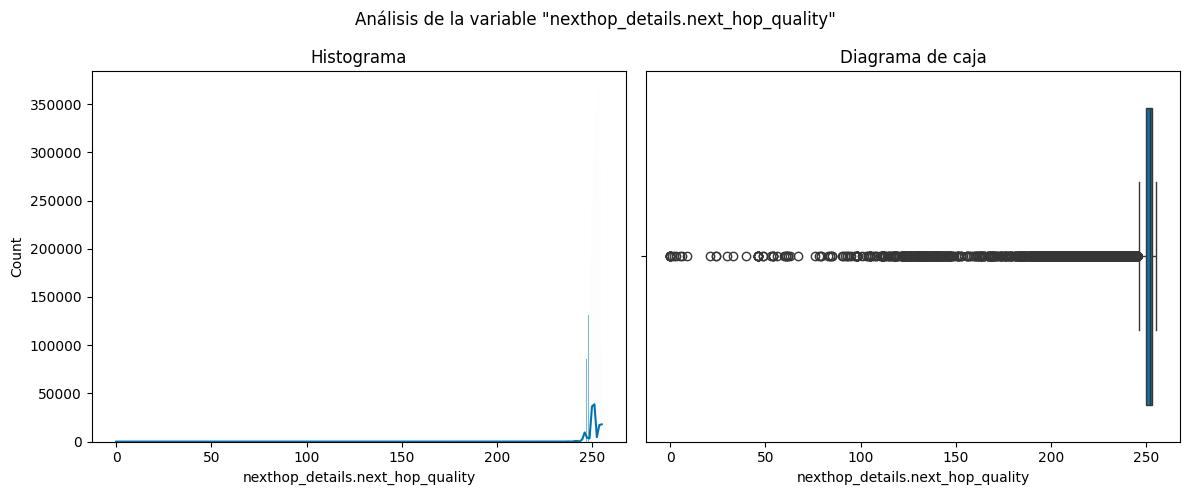

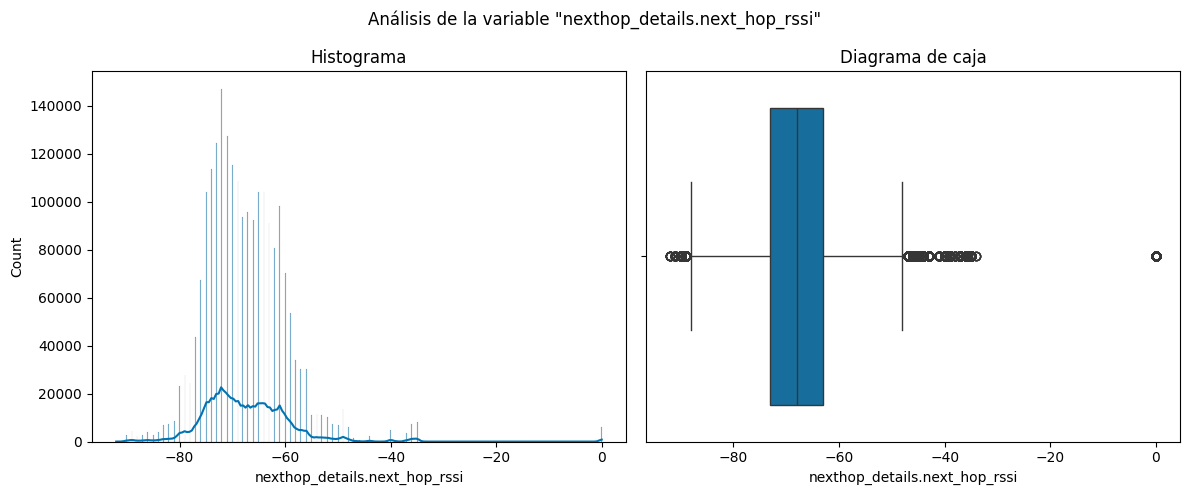

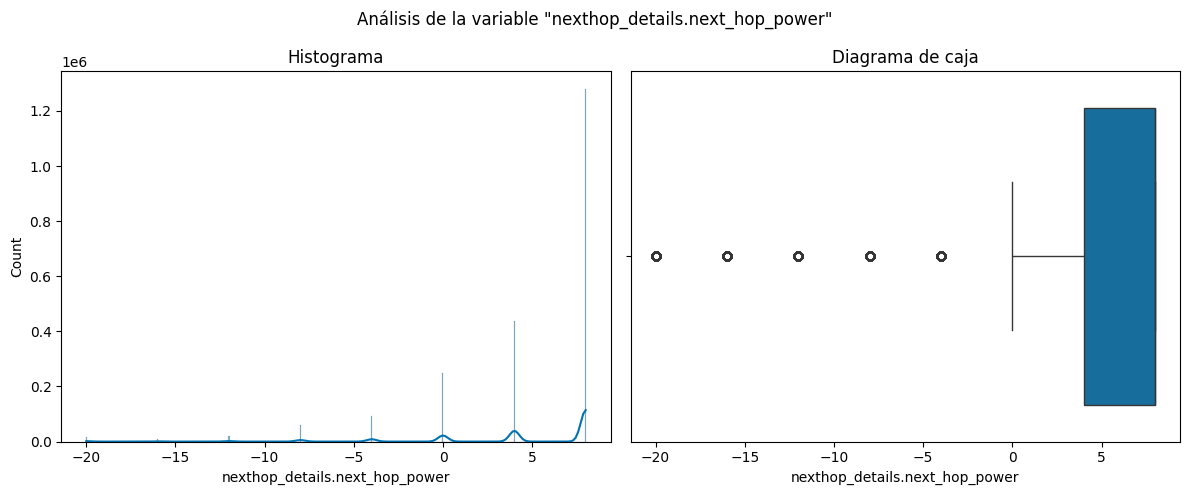

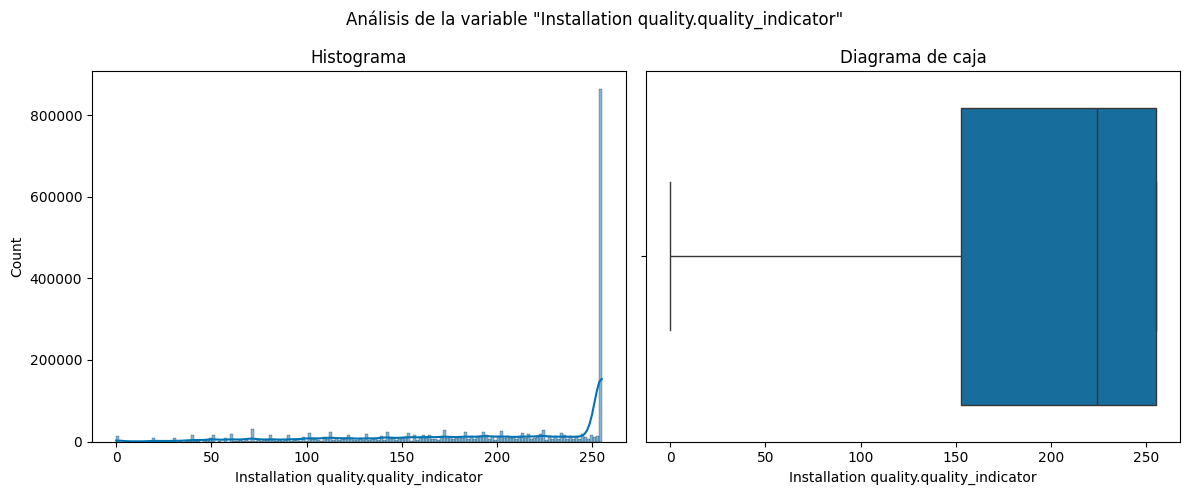

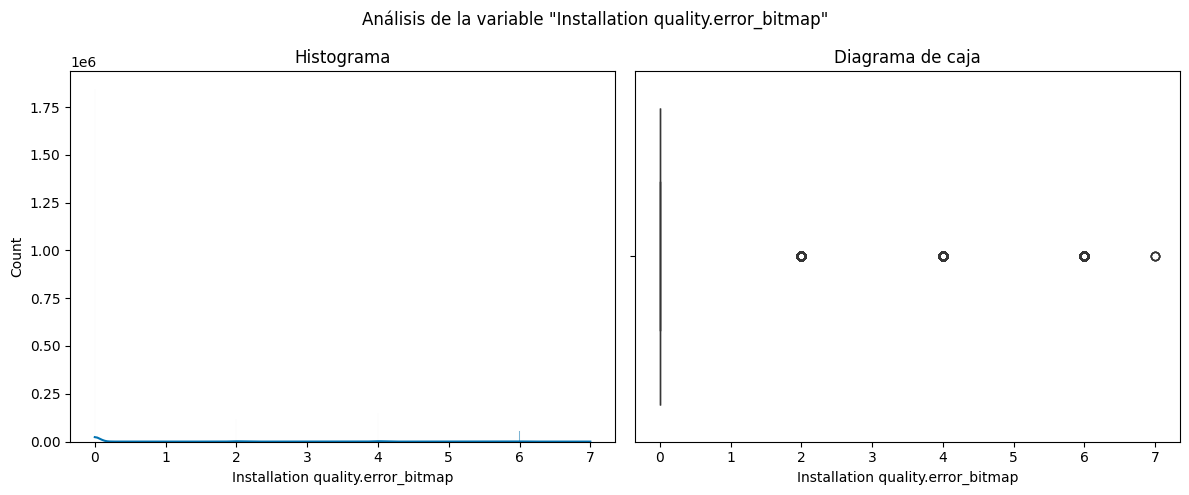

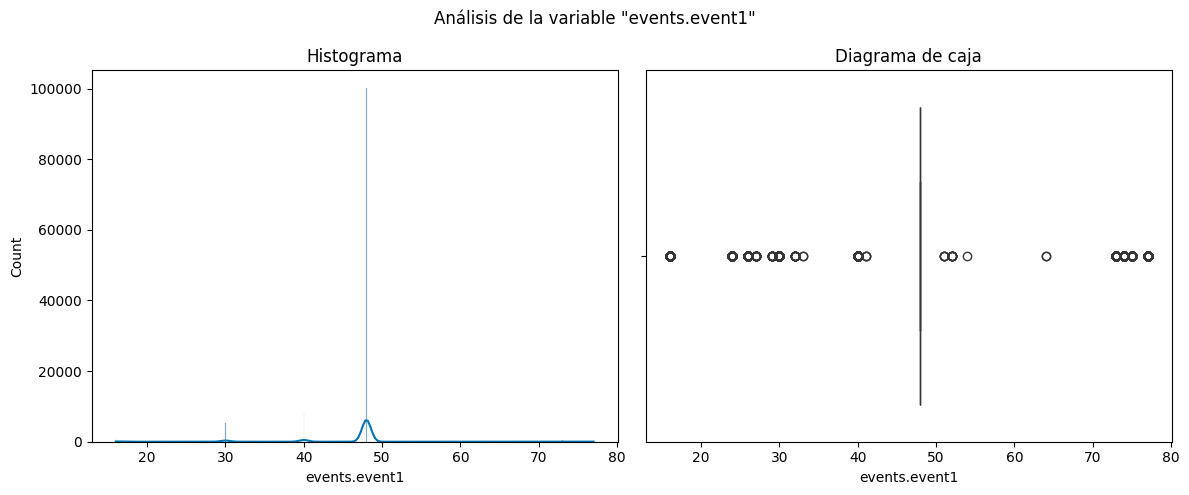

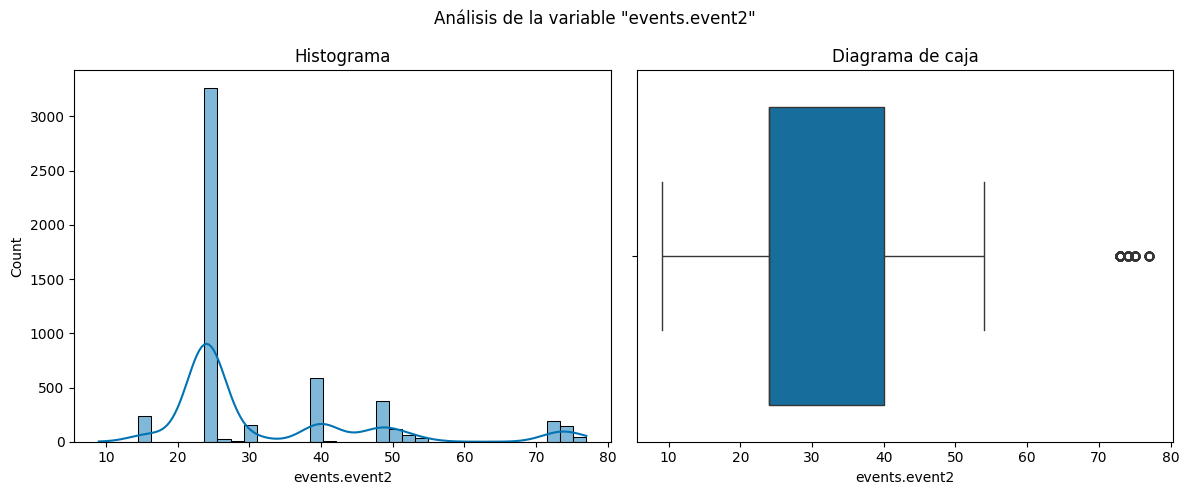

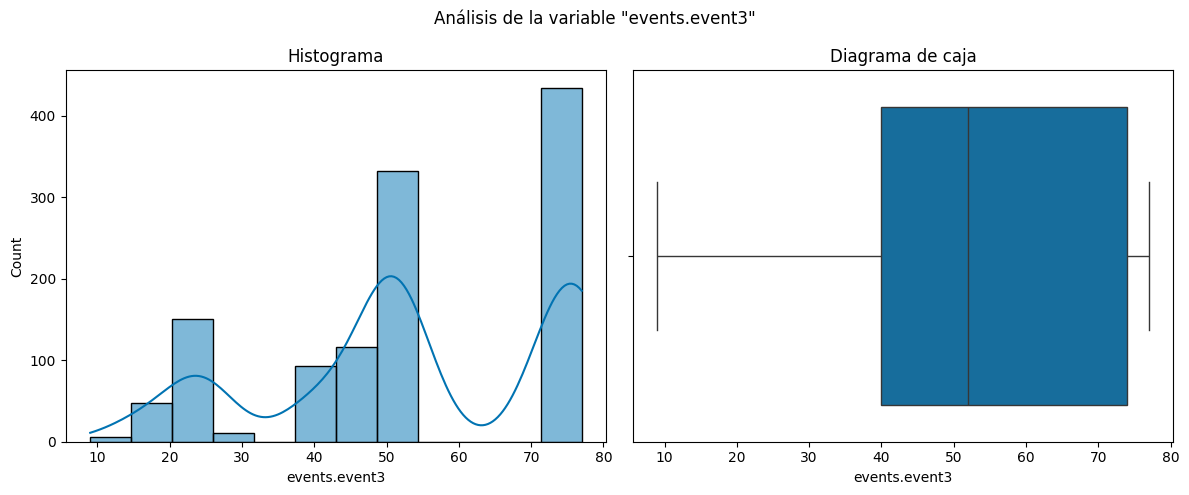

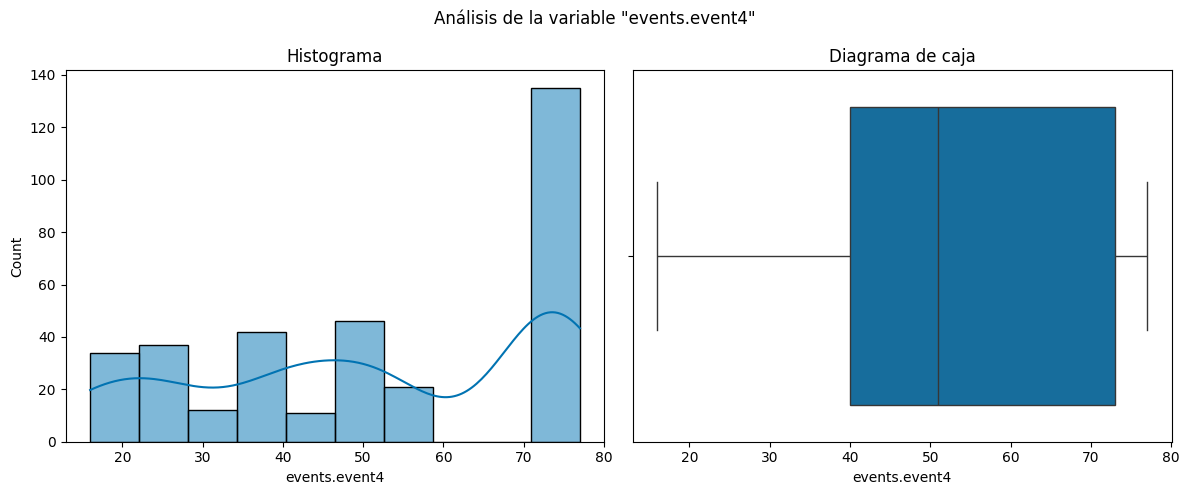

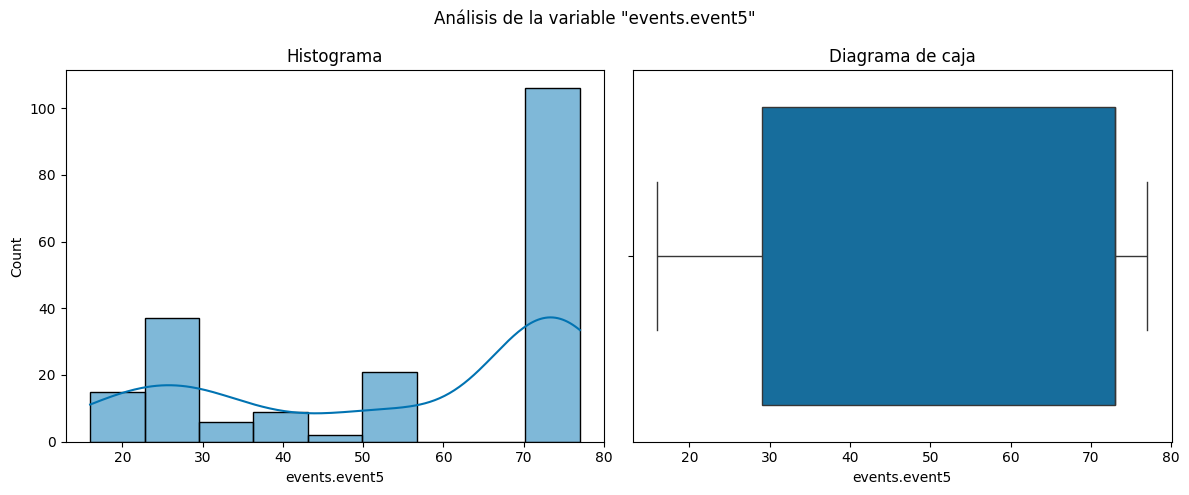

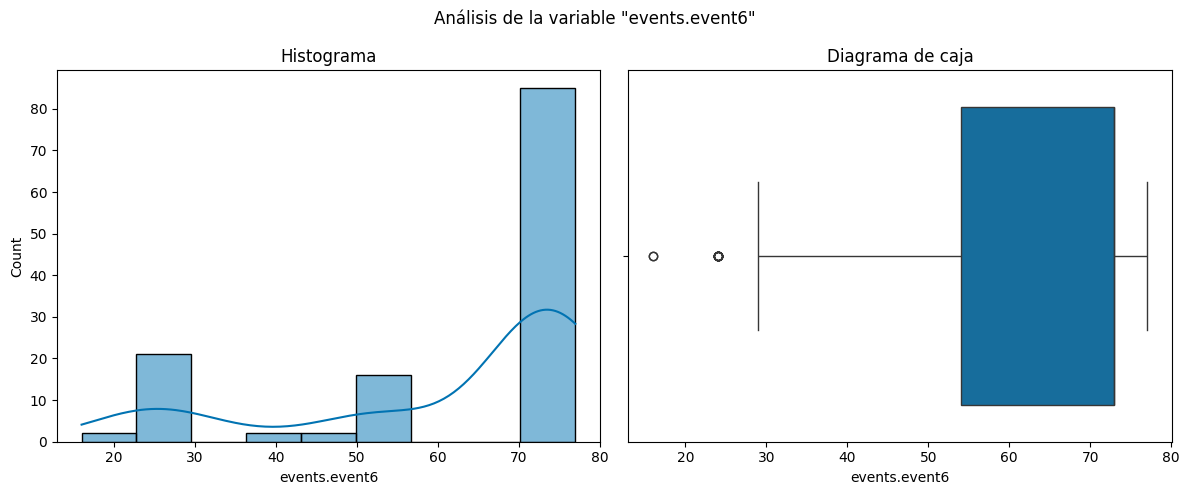

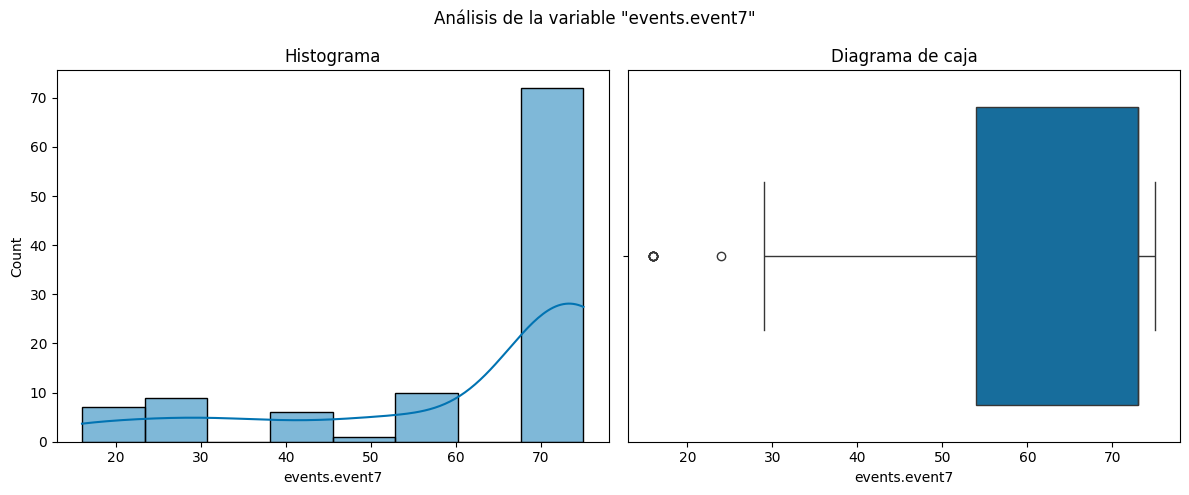

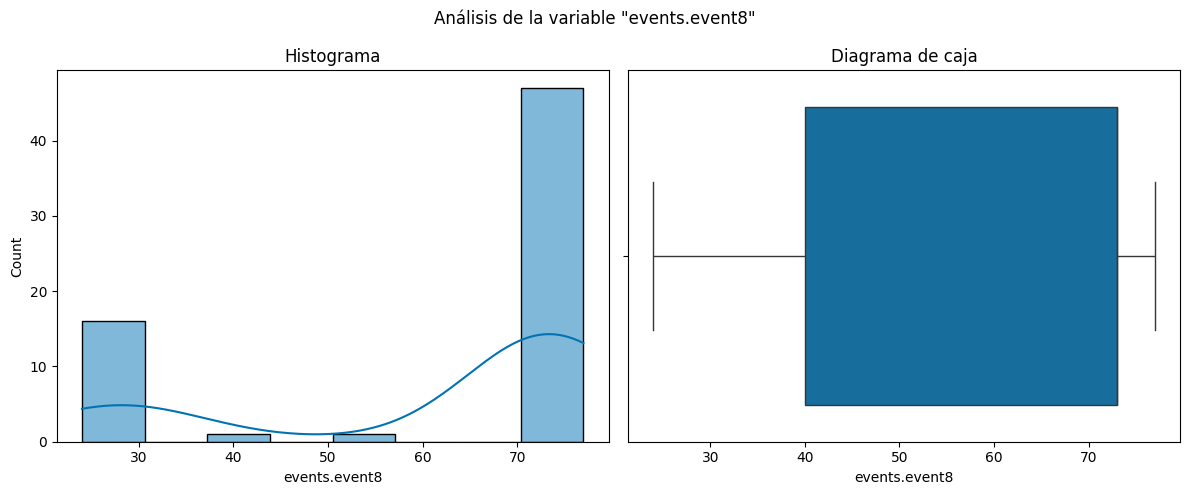

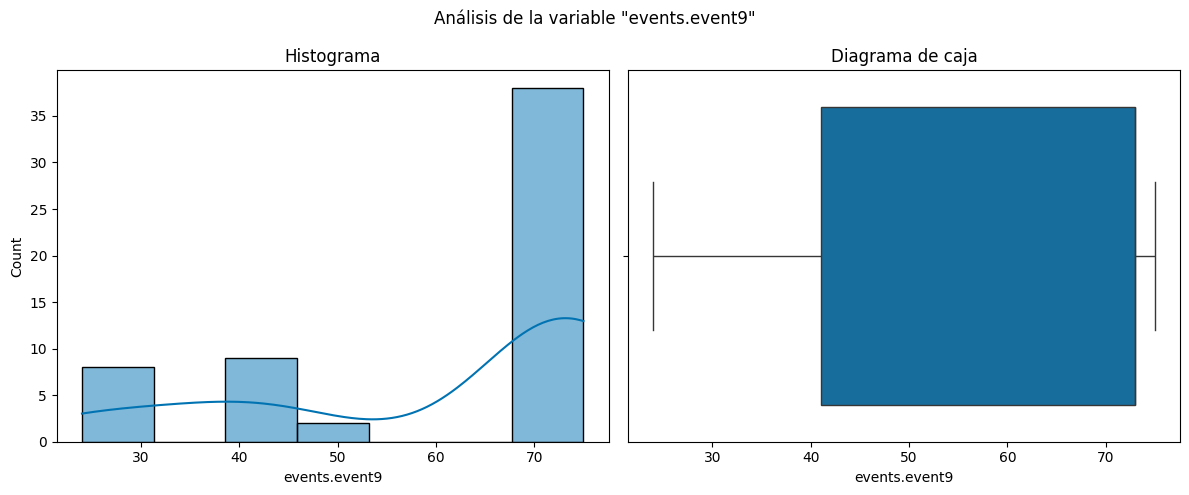

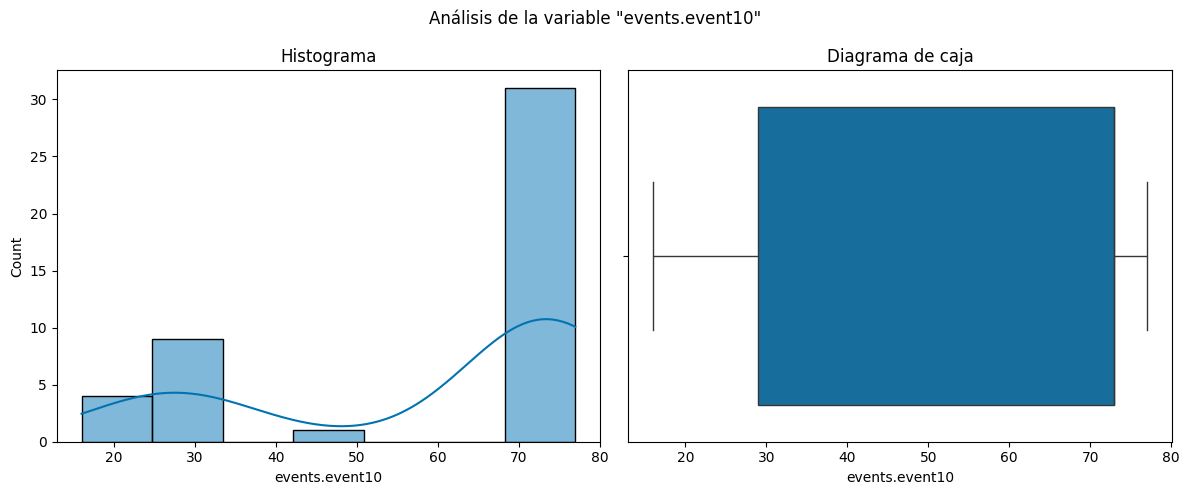

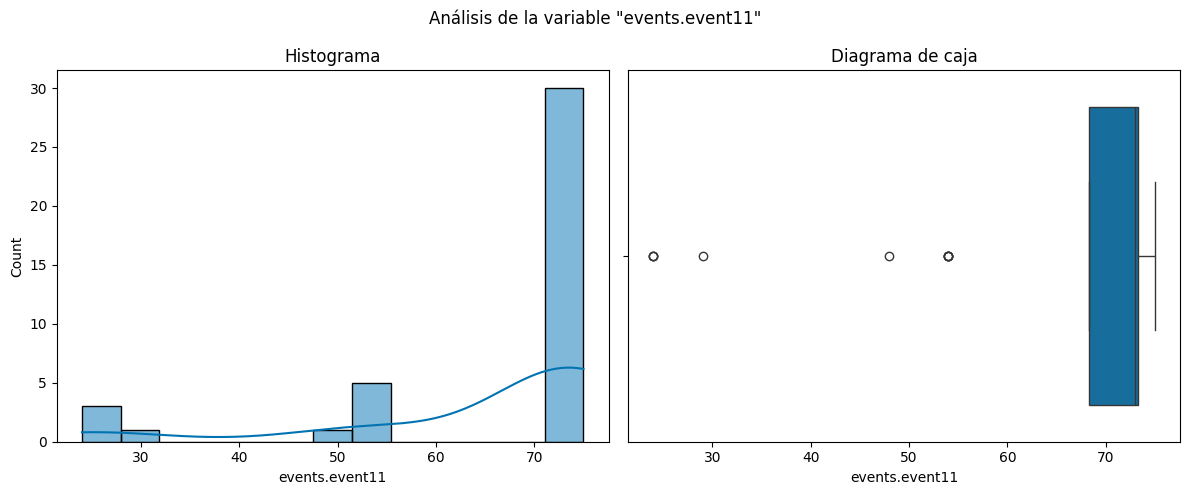

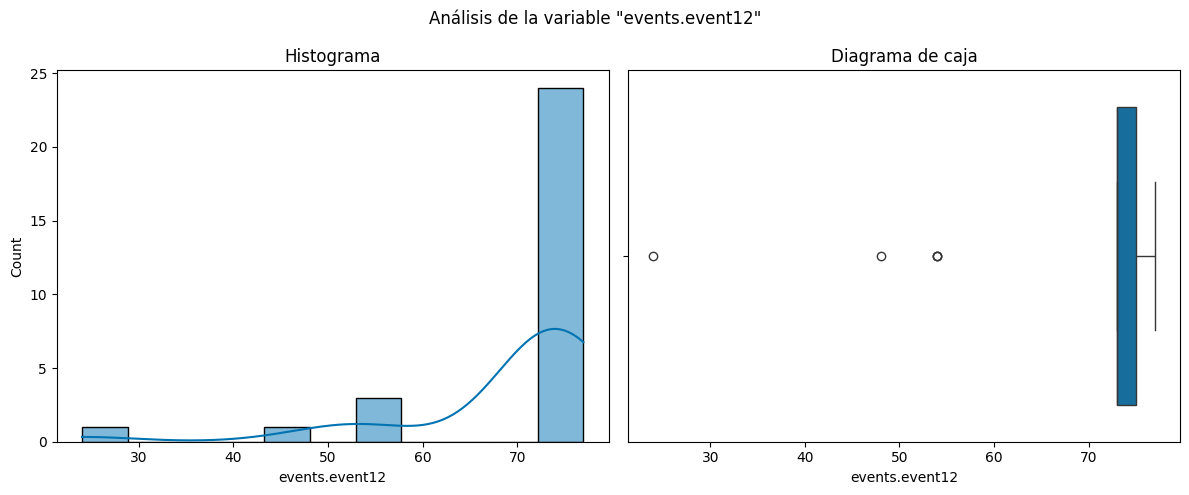

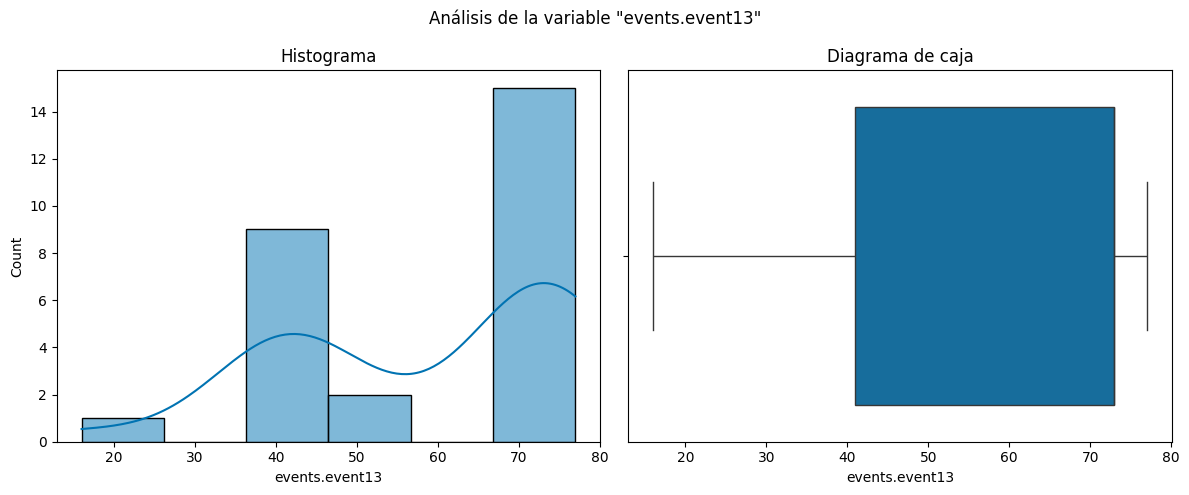

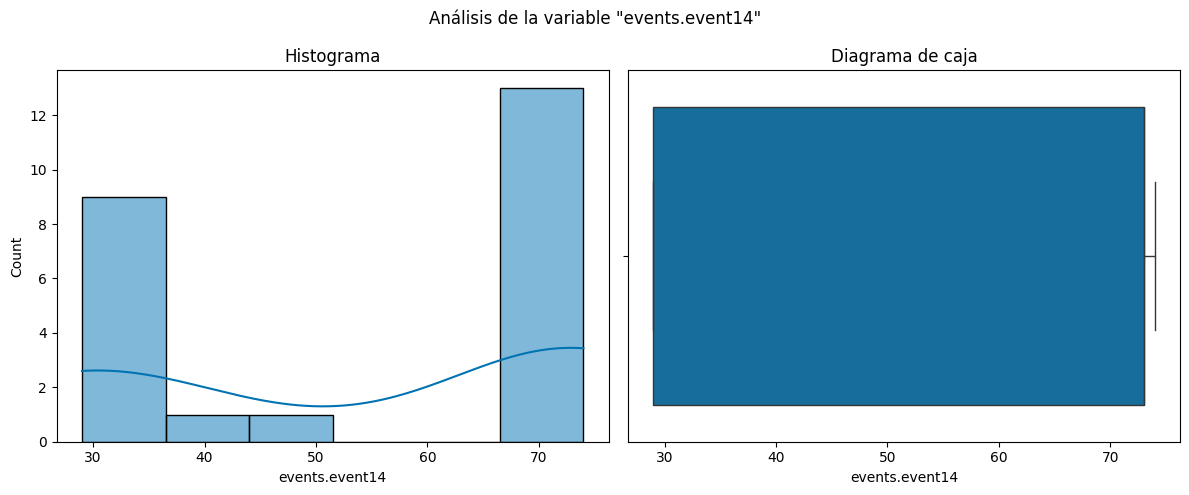

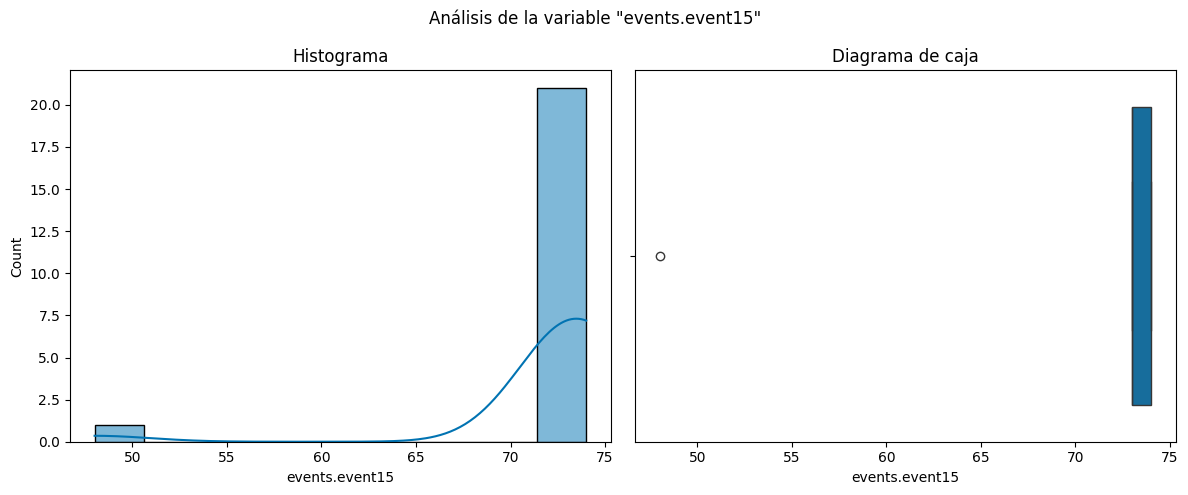

Columnas omitidas y razones:
- two_in_one_battery_level: columna constante
- configuration: columna constante
- last_hw_test_result: columna constante
- last_sw_test_result: columna constante
- configured: columna constante
- sensors: columna constante
- device_type: columna constante
- battery_type: columna constante
- app_firmware_major: columna constante
- app_firmware_minor: columna constante
- app_firmware_maintenaince: columna constante
- app_stack_major: columna constante
- app_stack_maintenaince: columna constante
- events: columna constante
- cbmac_broadcast_unack_pending: columna constante
- CCA_limit_dBm: columna constante
- Rx_gain: columna constante
- boot_fault_reason: columna constante
- stack_profile: columna constante
- scratchpad_processed_sequence: columna constante
- otap_support: columna constante
- cbmac_details: columna constante
- buffer_usage: columna constante
- nexthop_details: columna constante
- Installation quality: columna constante
- trace_options: colum

In [13]:
# Create plots
skipped = {}
const_cols = []
for column in numerical_features:
    try:
        # Extraer la columna
        x = X_train[column]

        # Comprobar que queda más de 1 valor
        if len(x) < 2:
            skipped[column] = "menos de 2 valores"
            continue

        # Evitar columnas constantes (boxplot rompe si no varían)
        if x.nunique() < 2:
            skipped[column] = "columna constante"
            continue

        # Graficar
        plt.figure(figsize=(12,5))

        # Histograma
        plt.subplot(1, 2, 1)
        sns.histplot(x, kde=True)
        plt.title("Histograma")

        # Boxplot
        plt.subplot(1, 2, 2)
        sns.boxplot(x=x)
        plt.title("Diagrama de caja")

        plt.suptitle(f'Análisis de la variable \"{column}\"')
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error en la columna '{column}': {e}")

print("Columnas omitidas y razones:")
for col, reason in skipped.items():
    if reason == "columna constante":
        const_cols.append(col)
    print(f"- {col}: {reason}")

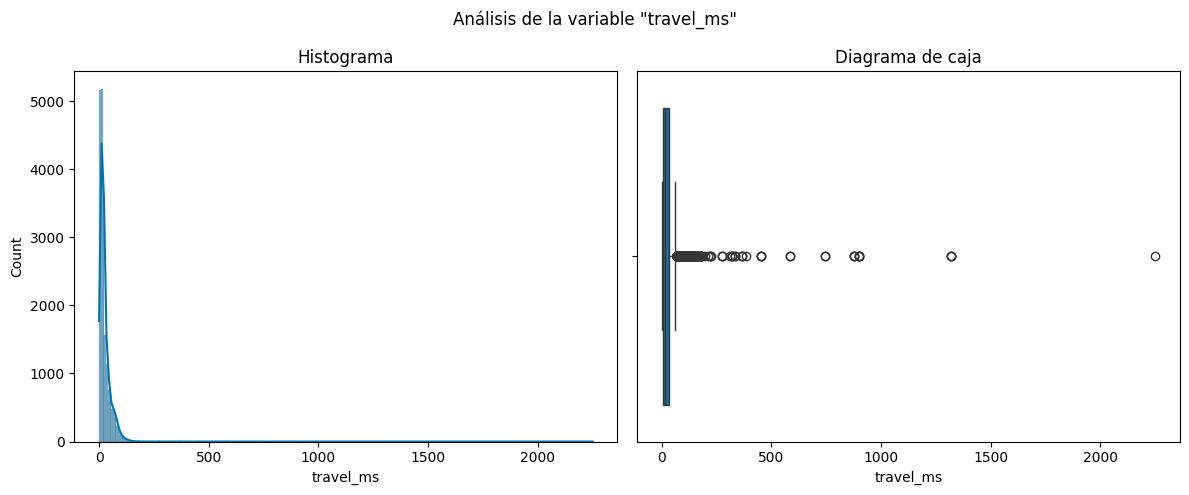

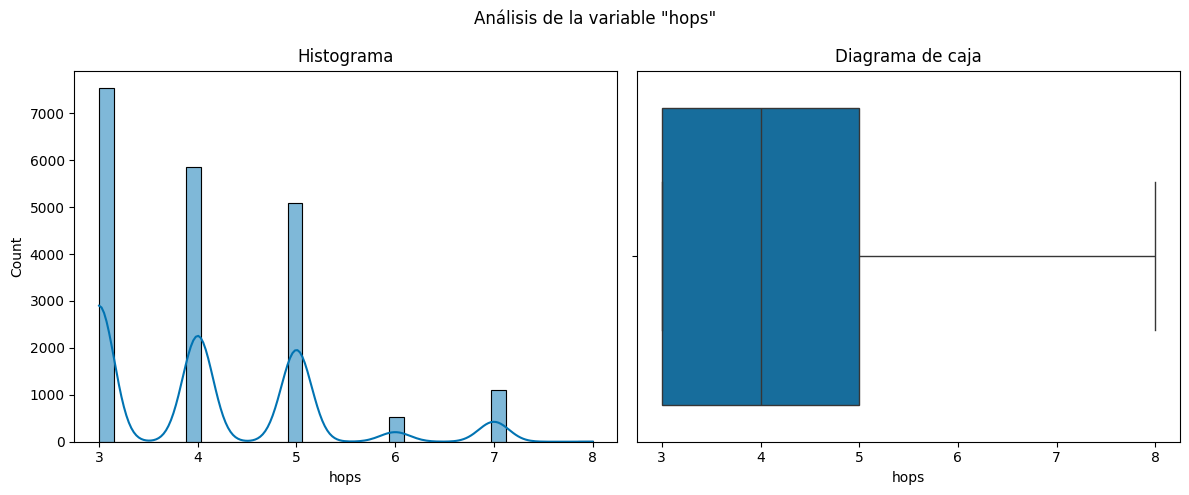

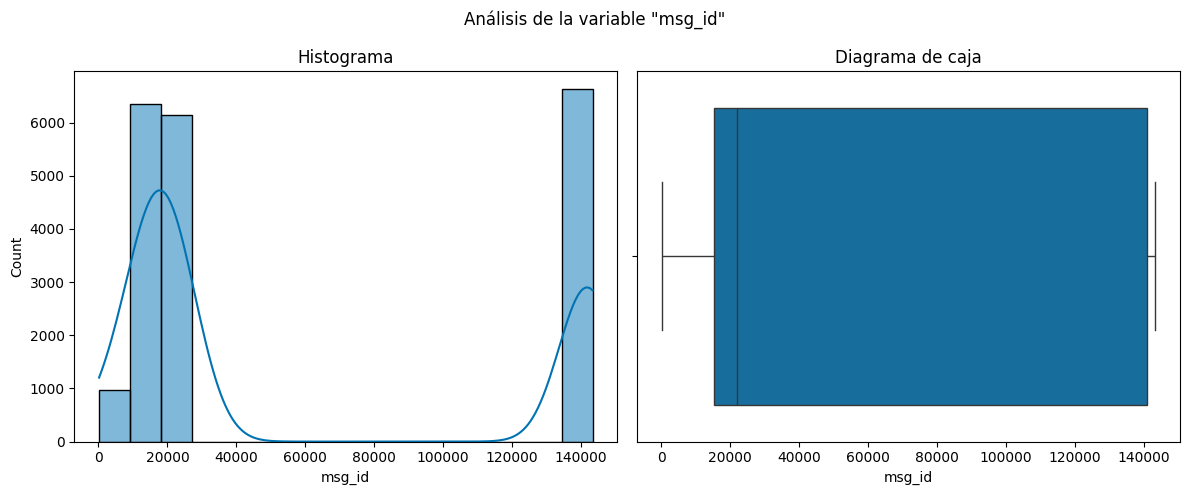

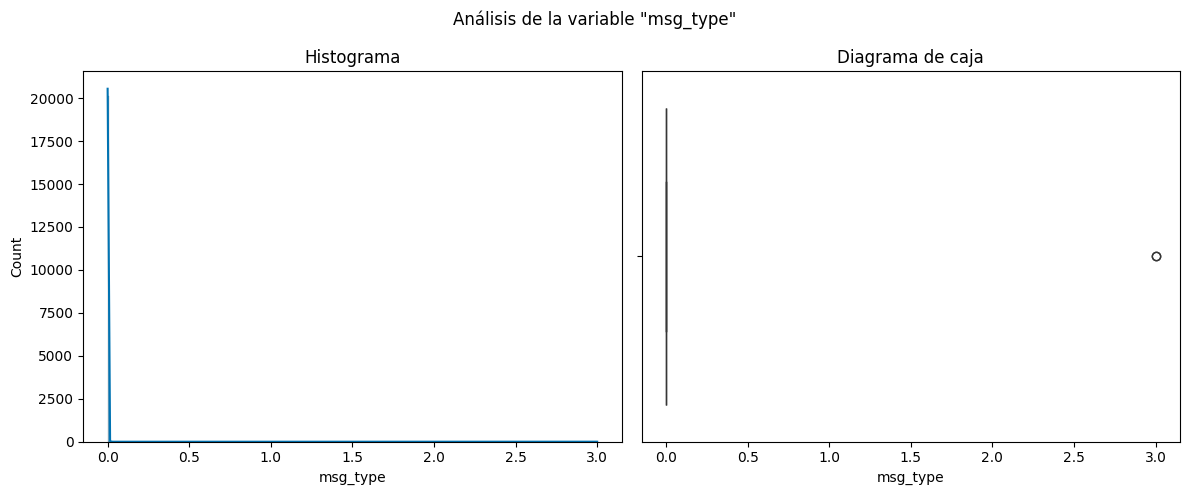

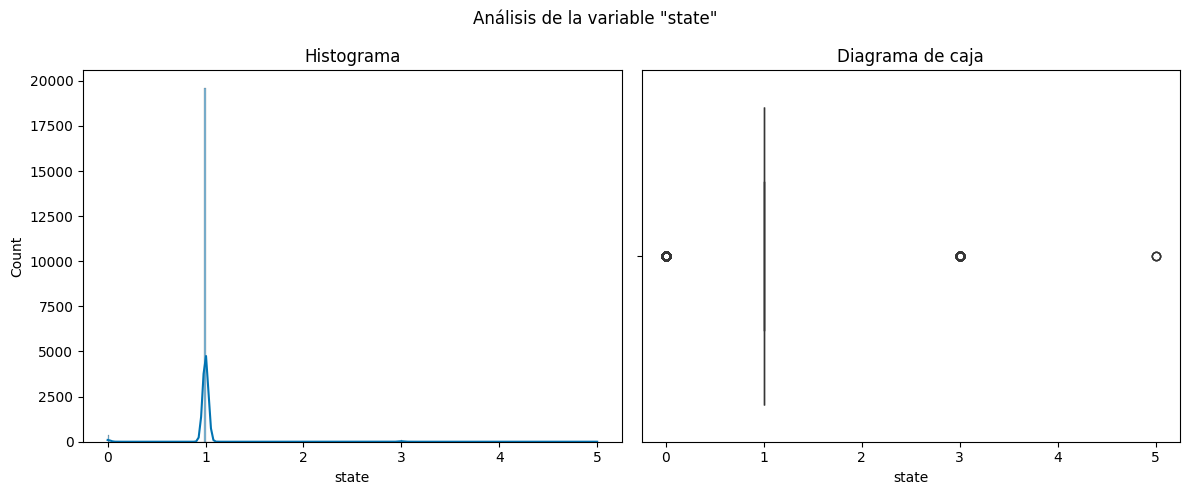

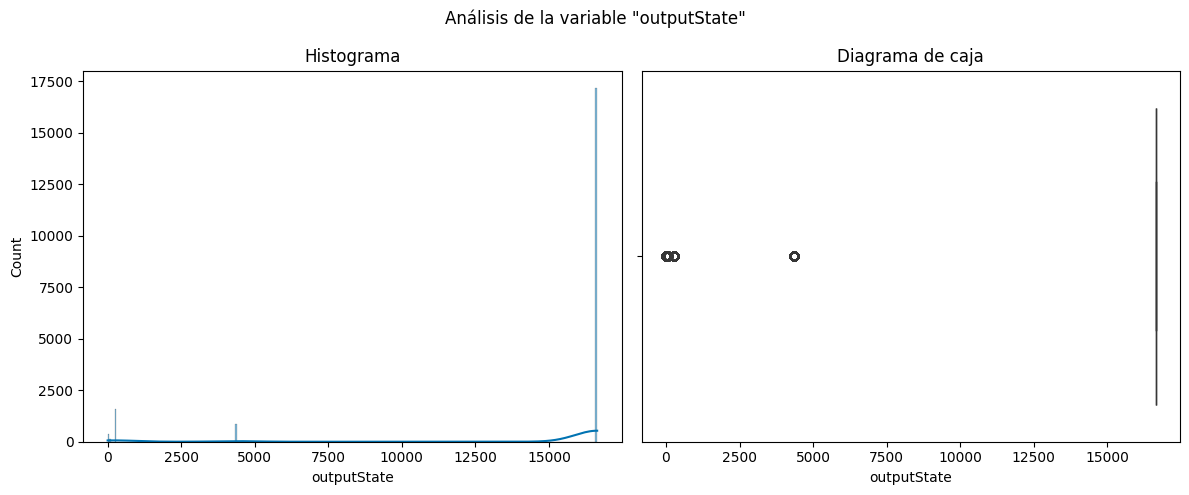

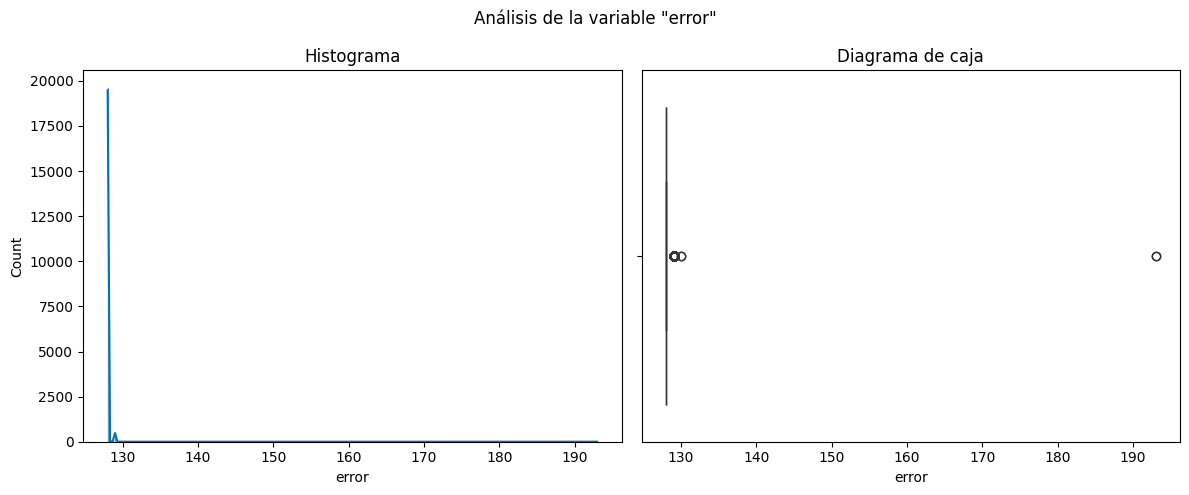

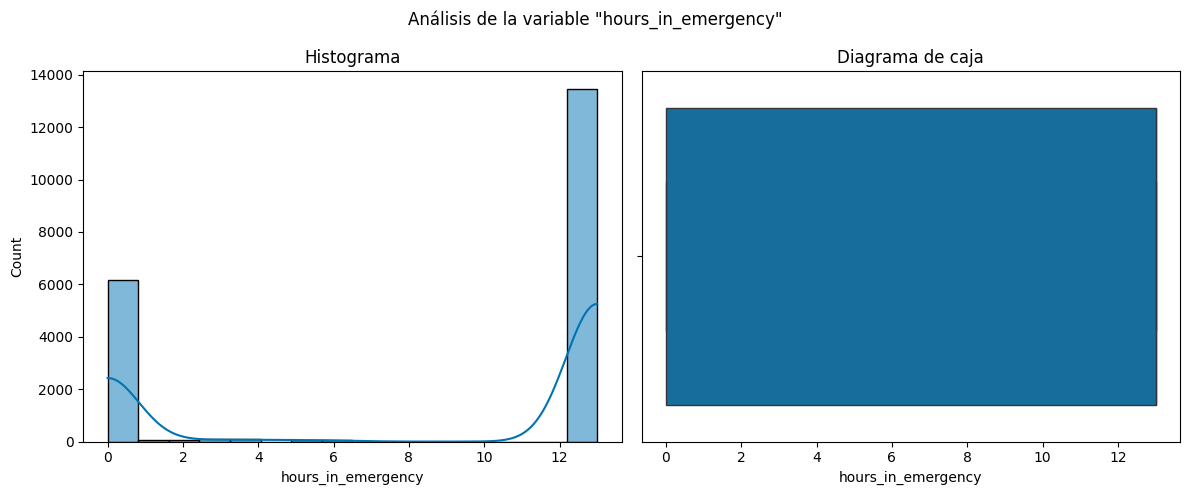

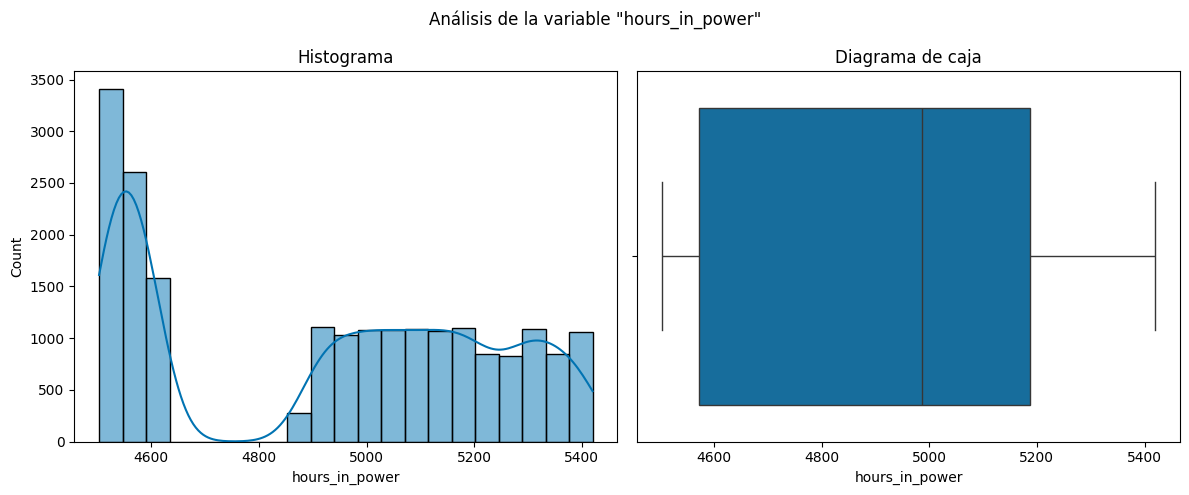

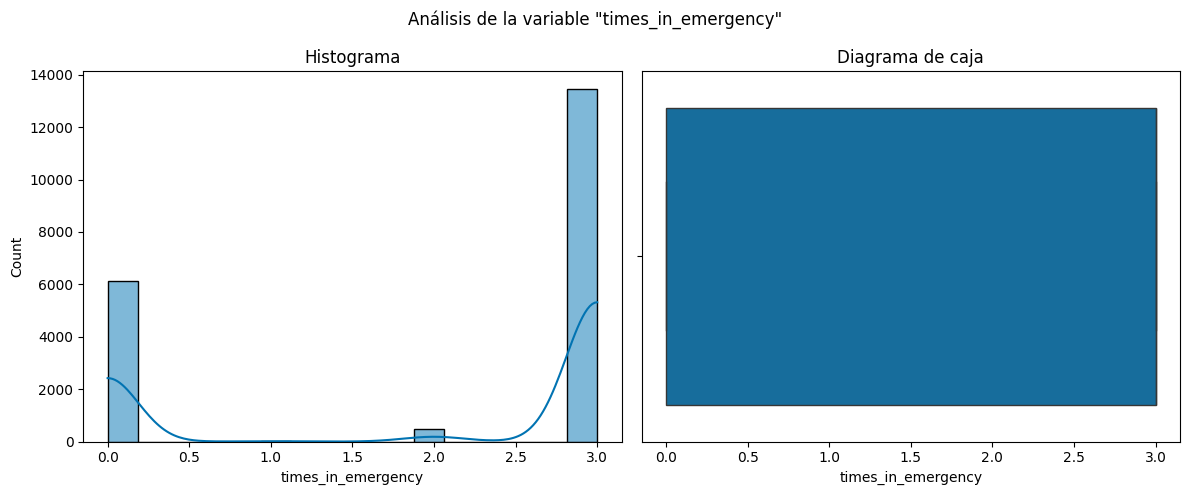

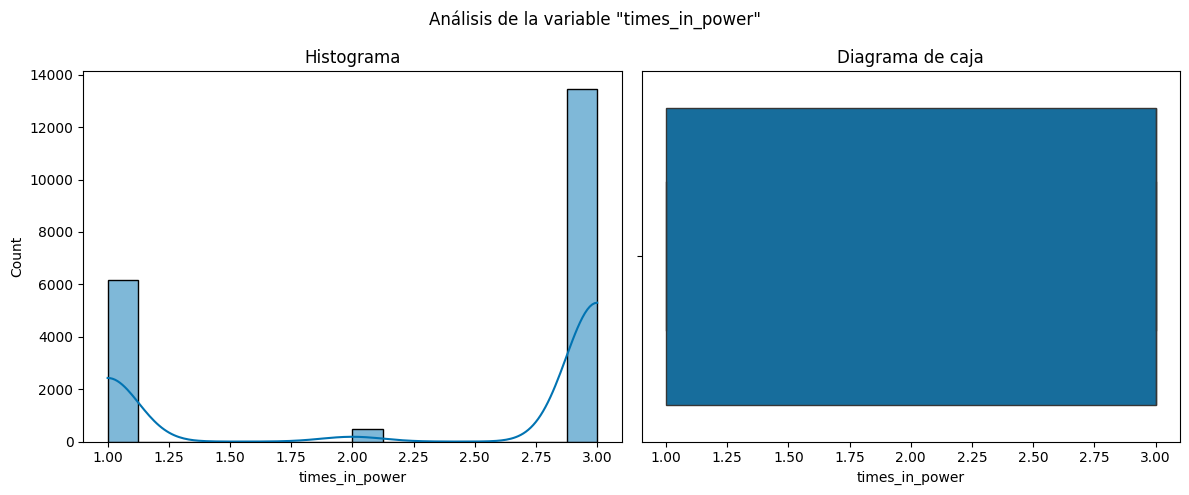

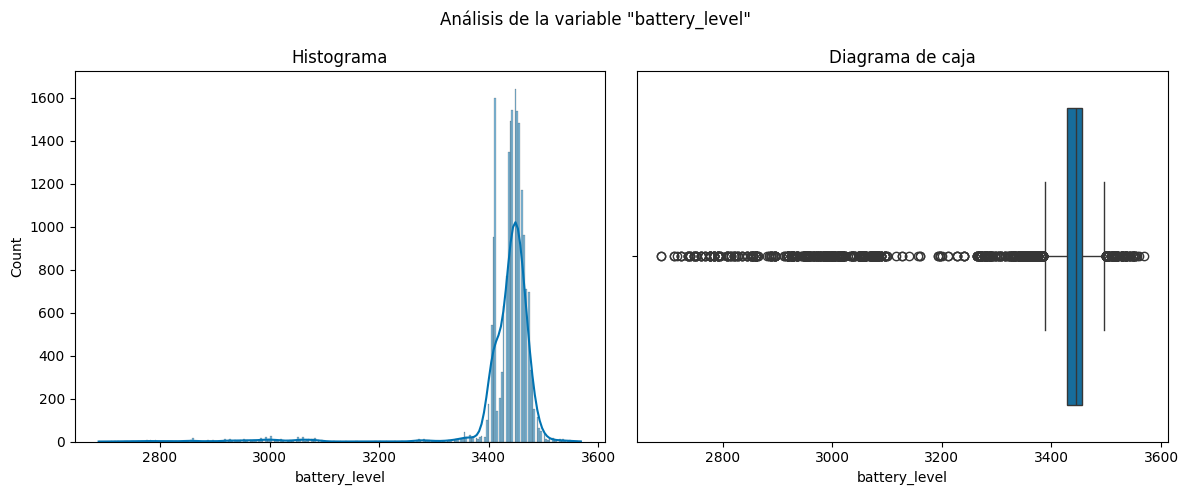

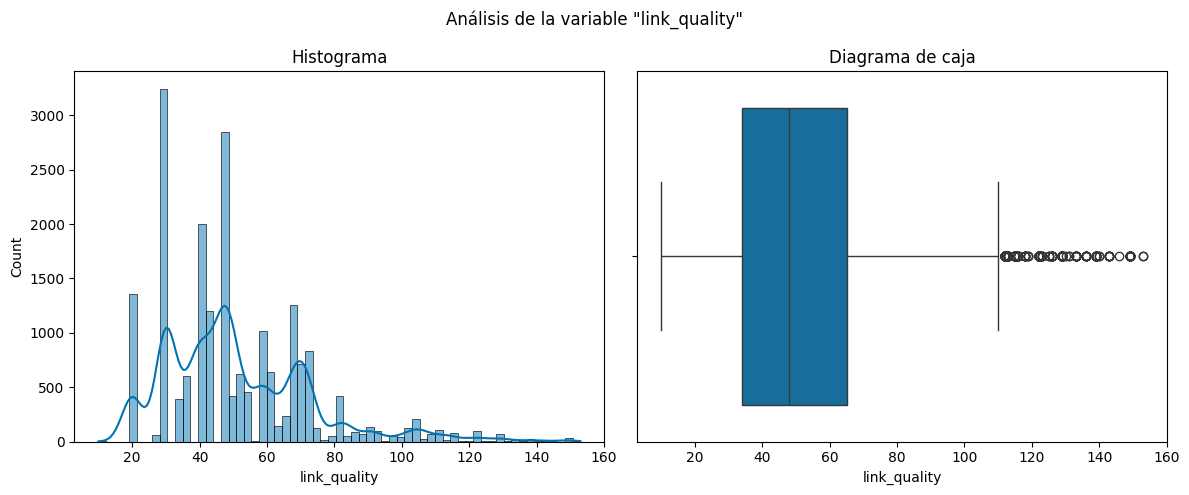

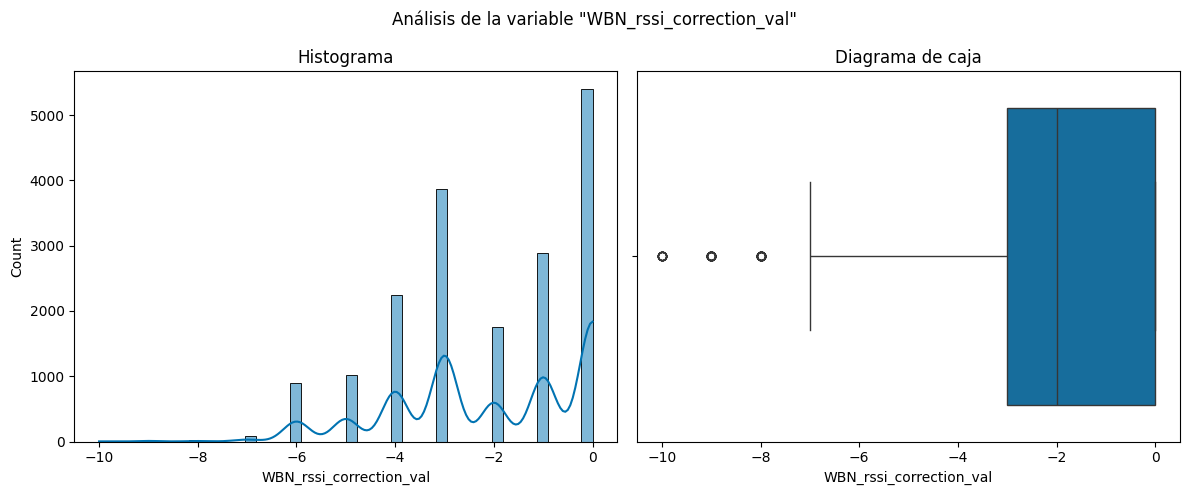

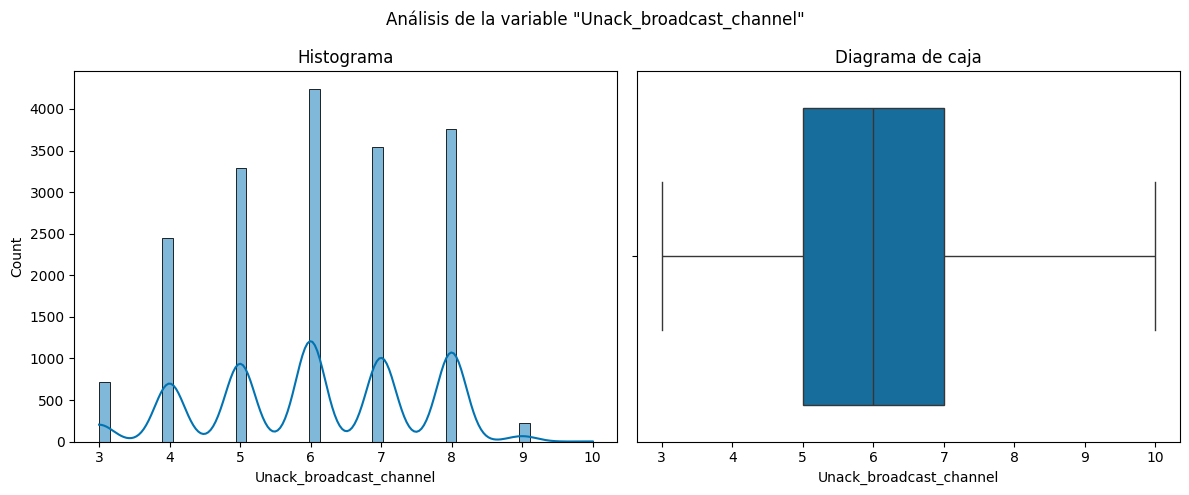

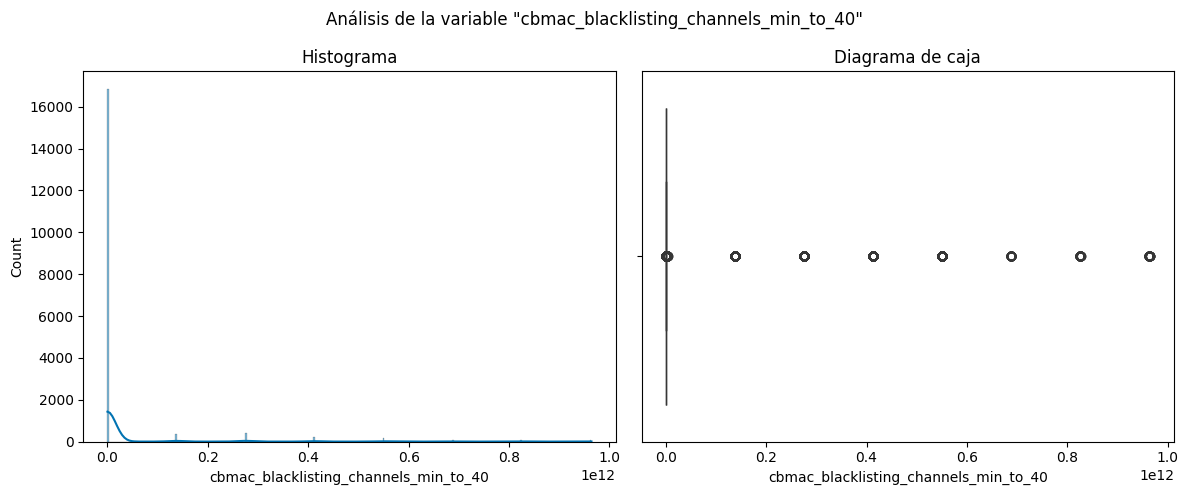

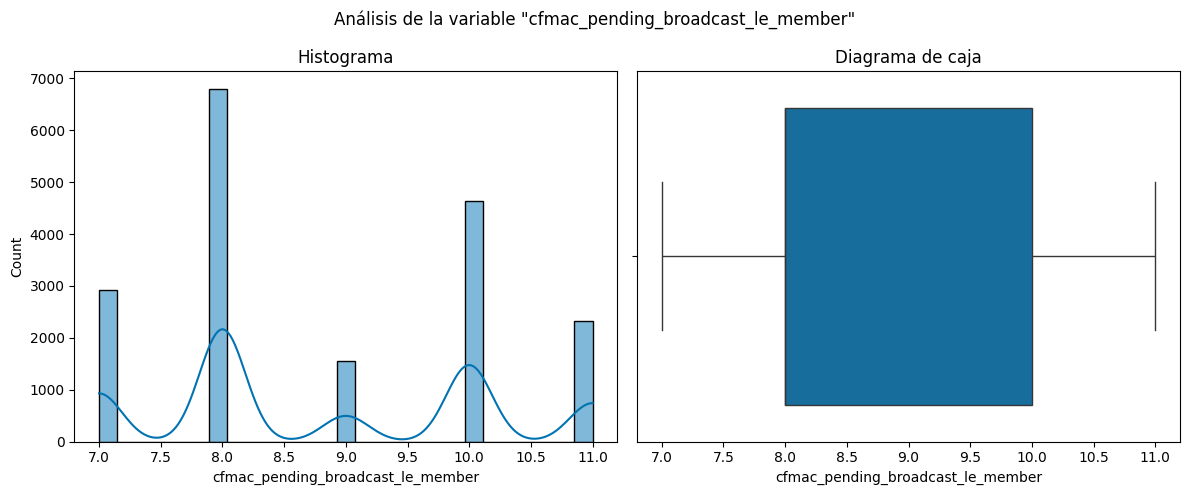

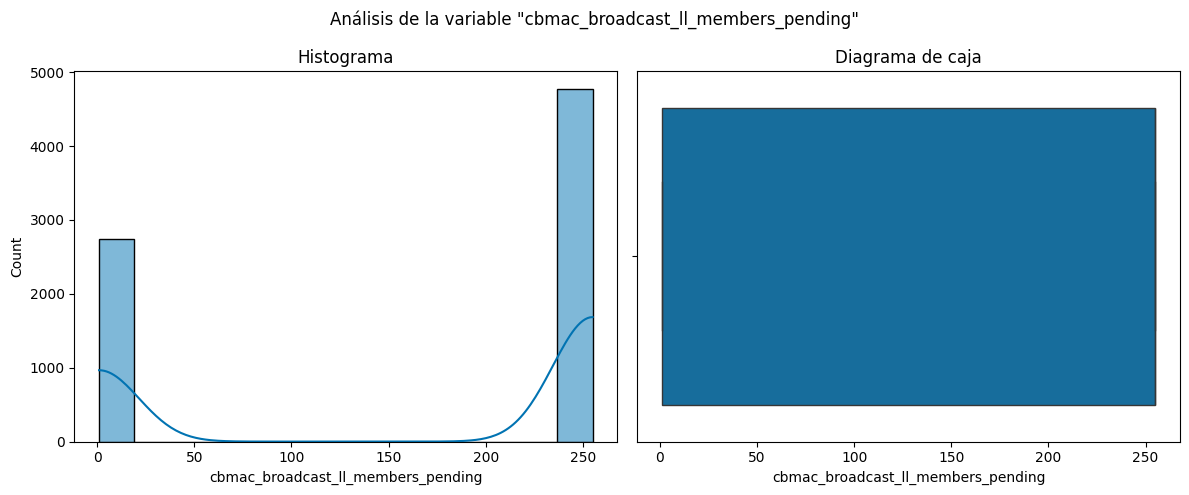

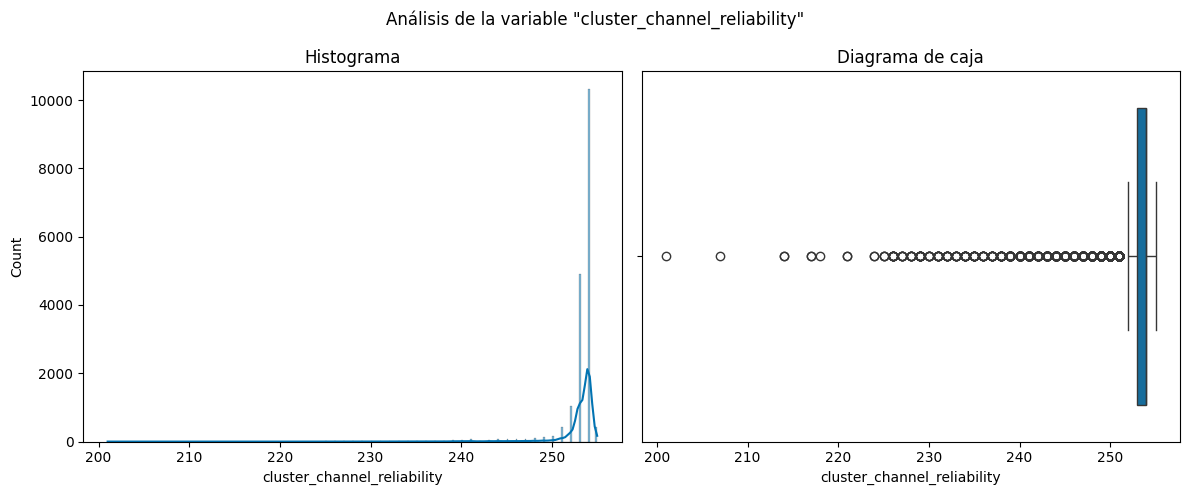

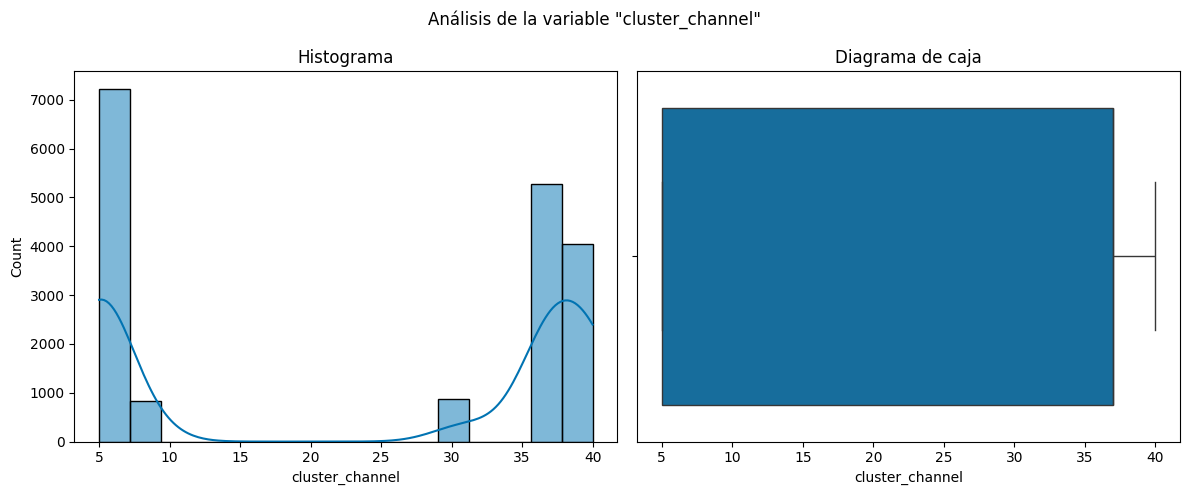

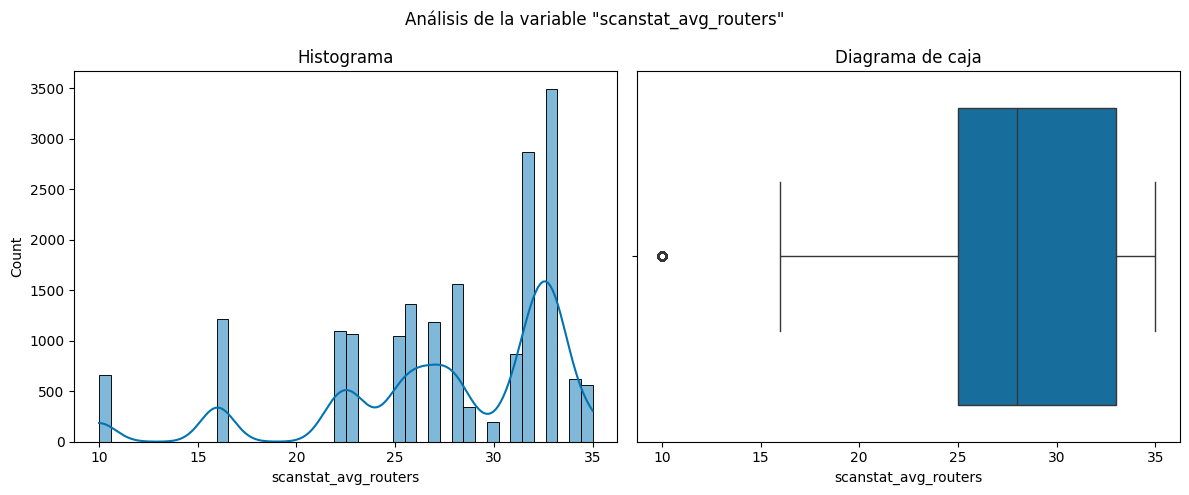

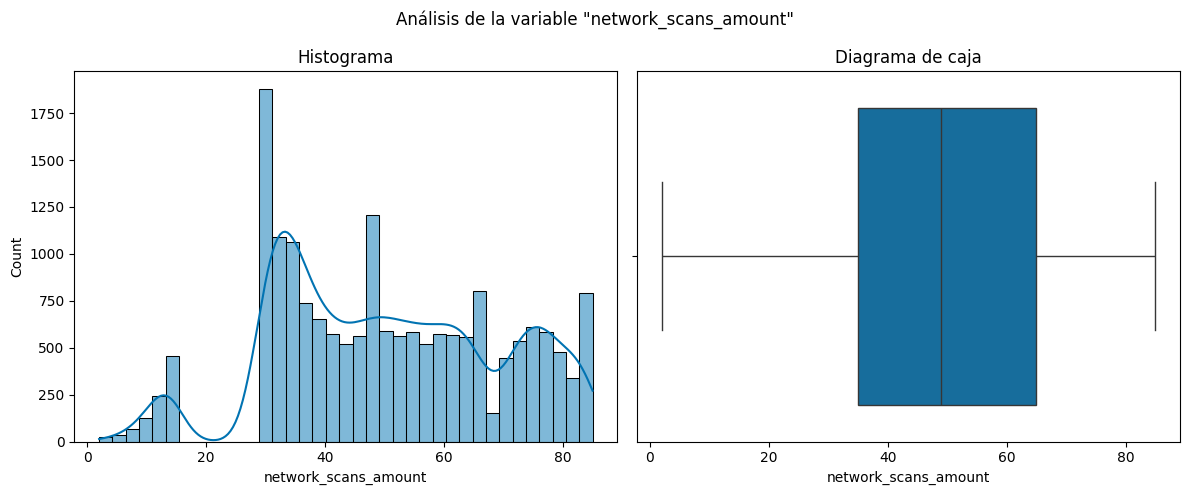

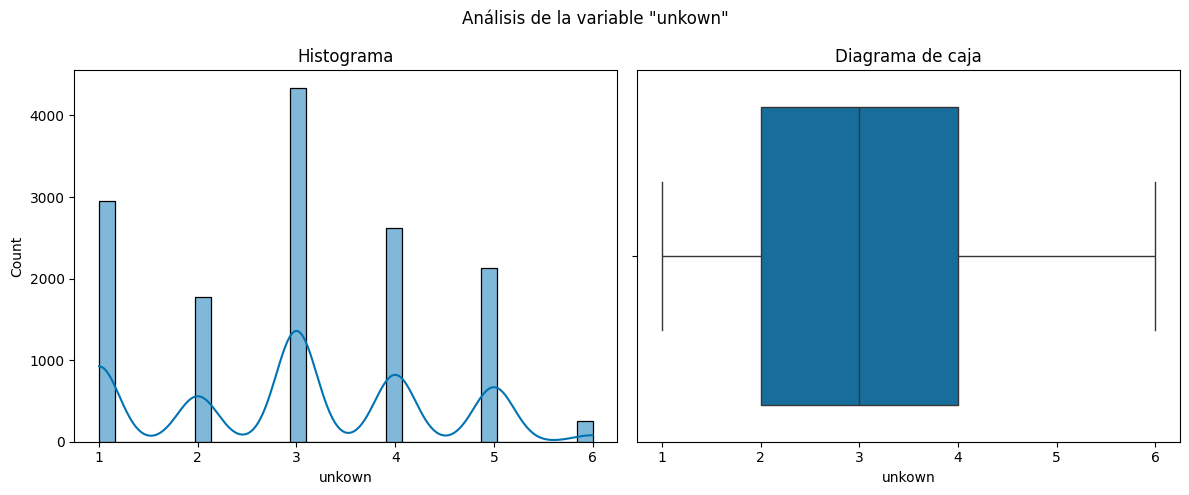

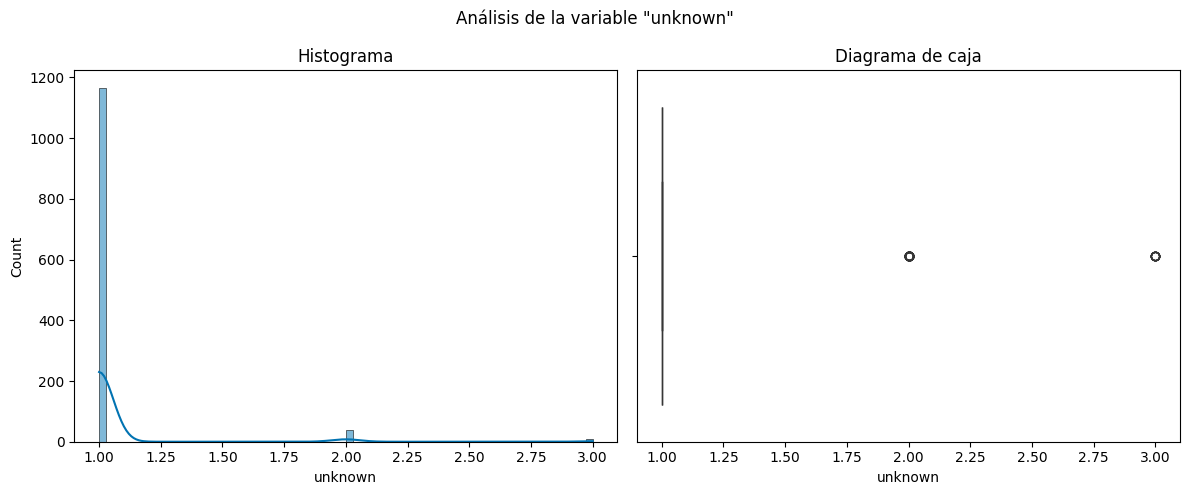

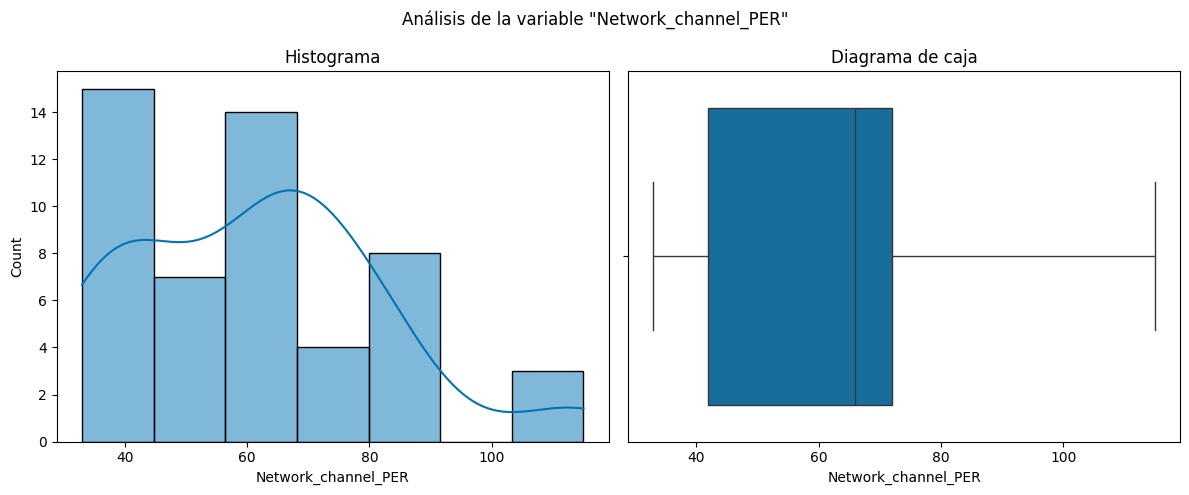

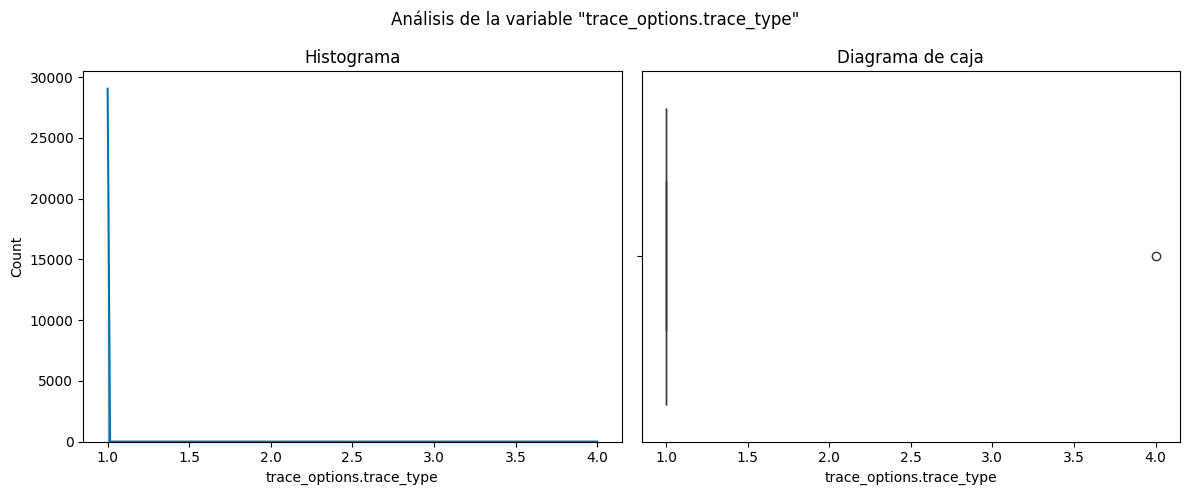

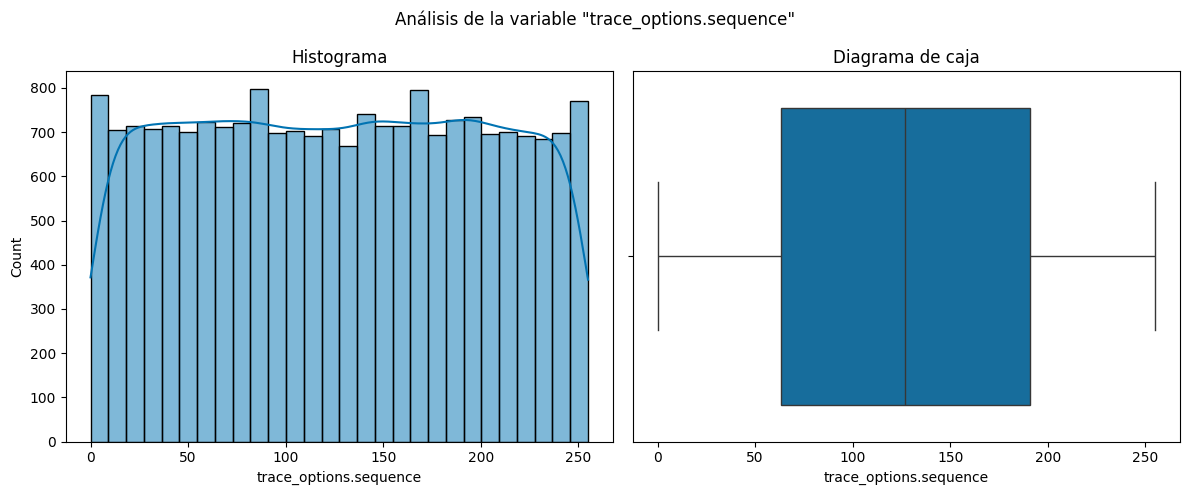

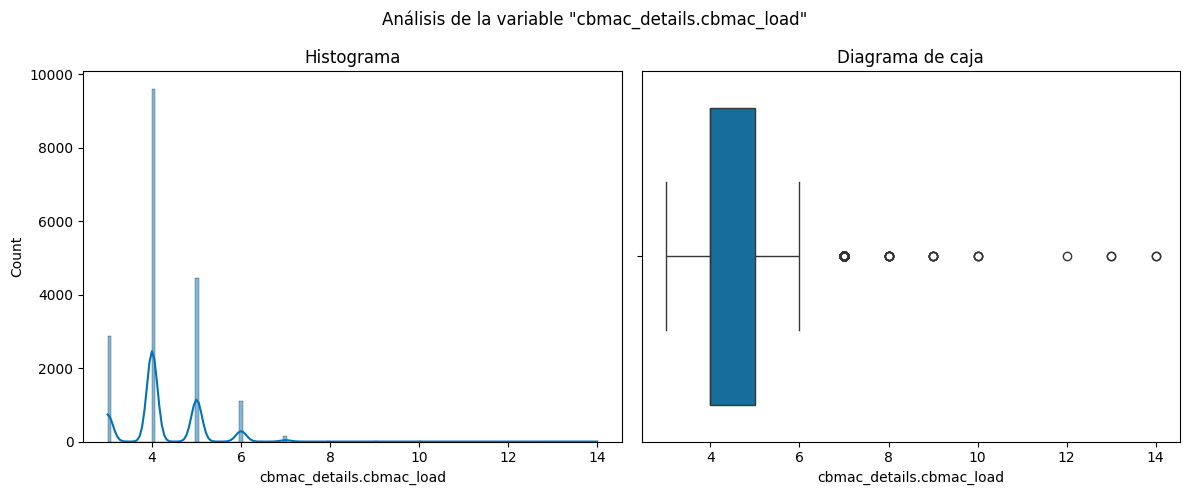

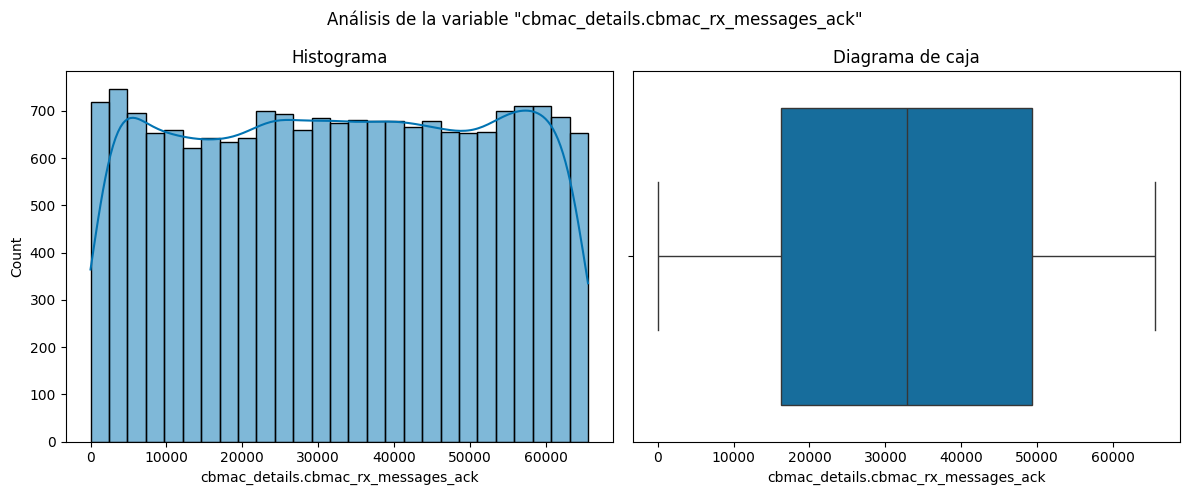

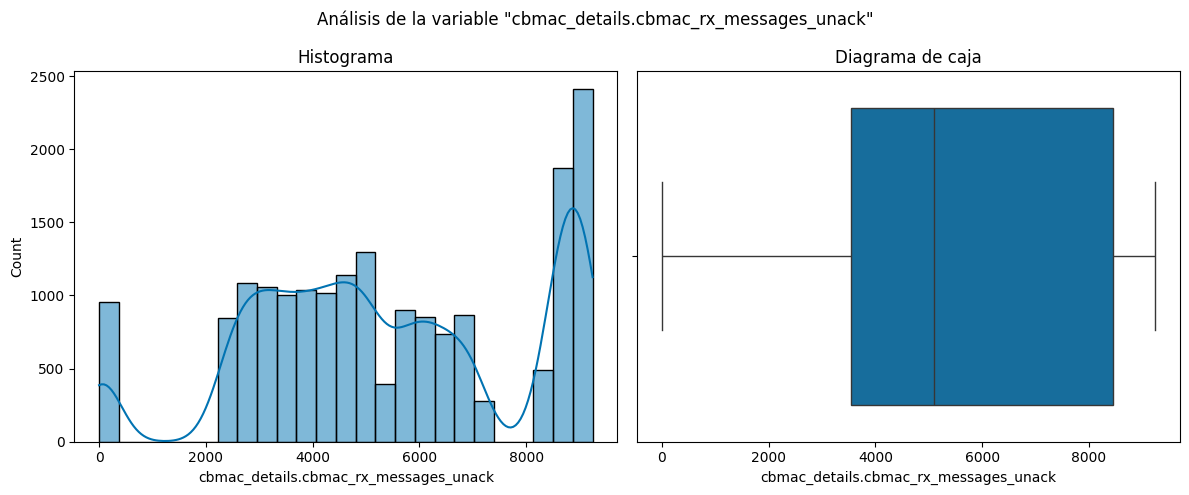

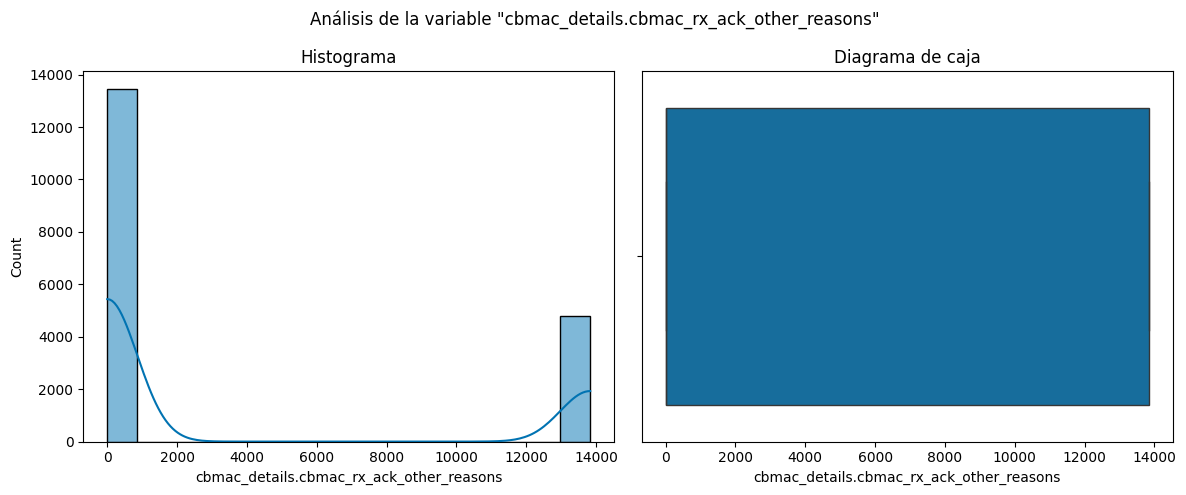

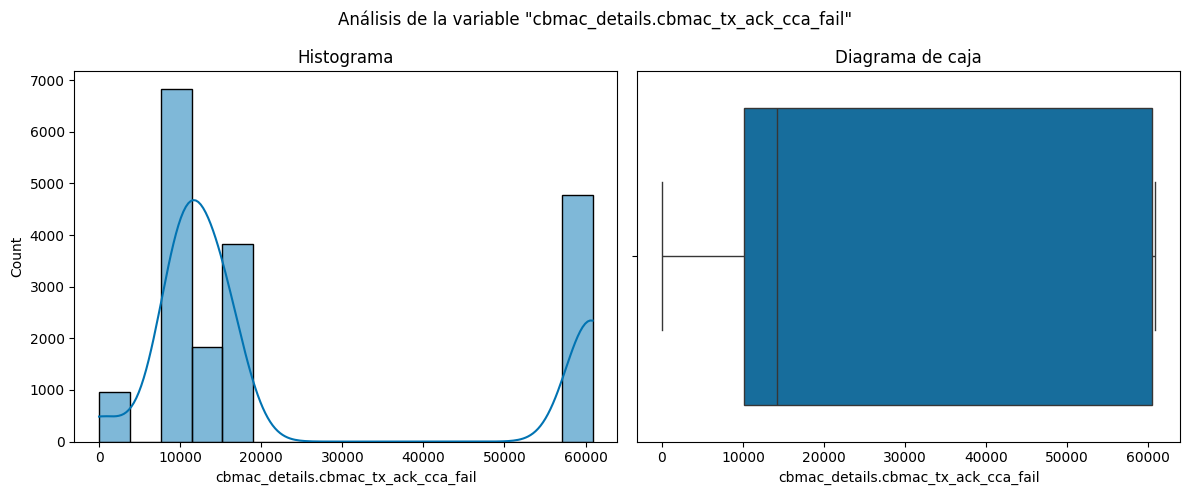

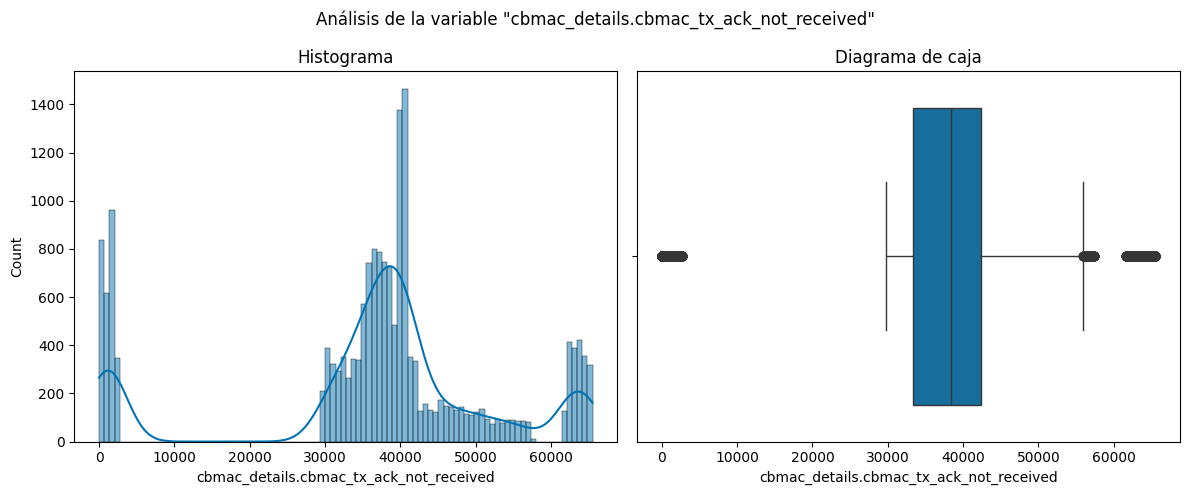

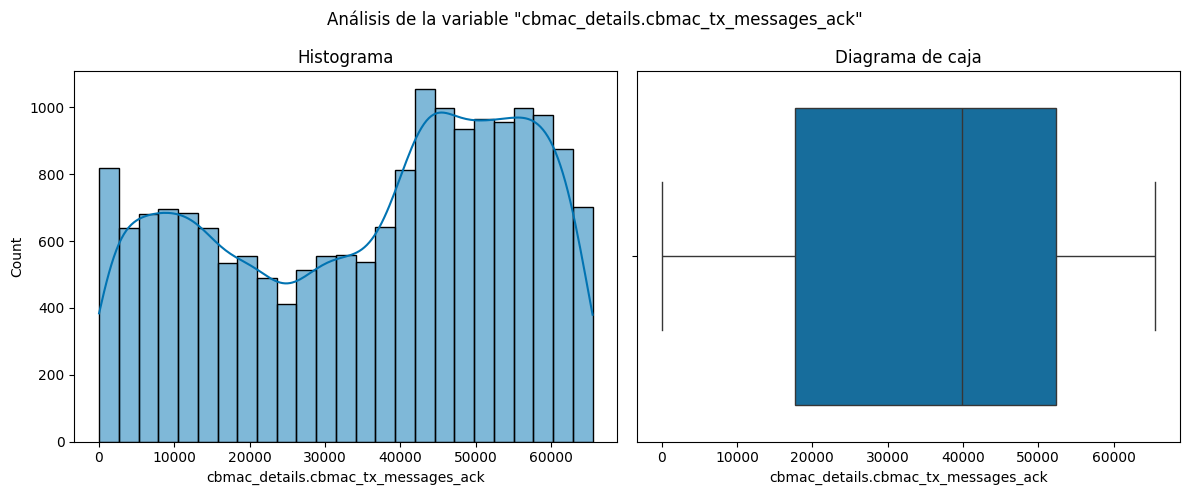

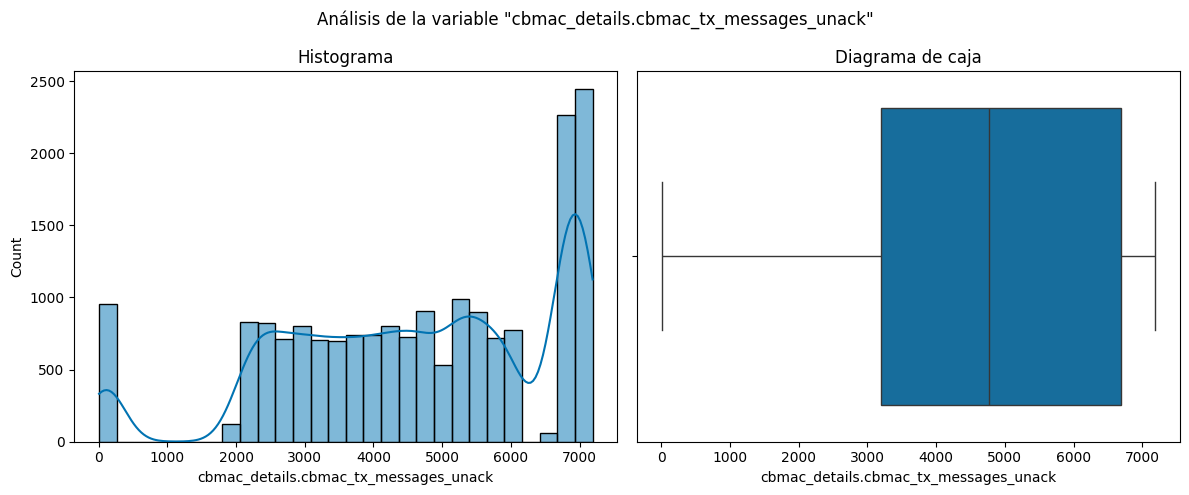

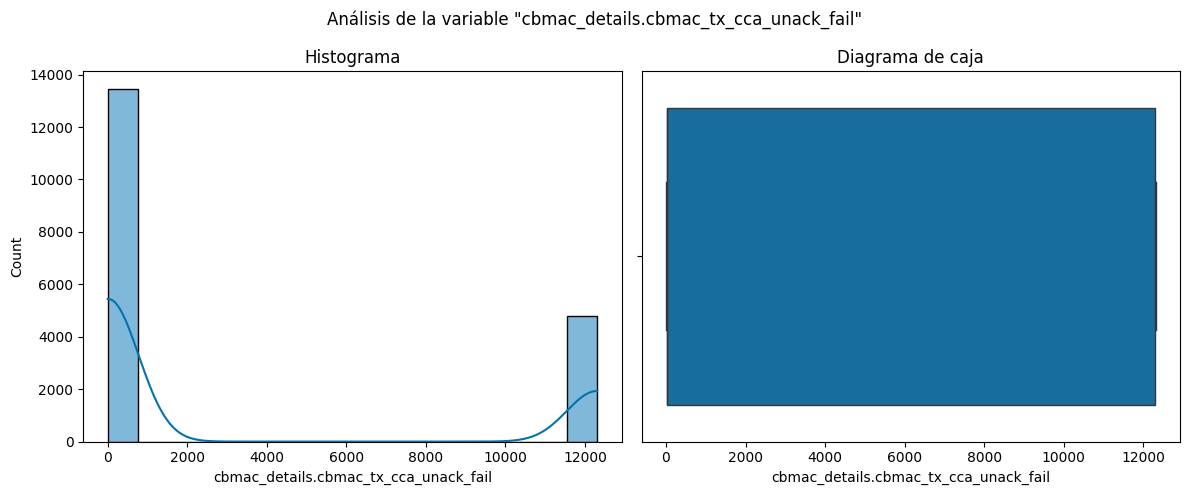

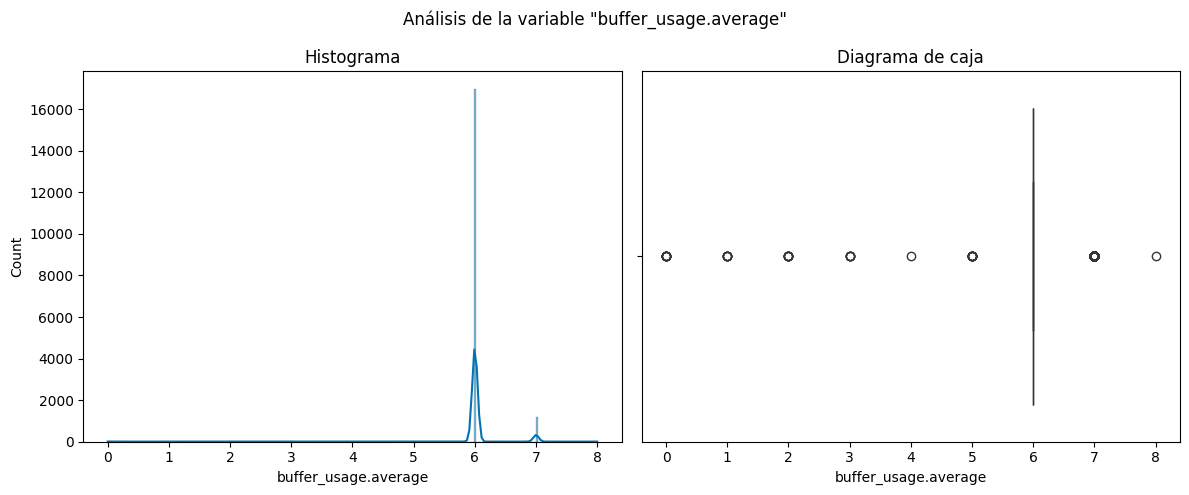

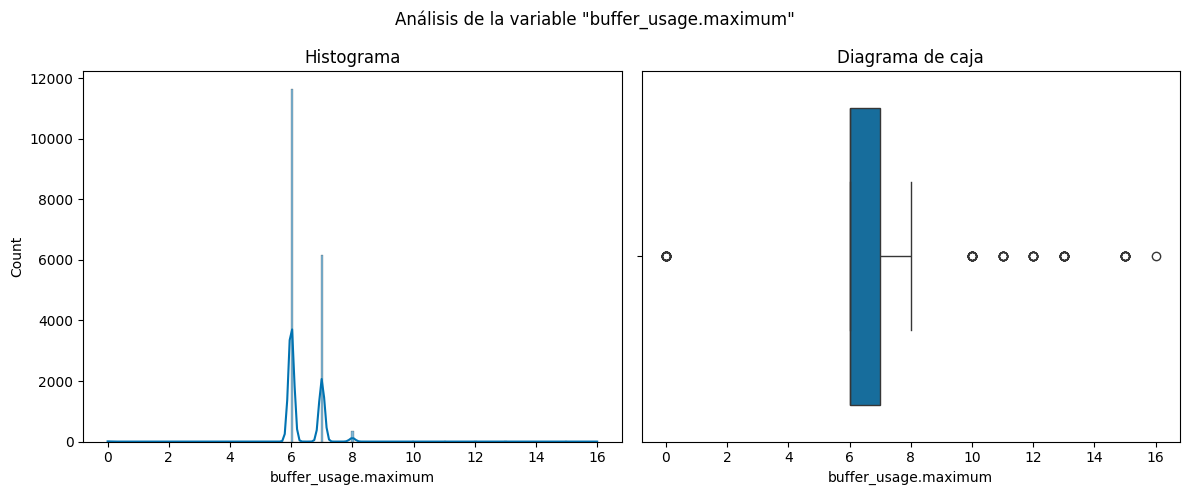

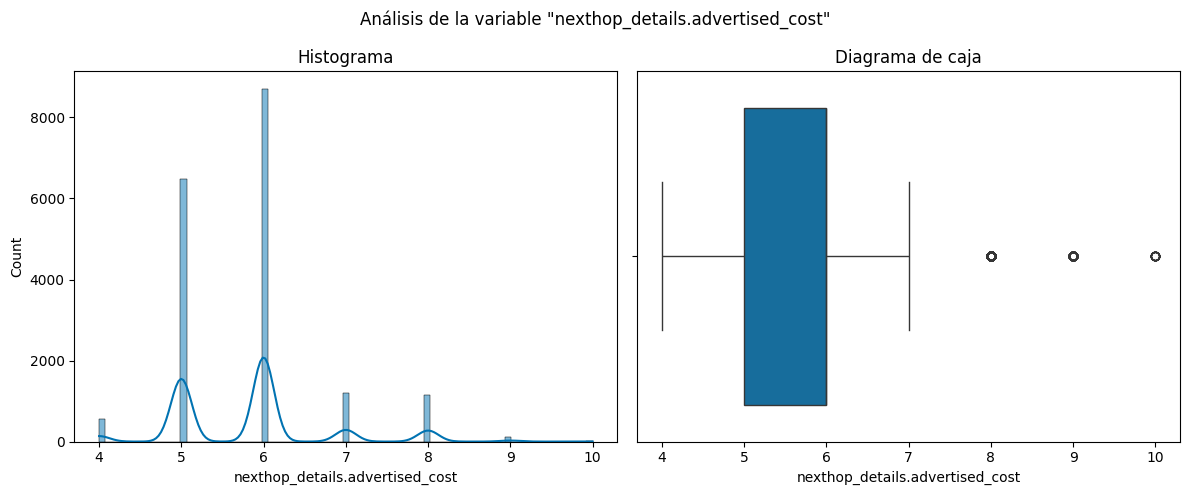

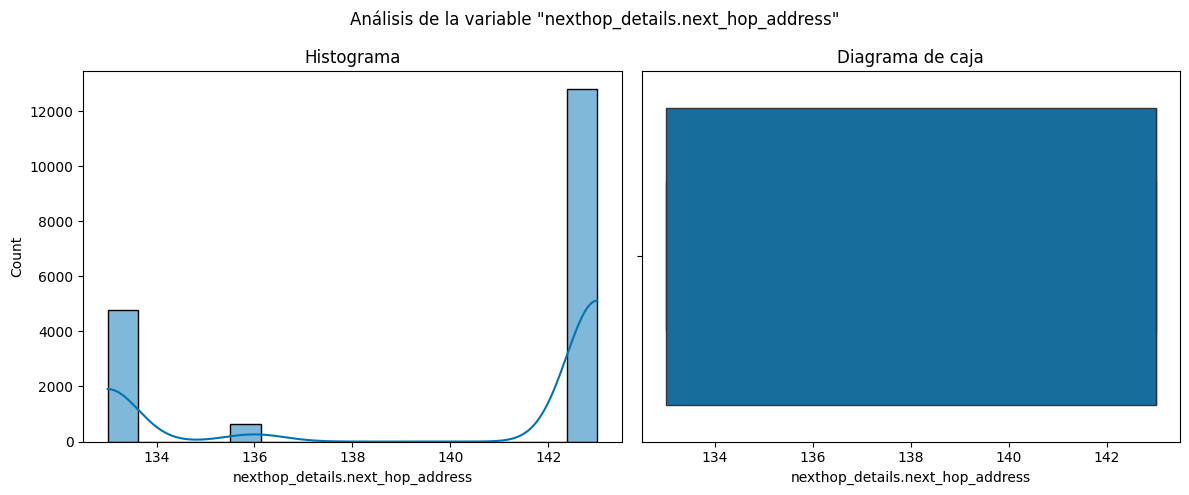

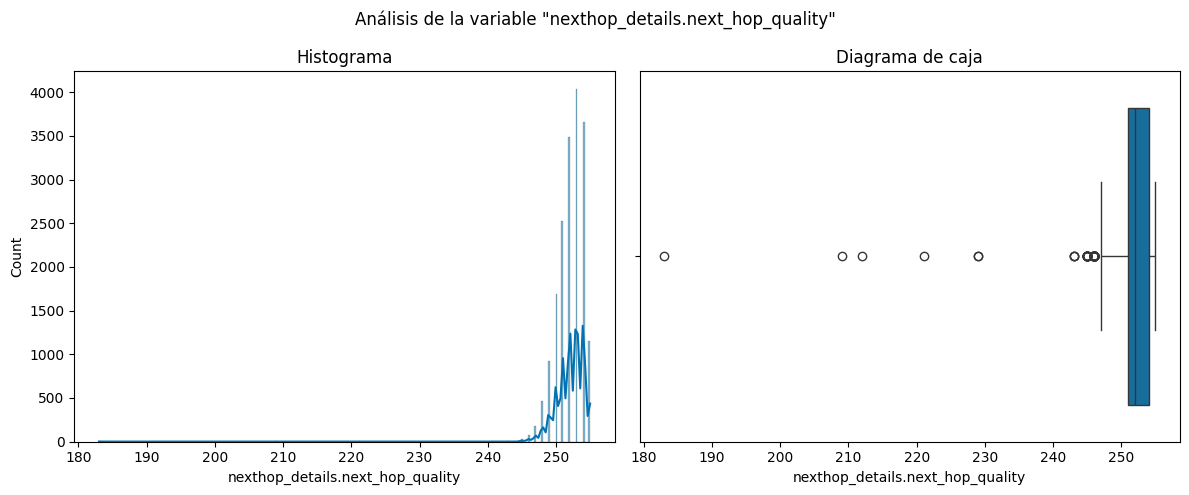

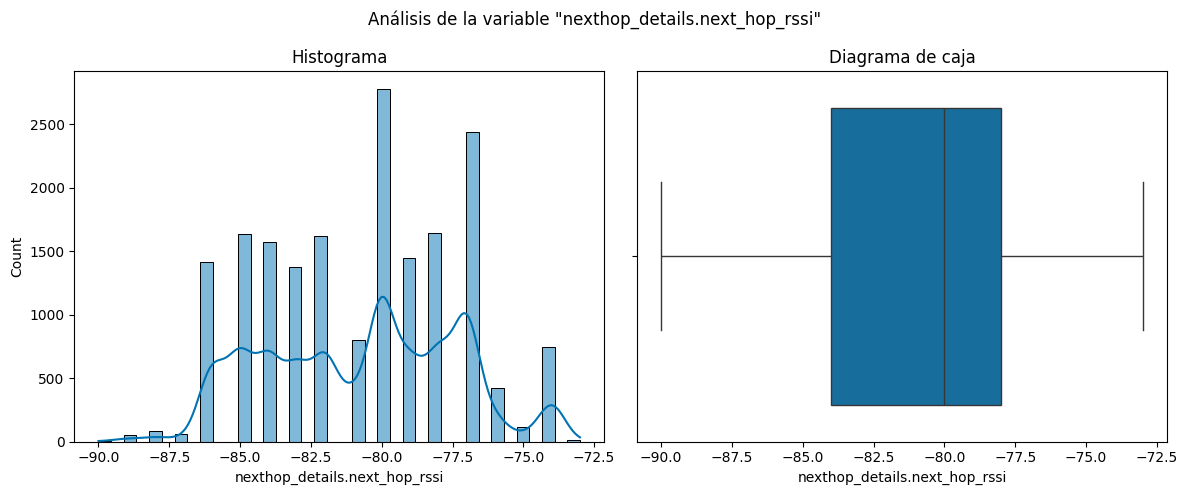

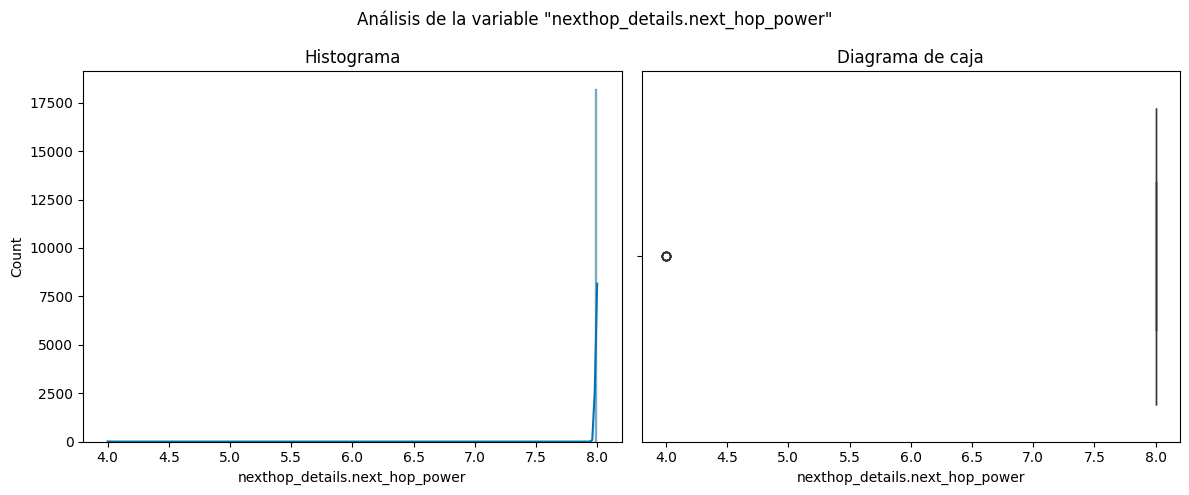

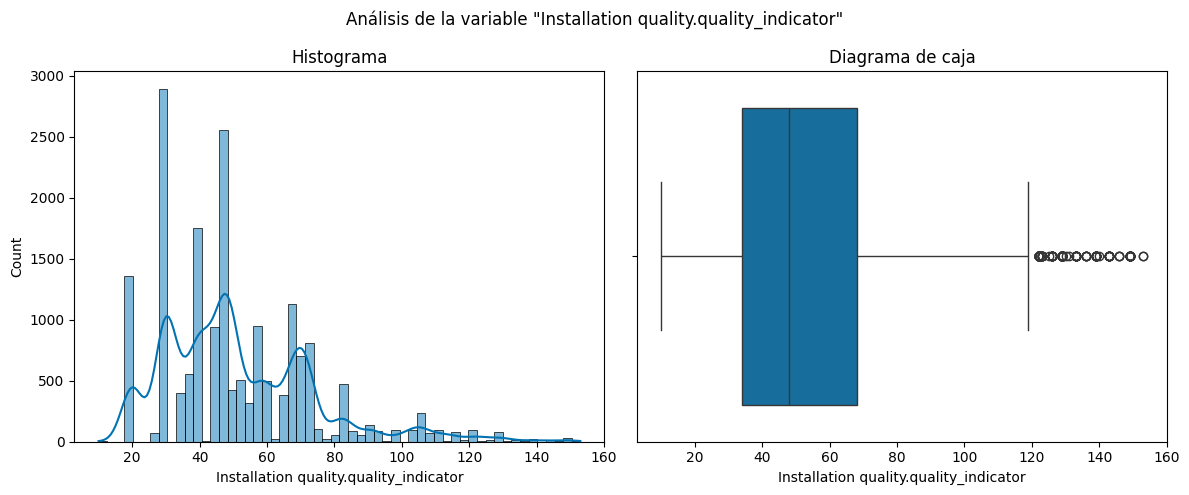

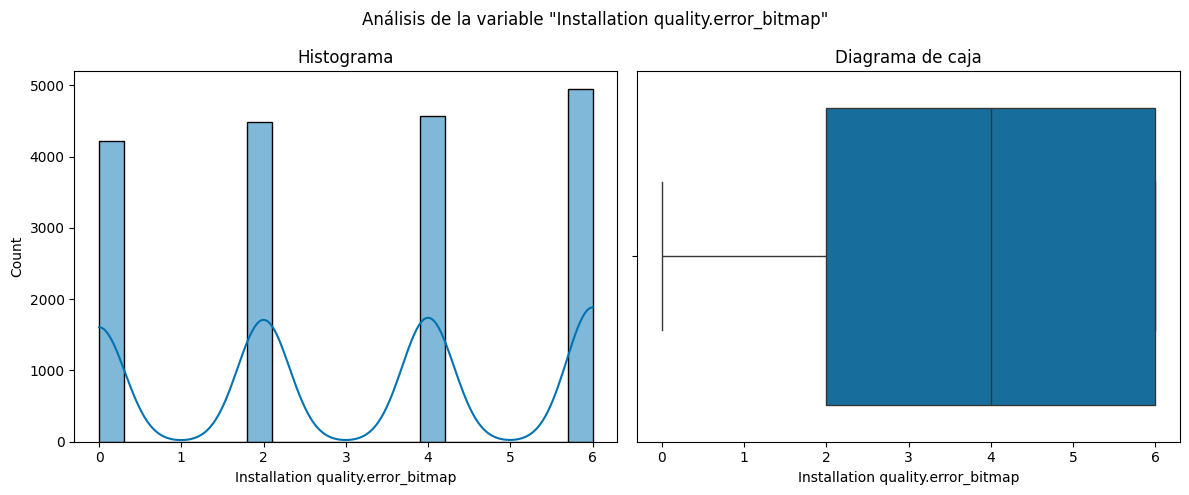

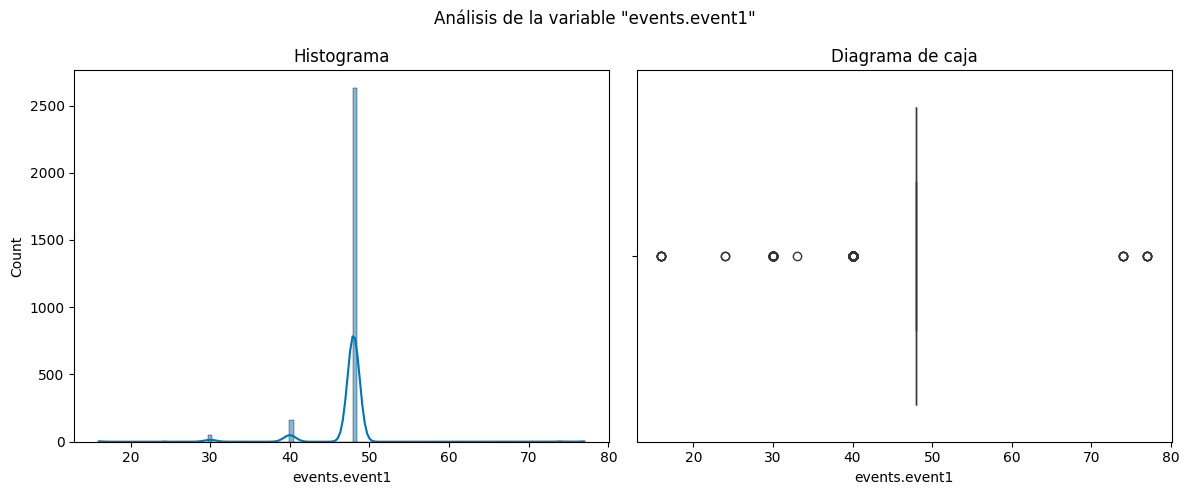

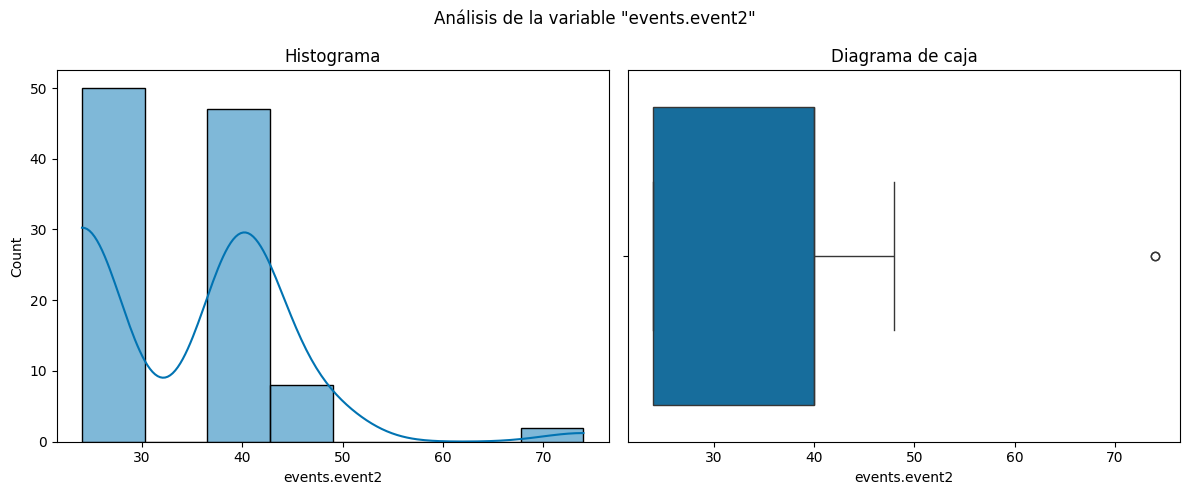

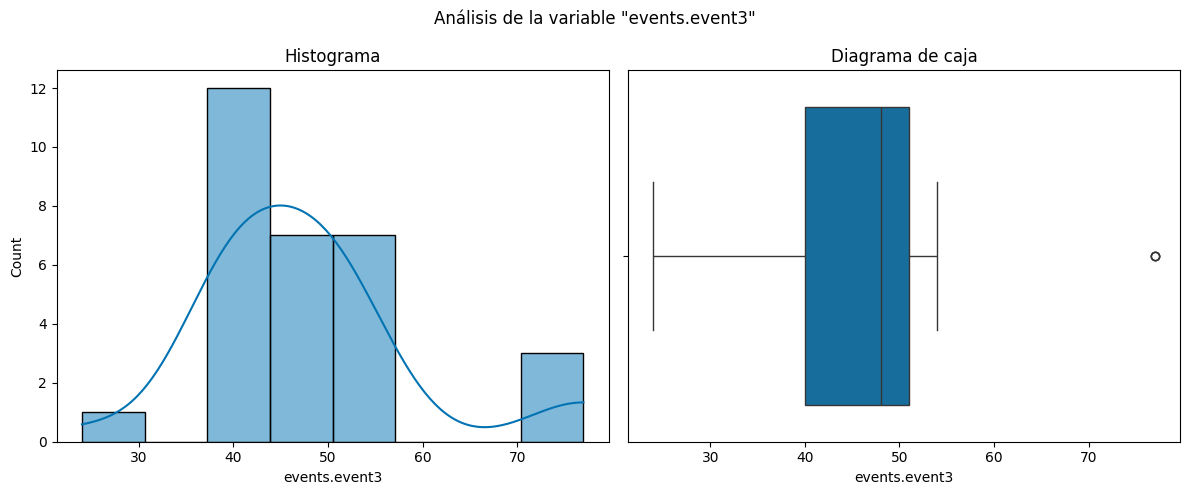

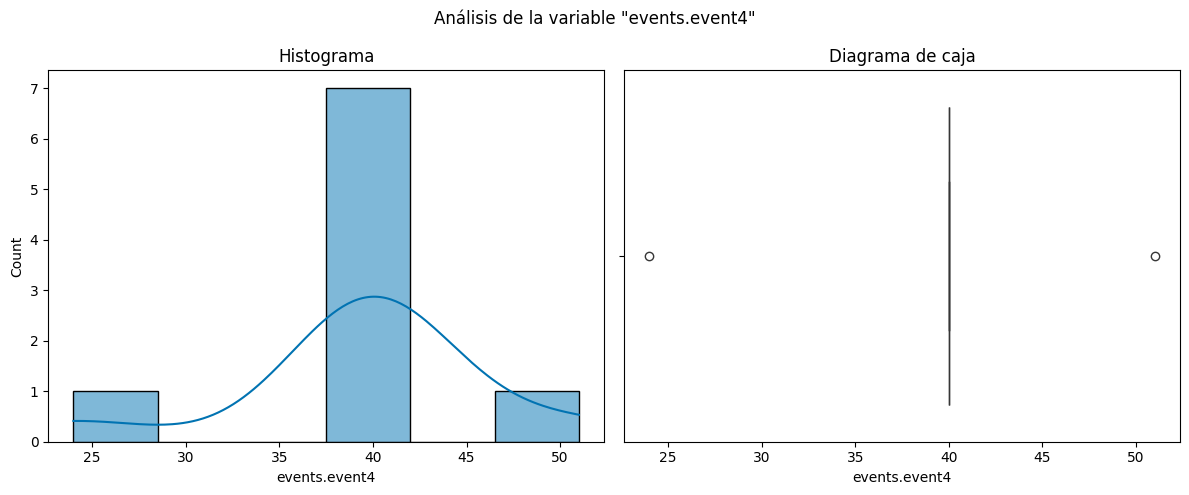

Columnas omitidas y razones:
- src: columna constante
- src_ep: columna constante
- inputState: columna constante
- two_in_one_battery_level: columna constante
- configuration: columna constante
- last_hw_test_result: columna constante
- last_sw_test_result: columna constante
- pictogram: columna constante
- brightness: columna constante
- configured: columna constante
- sensors: columna constante
- device_type: columna constante
- code: columna constante
- error_code: columna constante
- model: columna constante
- battery_type: columna constante
- app_firmware_major: columna constante
- app_firmware_minor: columna constante
- app_firmware_maintenaince: columna constante
- app_firmware_devel: columna constante
- app_stack_major: columna constante
- app_stack_minor: columna constante
- app_stack_maintenaince: columna constante
- app_stack_devel: columna constante
- app_TFT_major: columna constante
- app_TFT_minor: columna constante
- app_TFT_maintenaince: columna constante
- functionali

In [14]:
X_src140 = X_train[X_train["src"] == 140]
skipped = {}
for column in numerical_features:
    try:
        # Extraer la columna
        x = X_src140[column]

        # Comprobar que queda más de 1 valor
        if len(x) < 2:
            skipped[column] = "menos de 2 valores"
            continue

        # Evitar columnas constantes (boxplot rompe si no varían)
        if x.nunique() < 2:
            skipped[column] = "columna constante"
            continue

        # Graficar
        plt.figure(figsize=(12,5))

        # Histograma
        plt.subplot(1, 2, 1)
        sns.histplot(x, kde=True)
        plt.title("Histograma")

        # Boxplot
        plt.subplot(1, 2, 2)
        sns.boxplot(x=x)
        plt.title("Diagrama de caja")

        plt.suptitle(f'Análisis de la variable \"{column}\"')
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"❌ Error en la columna '{column}': {e}")

print("Columnas omitidas y razones:")
for col, reason in skipped.items():
    print(f"- {col}: {reason}")

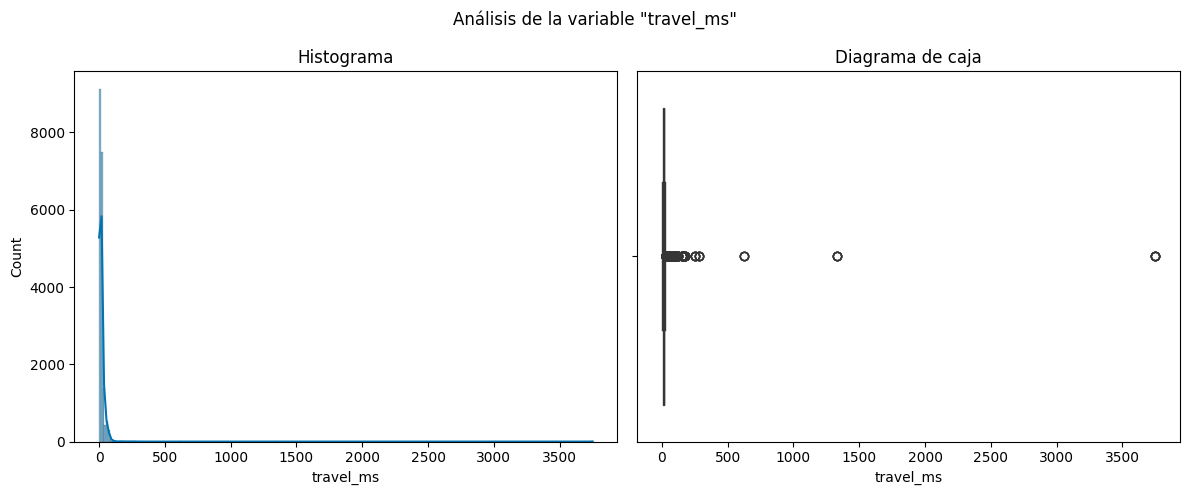

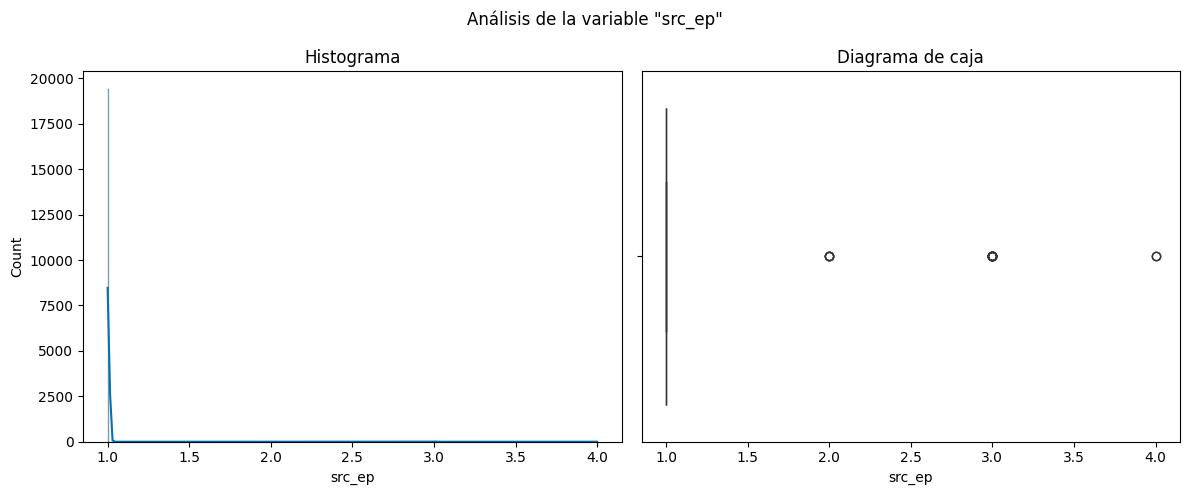

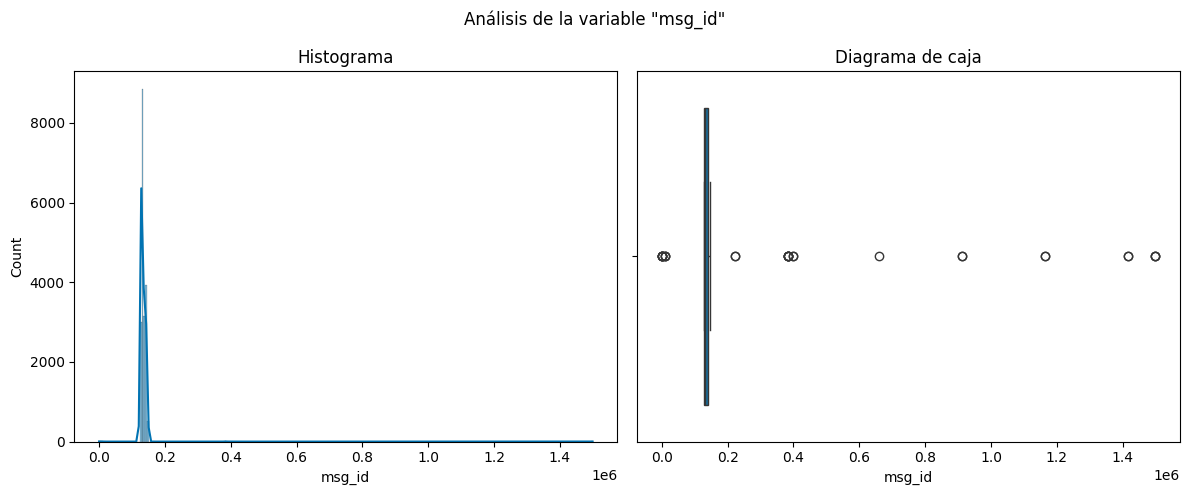

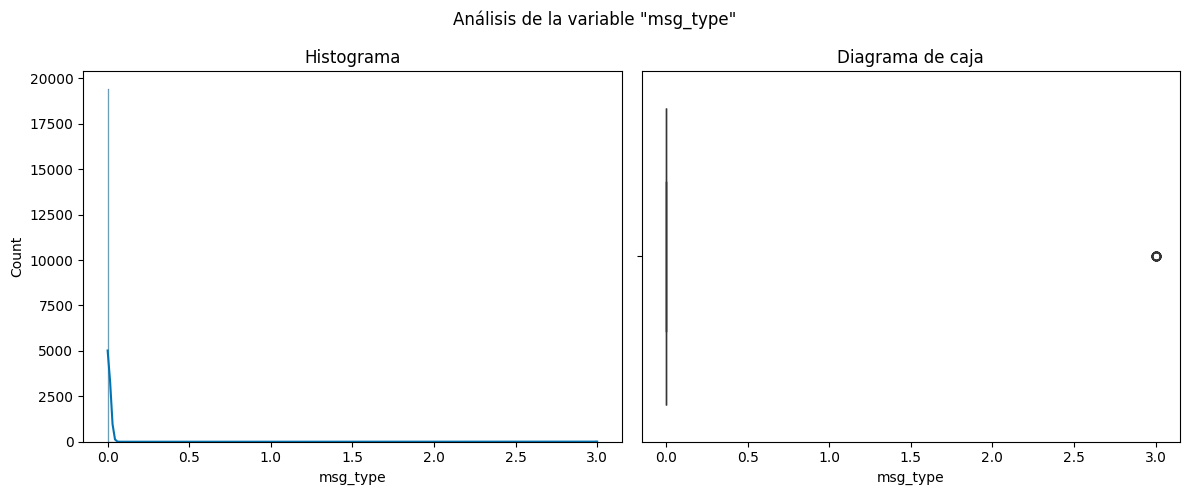

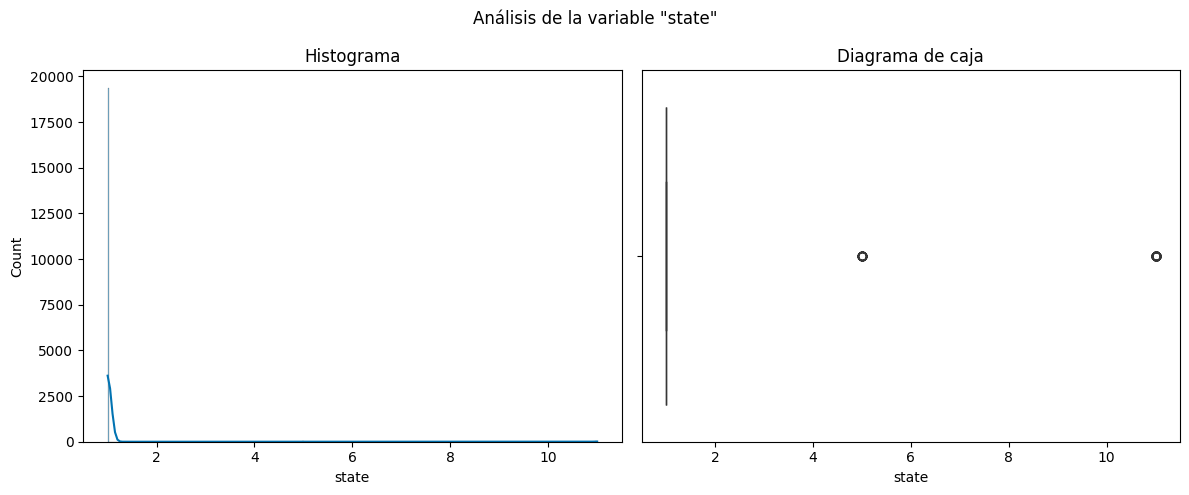

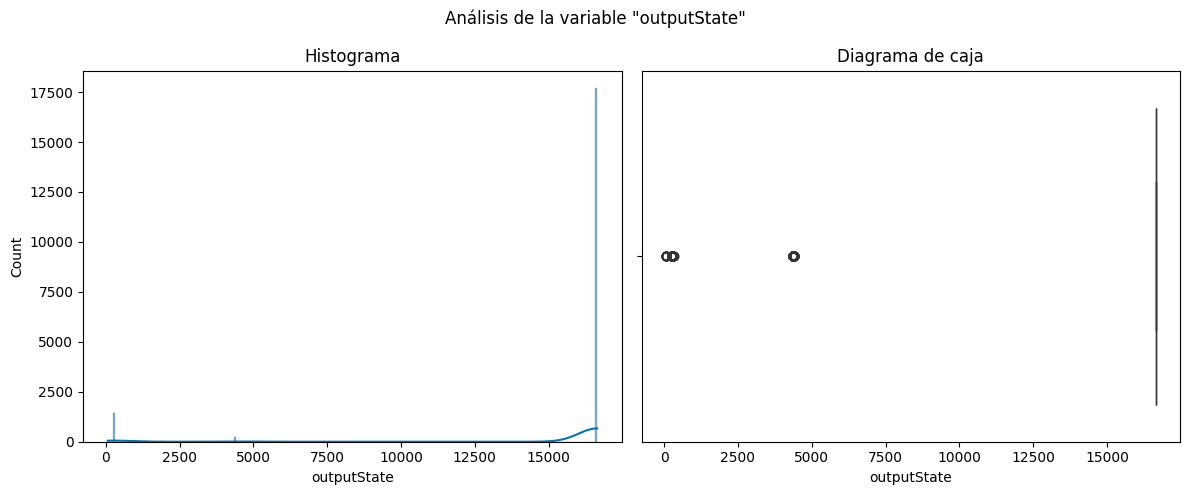

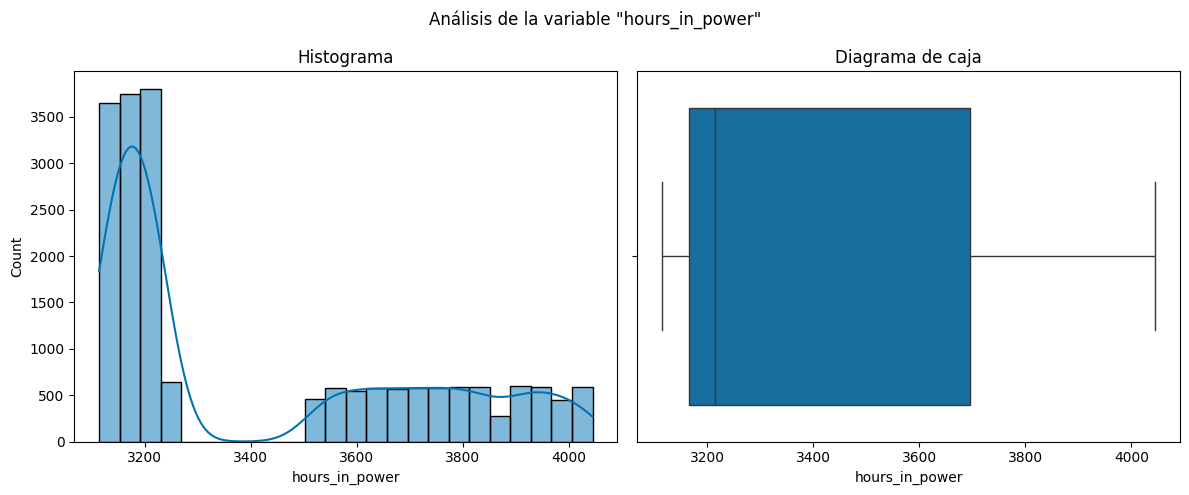

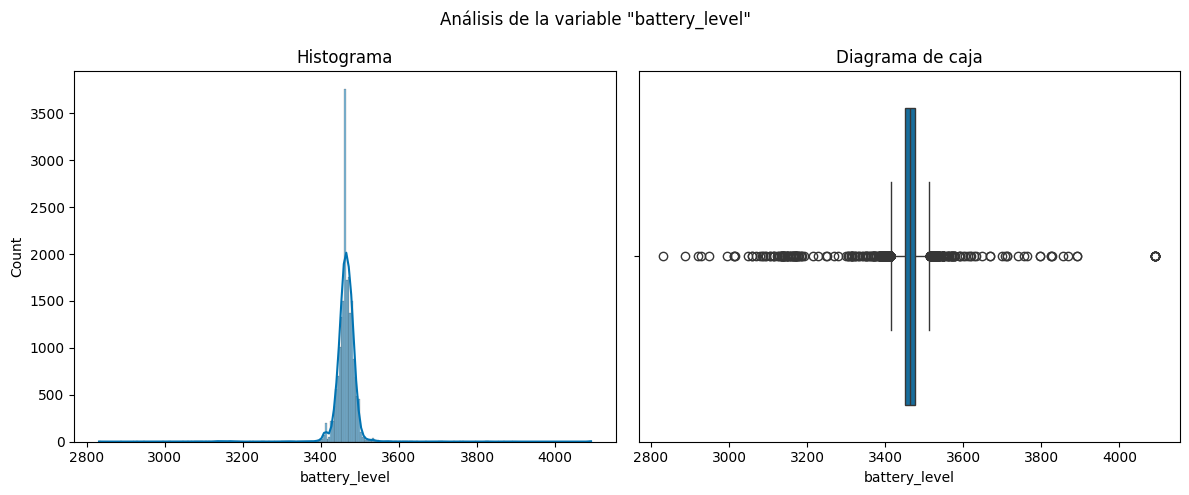

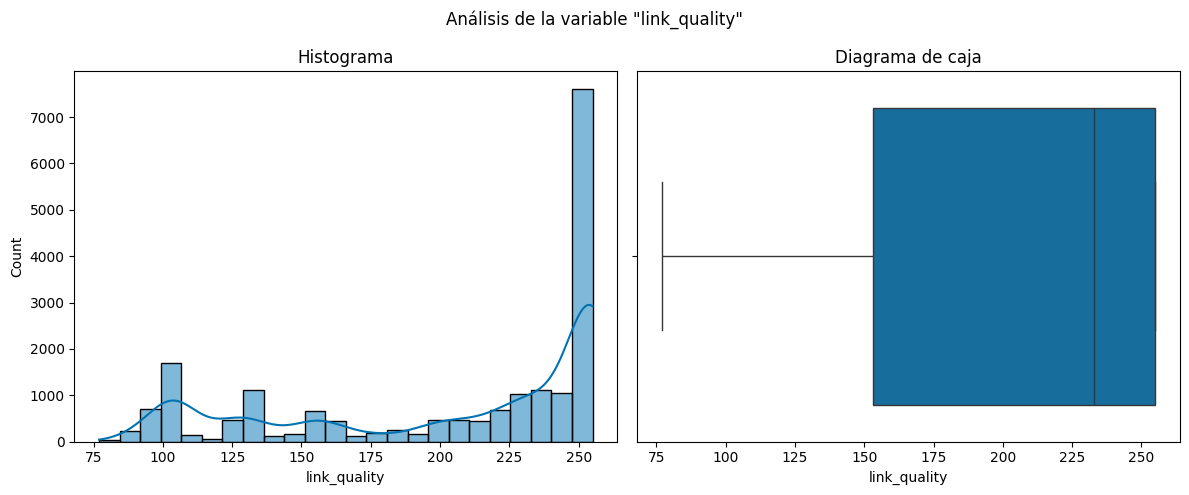

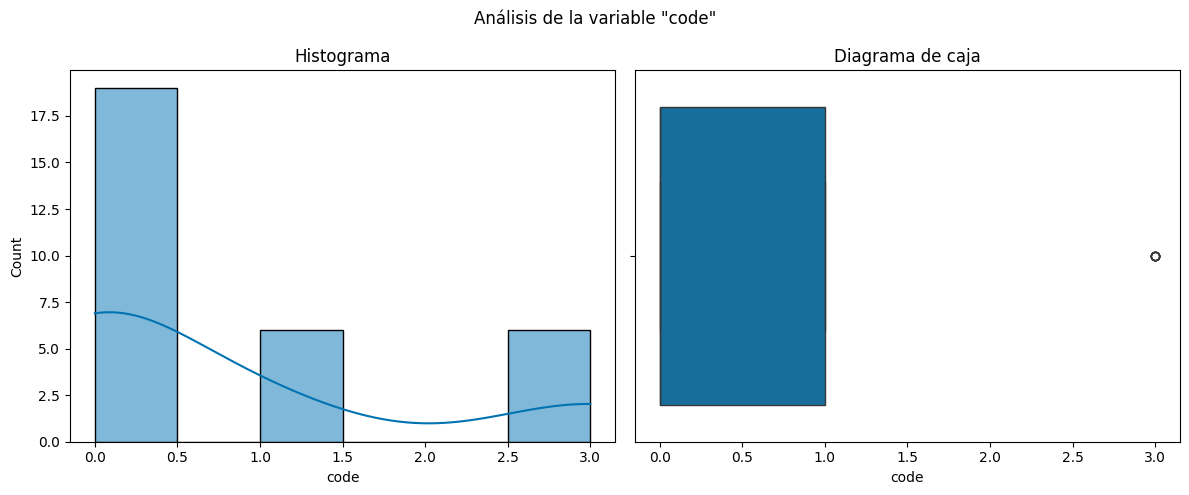

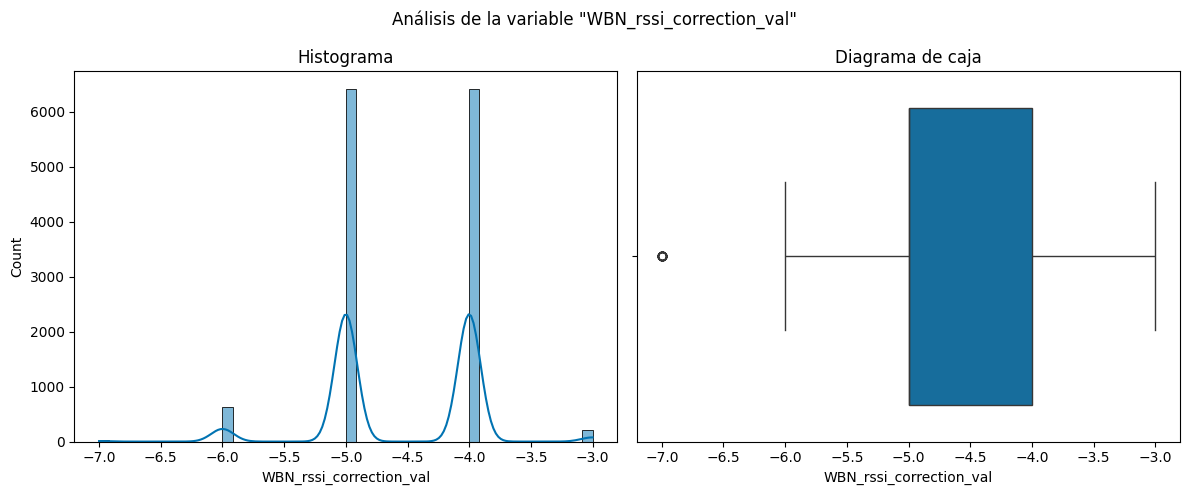

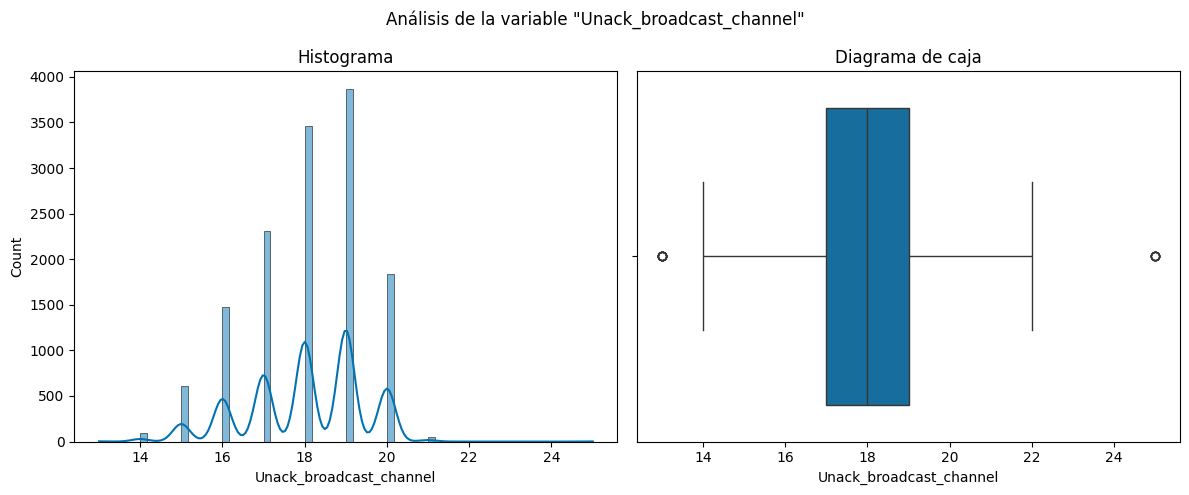

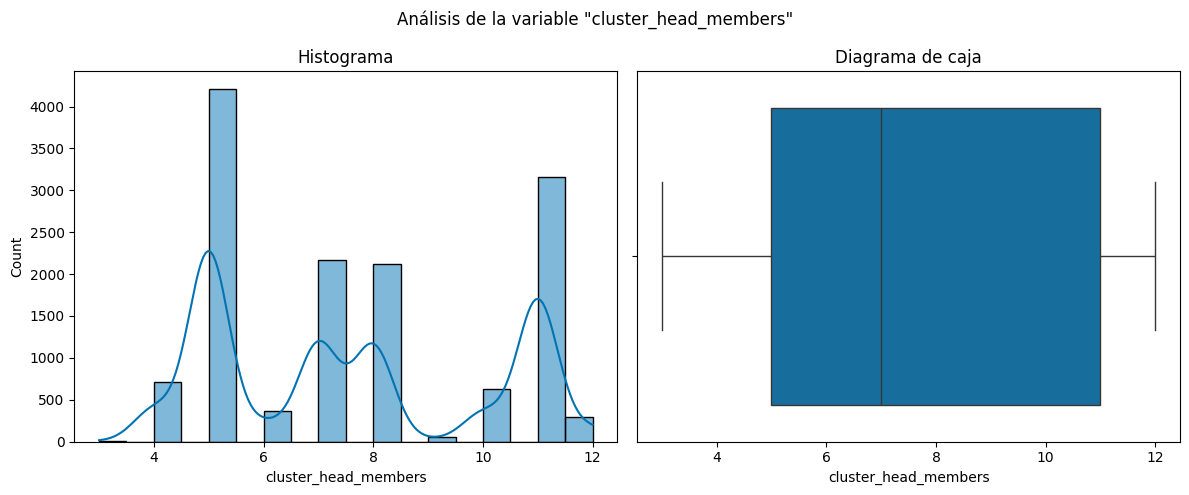

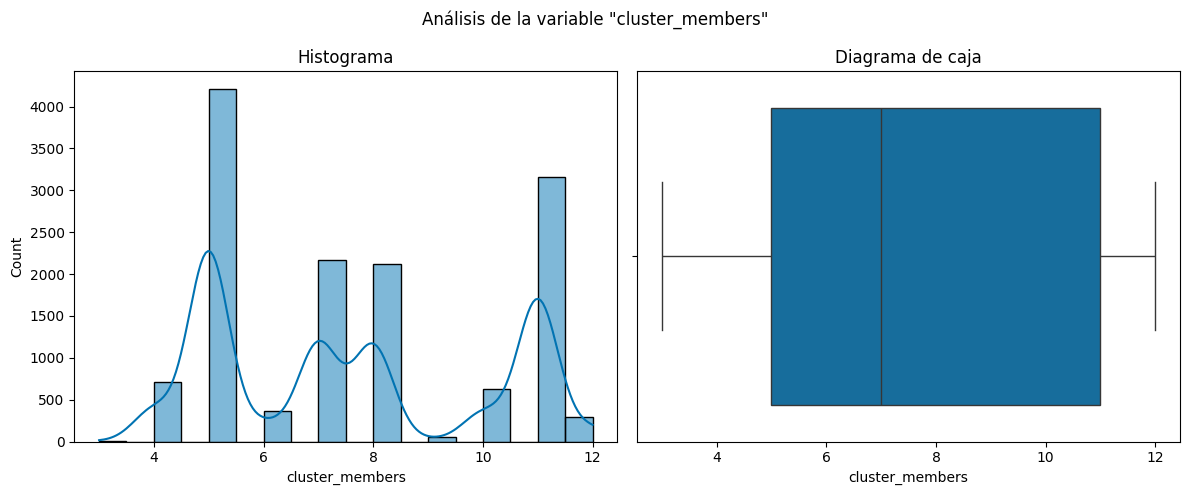

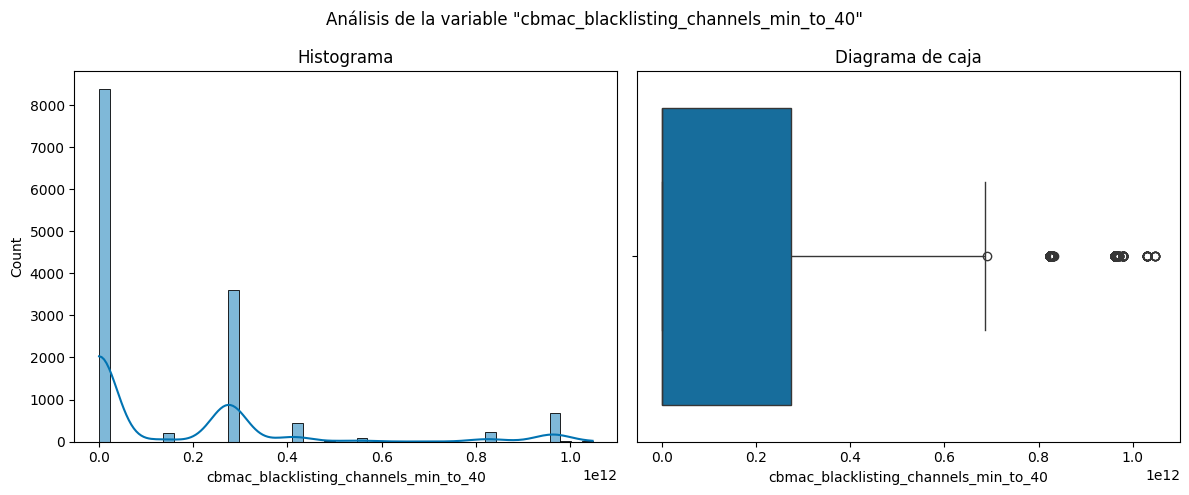

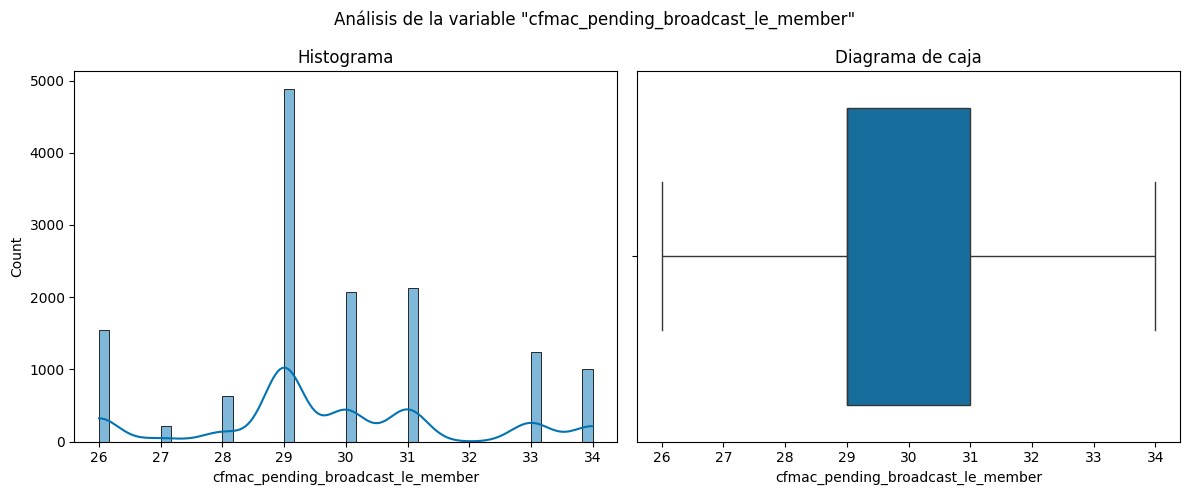

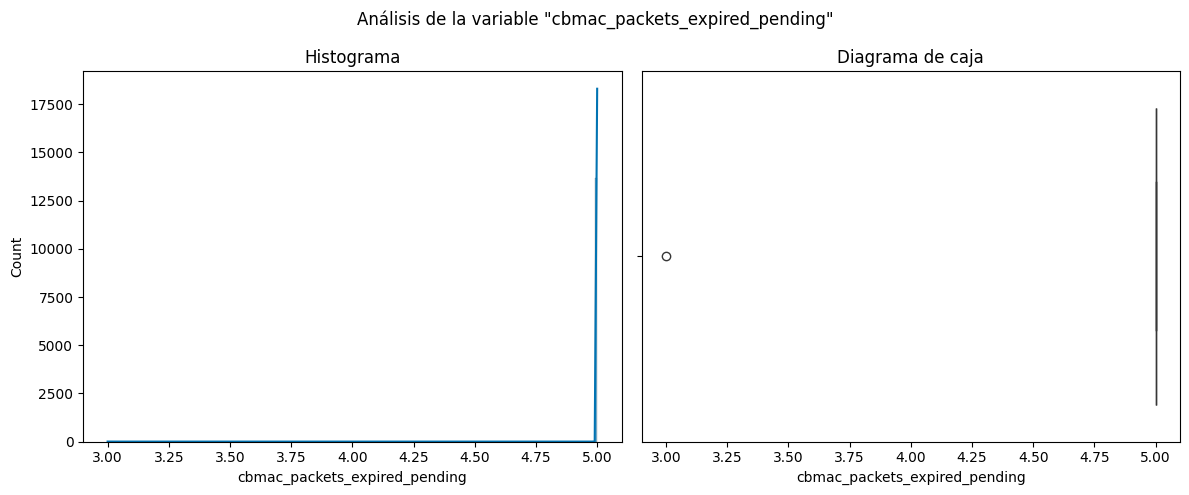

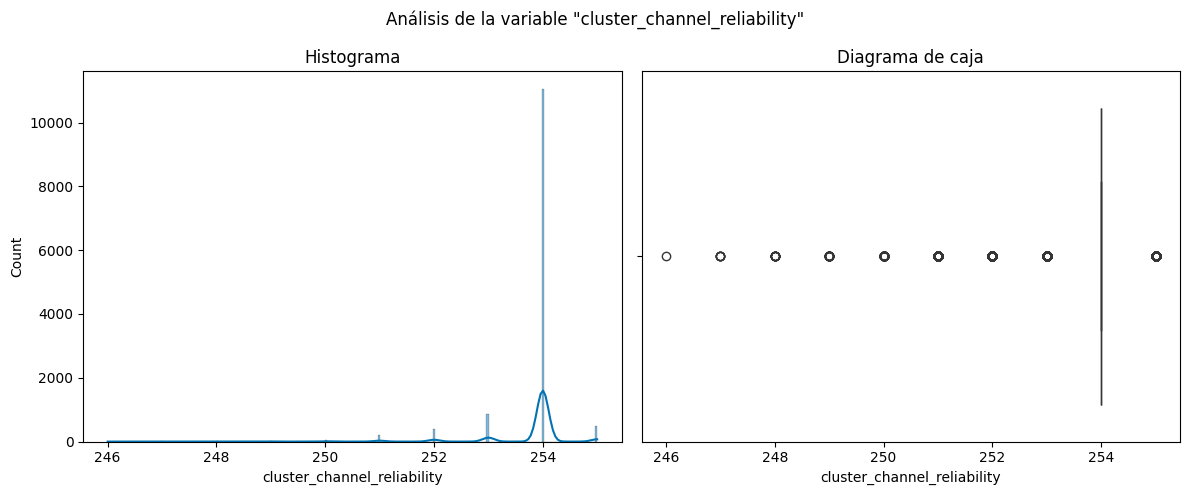

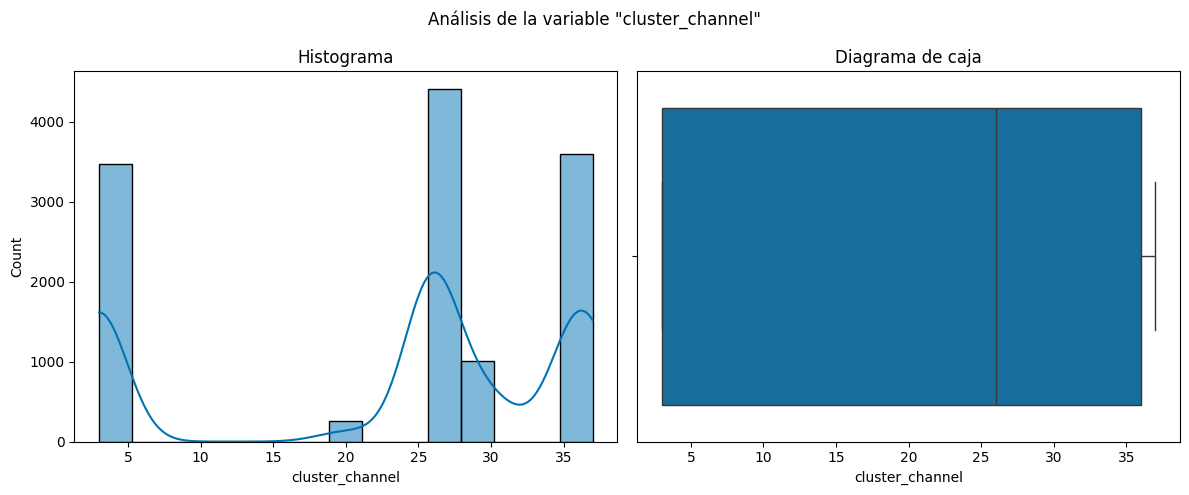

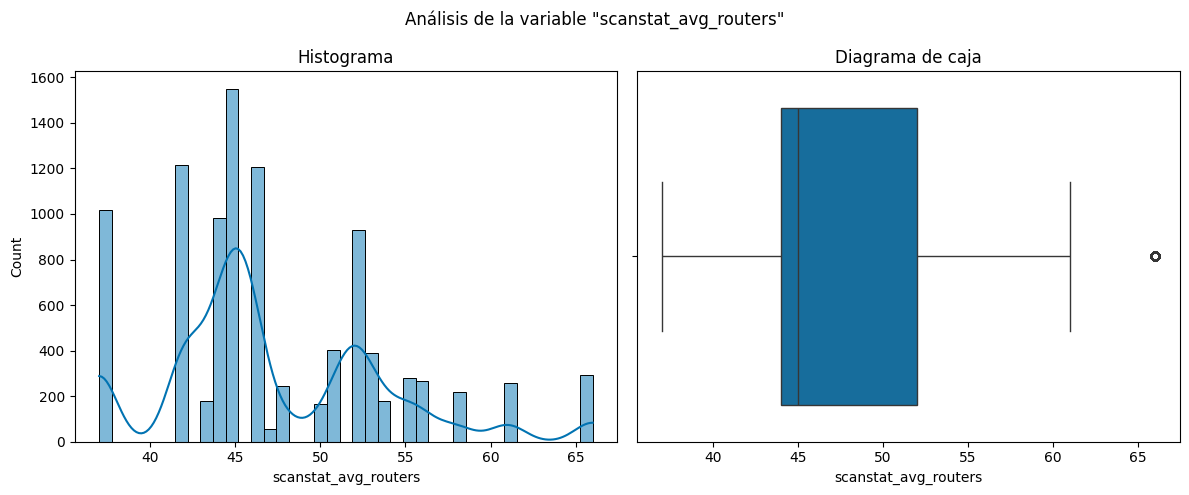

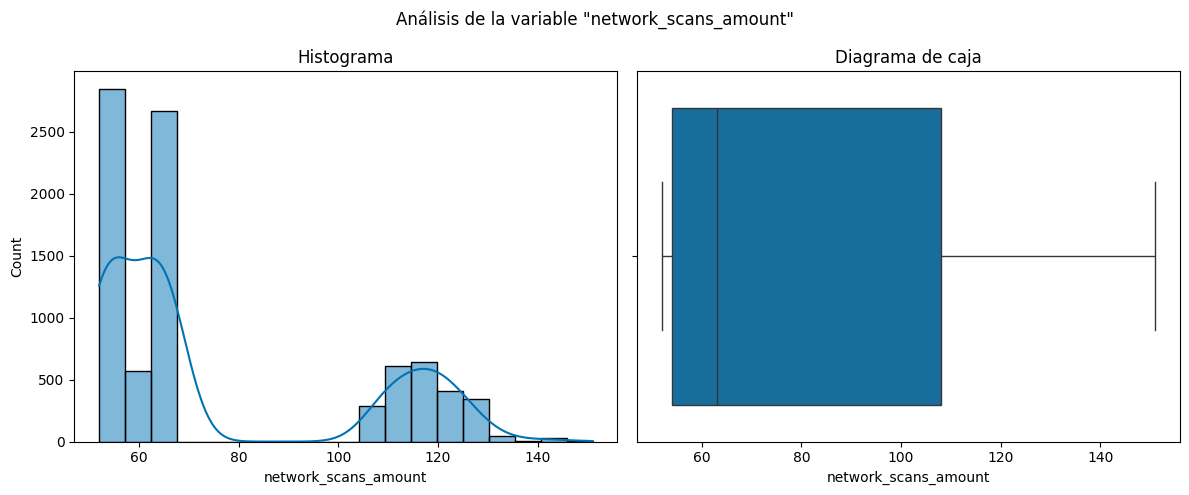

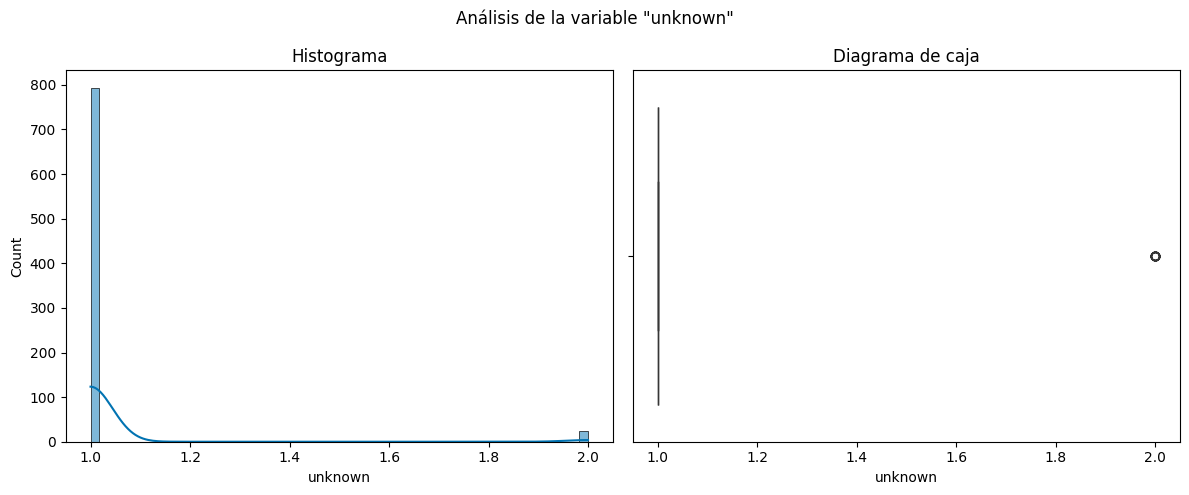

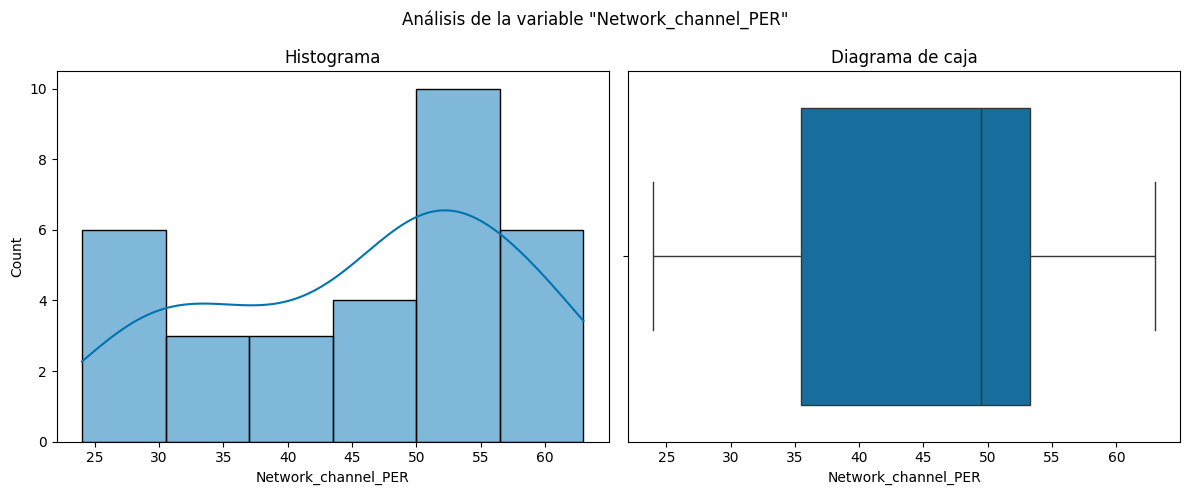

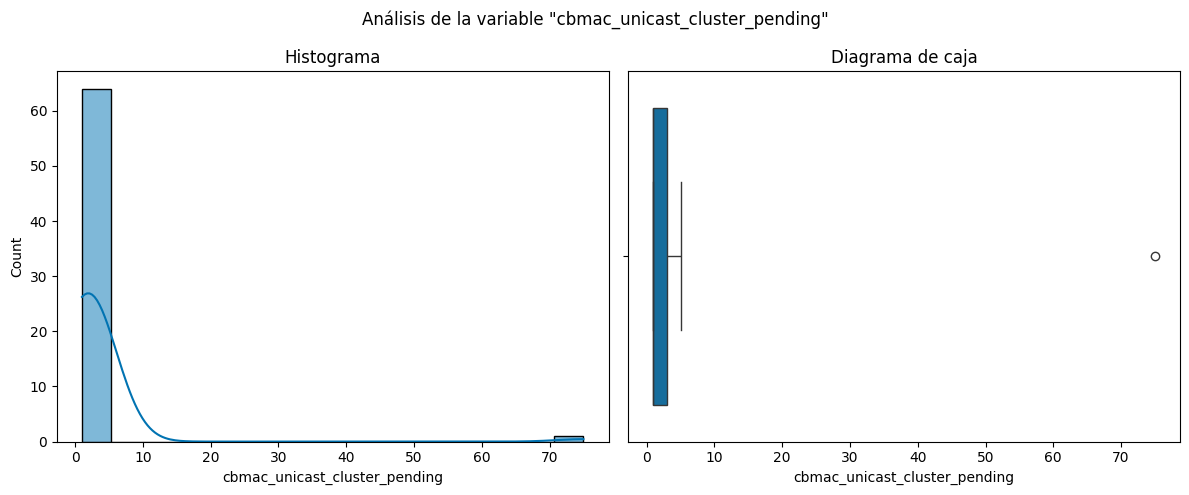

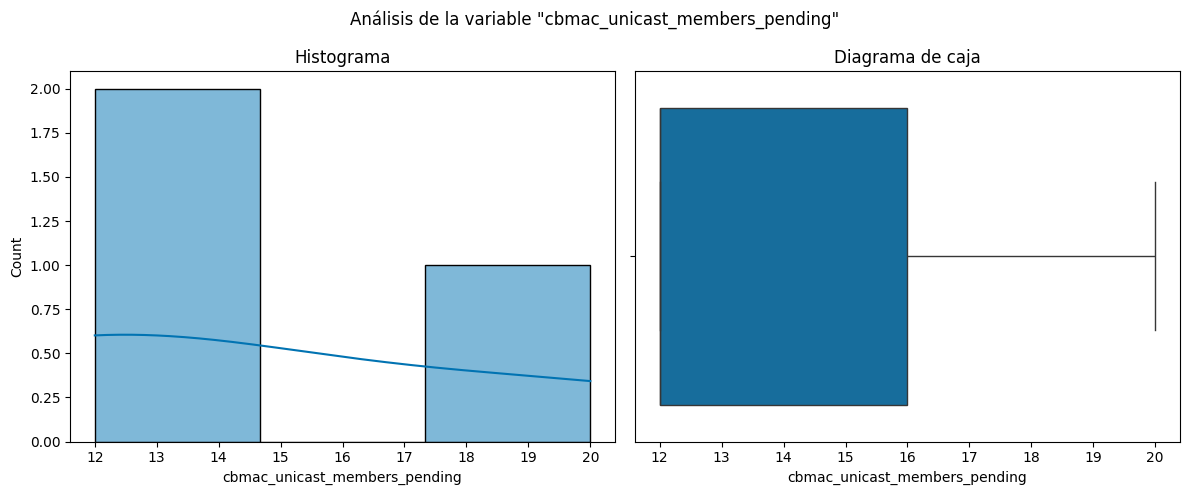

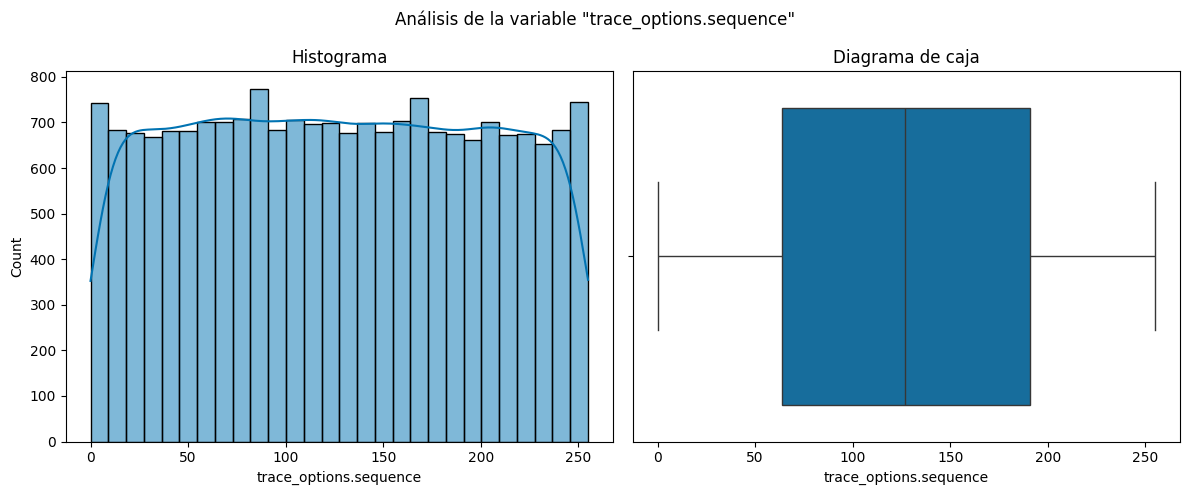

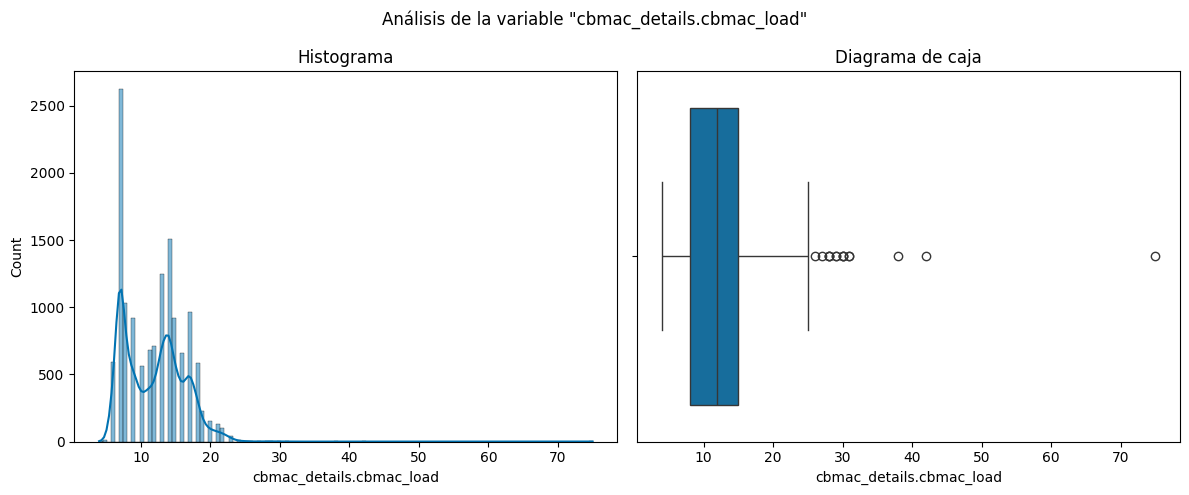

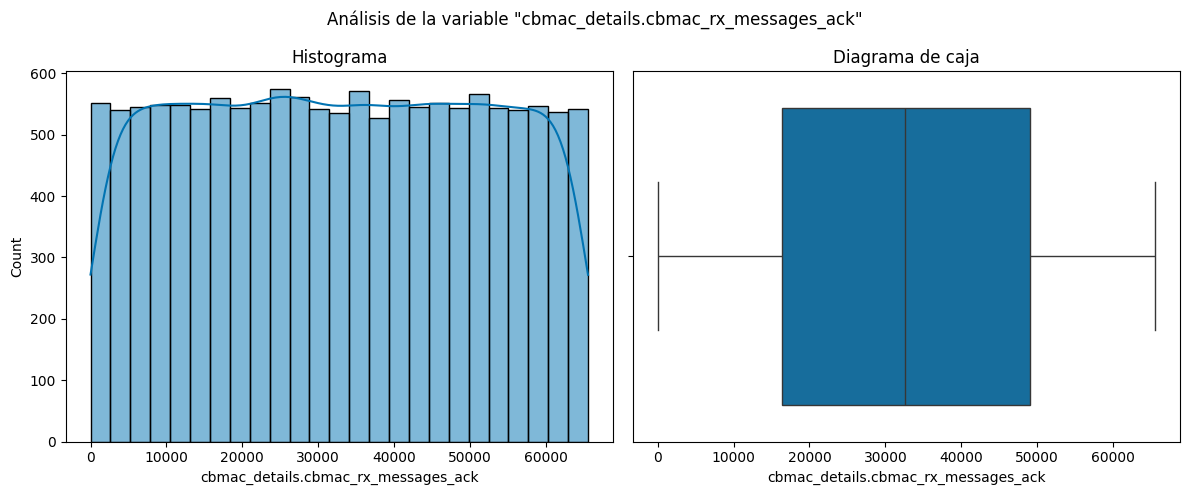

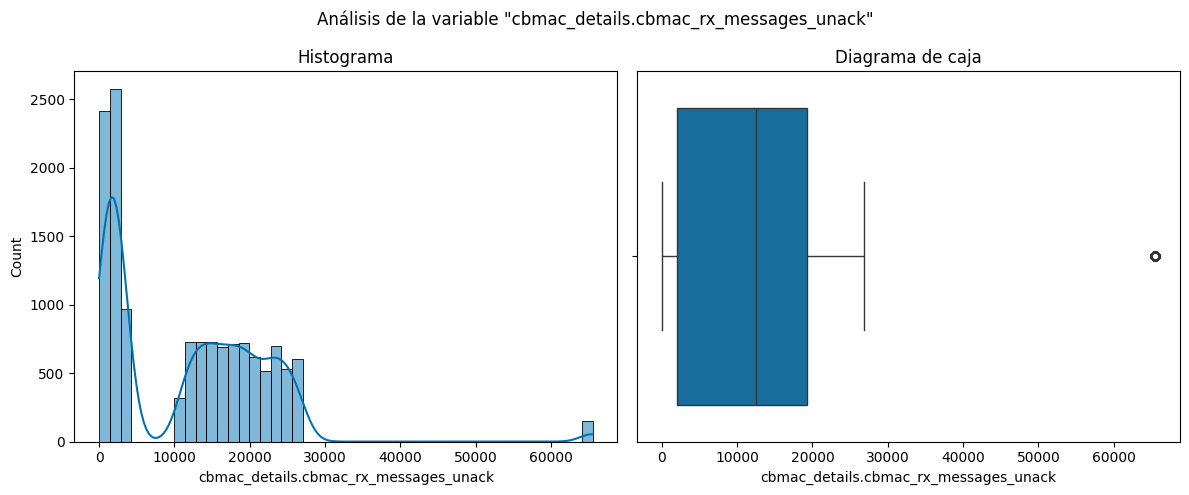

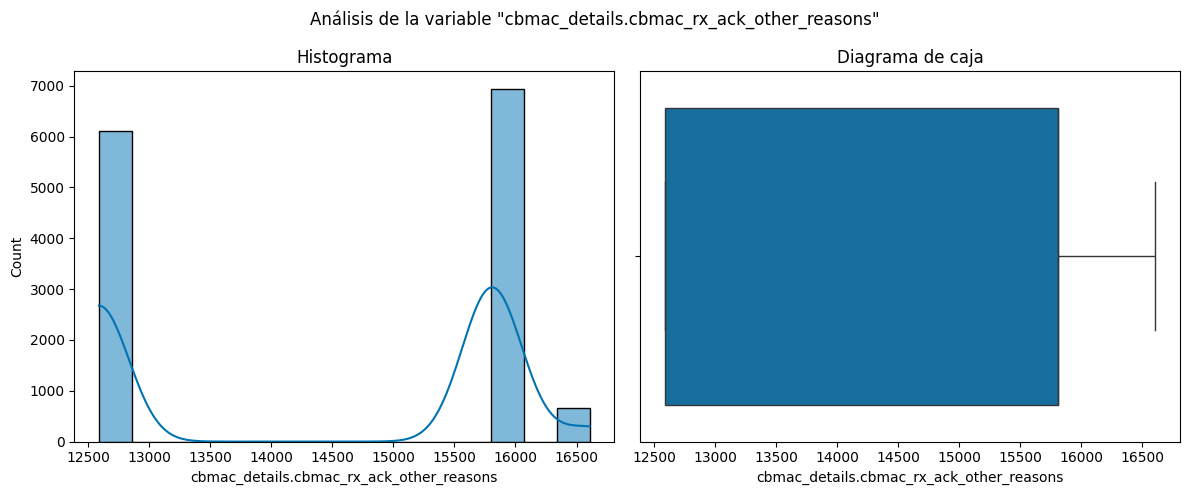

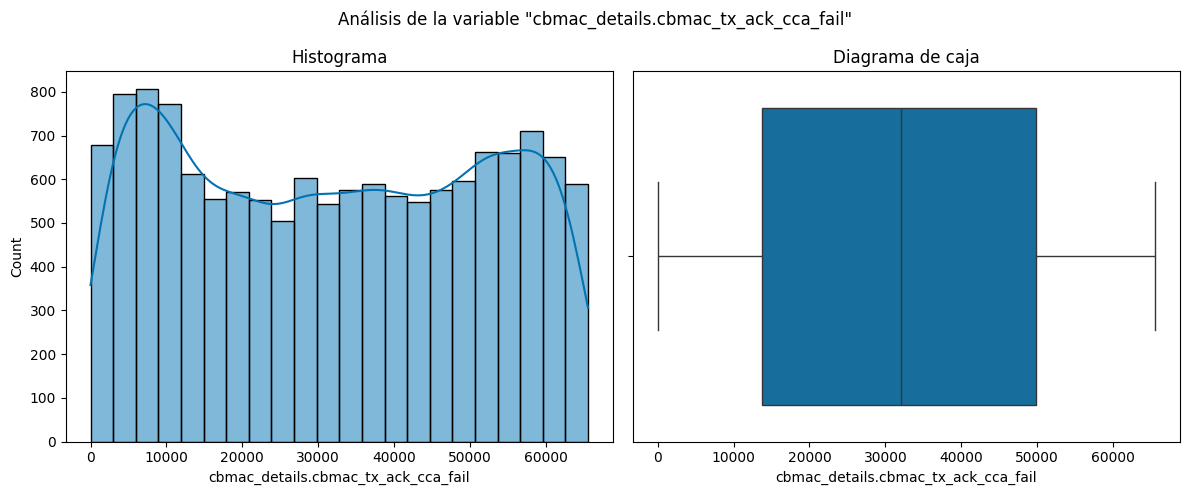

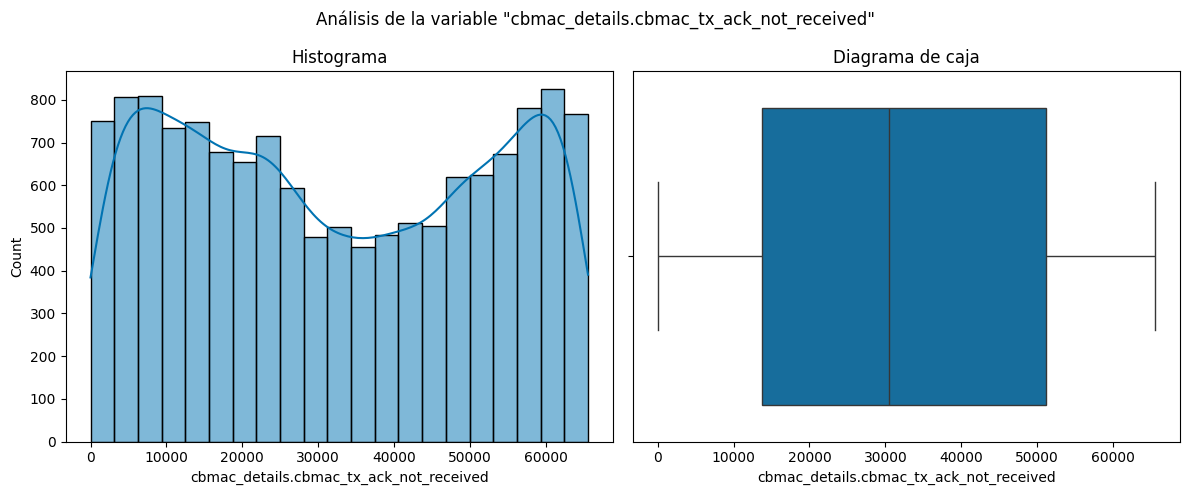

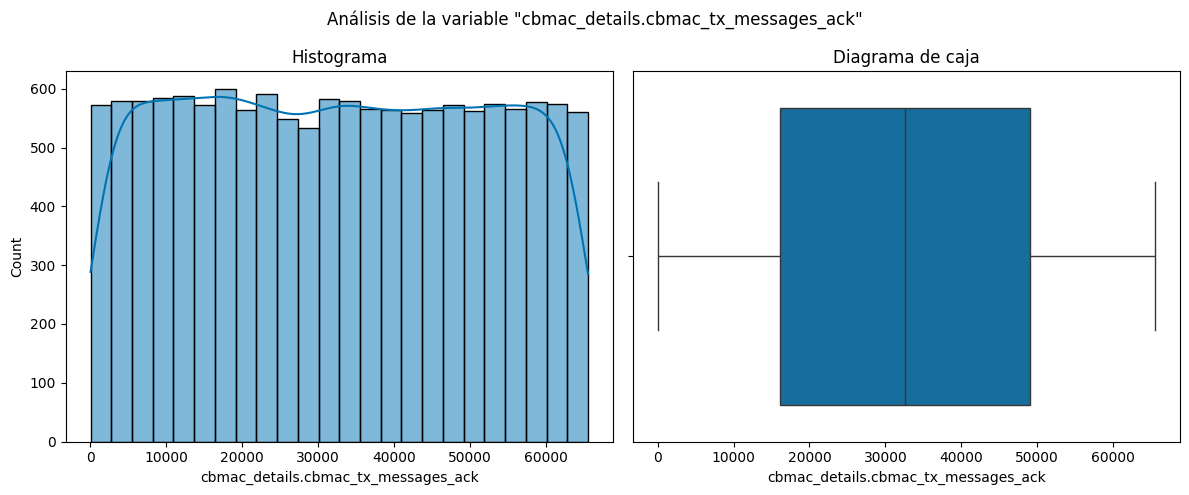

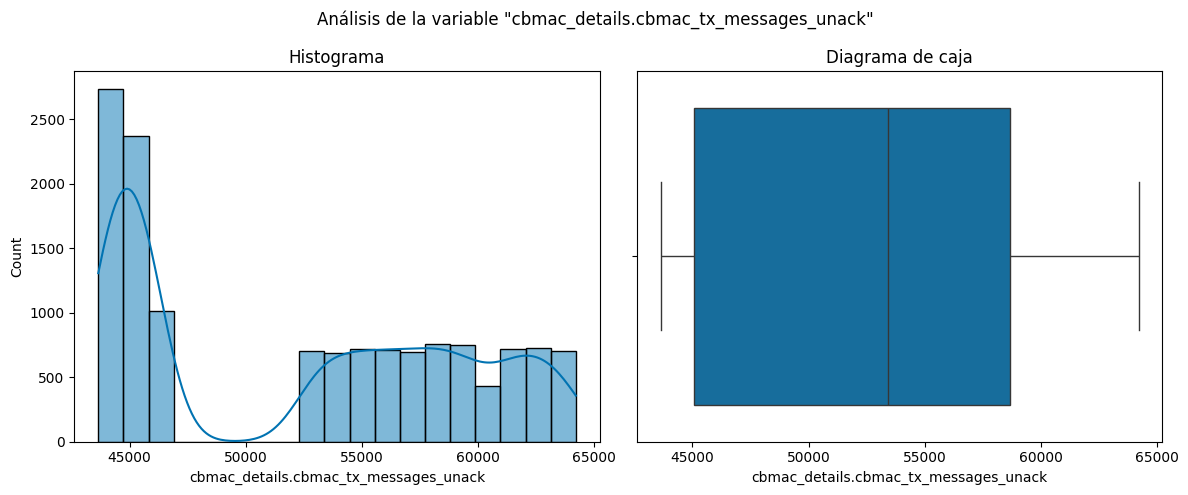

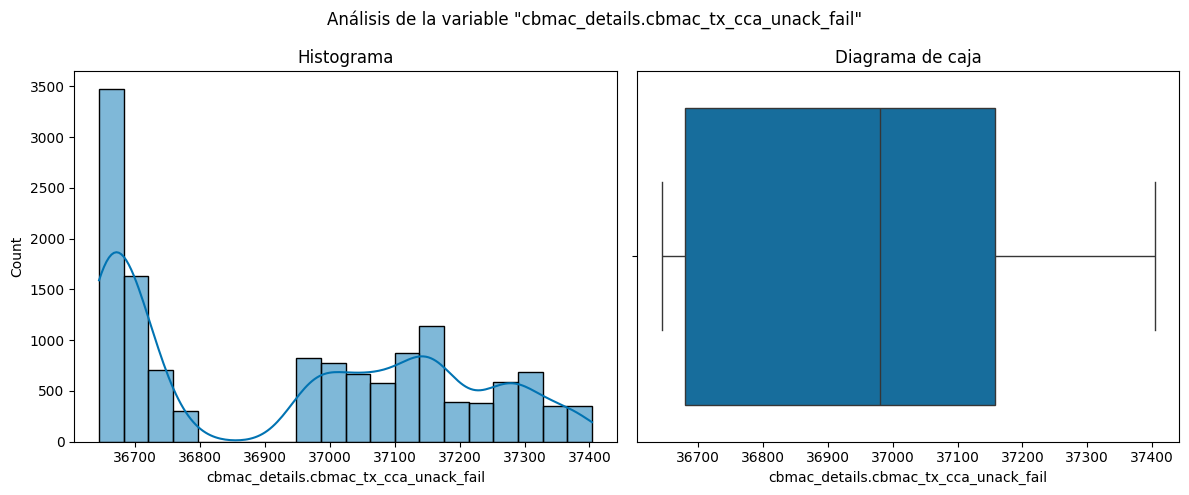

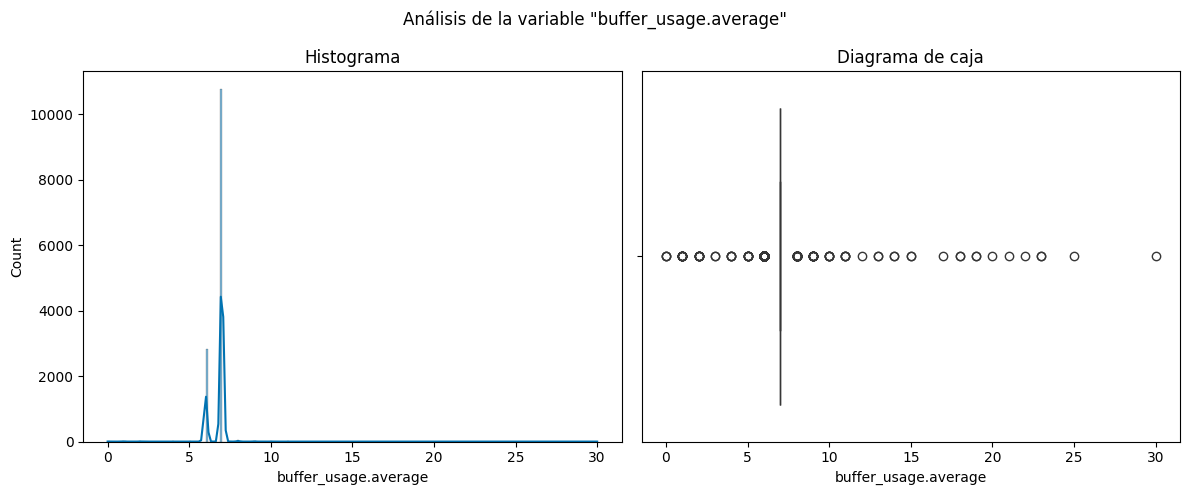

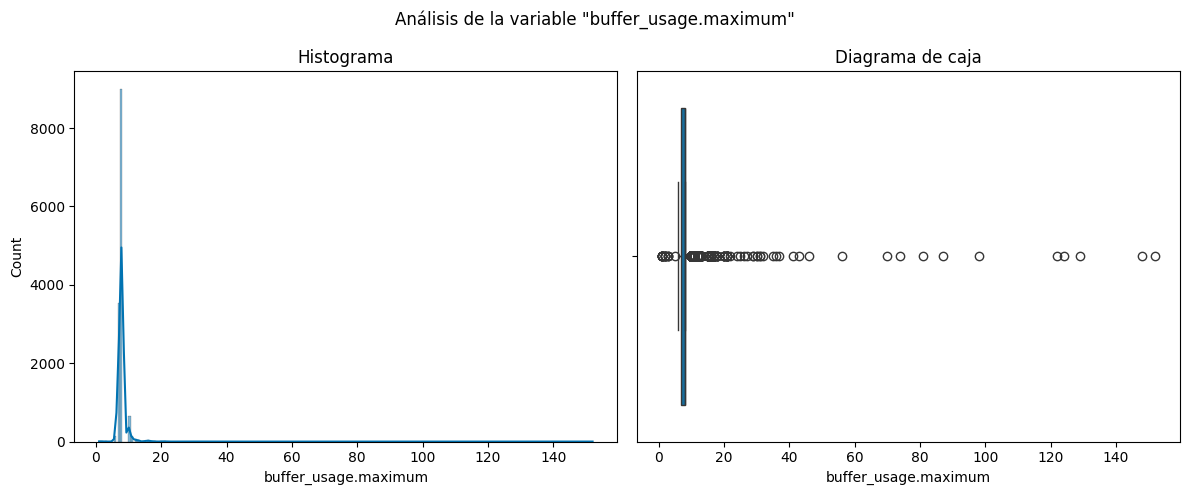

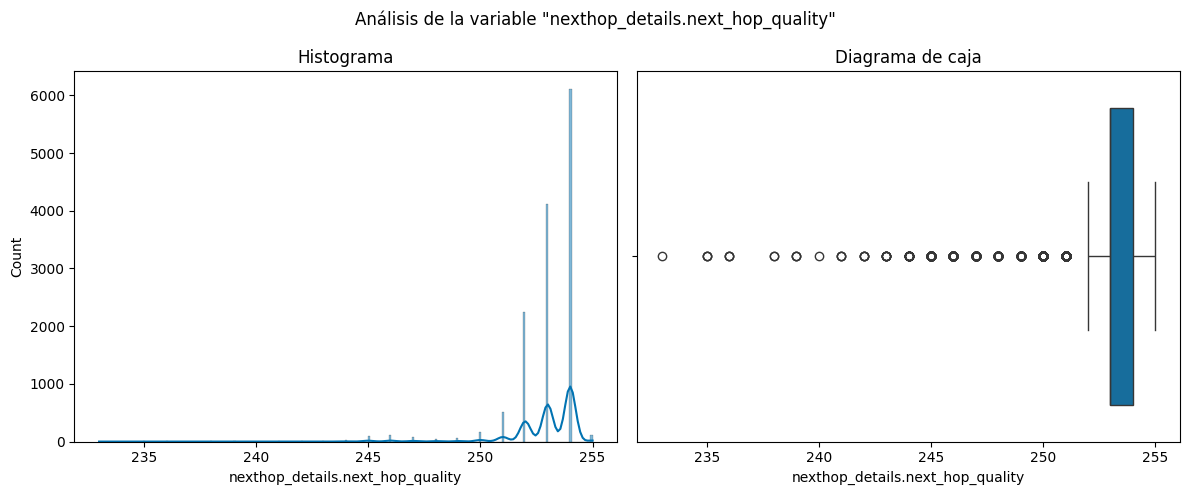

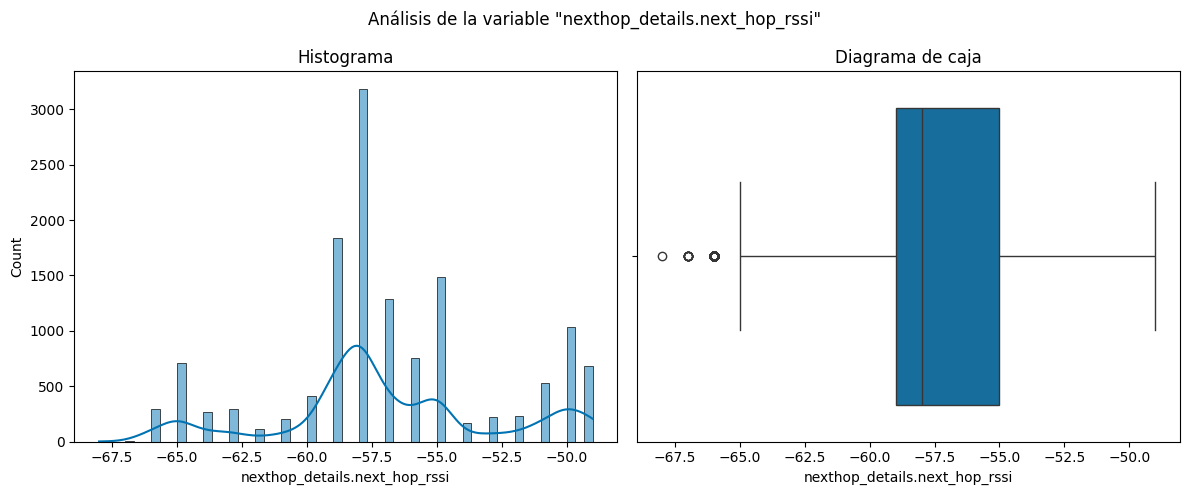

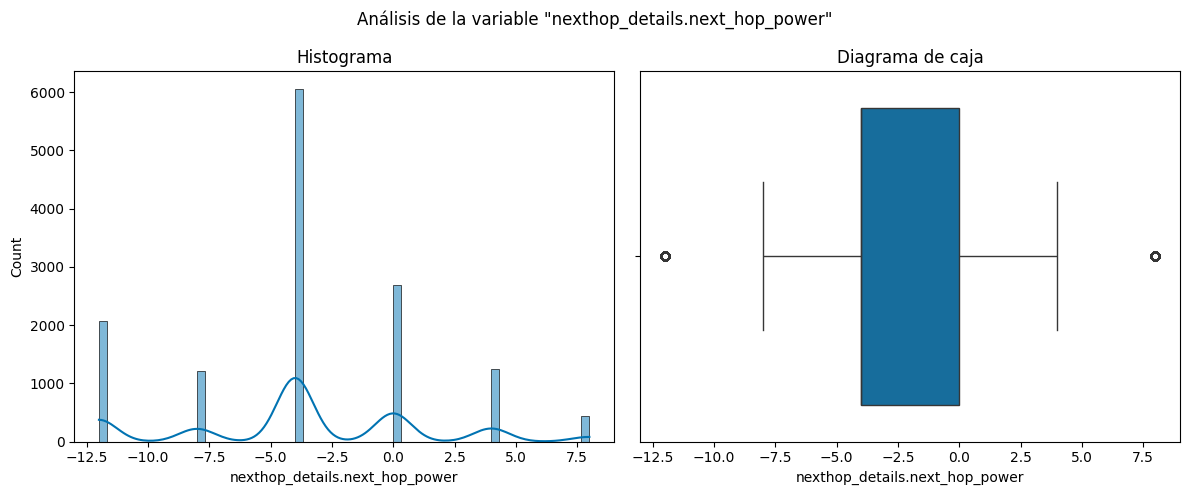

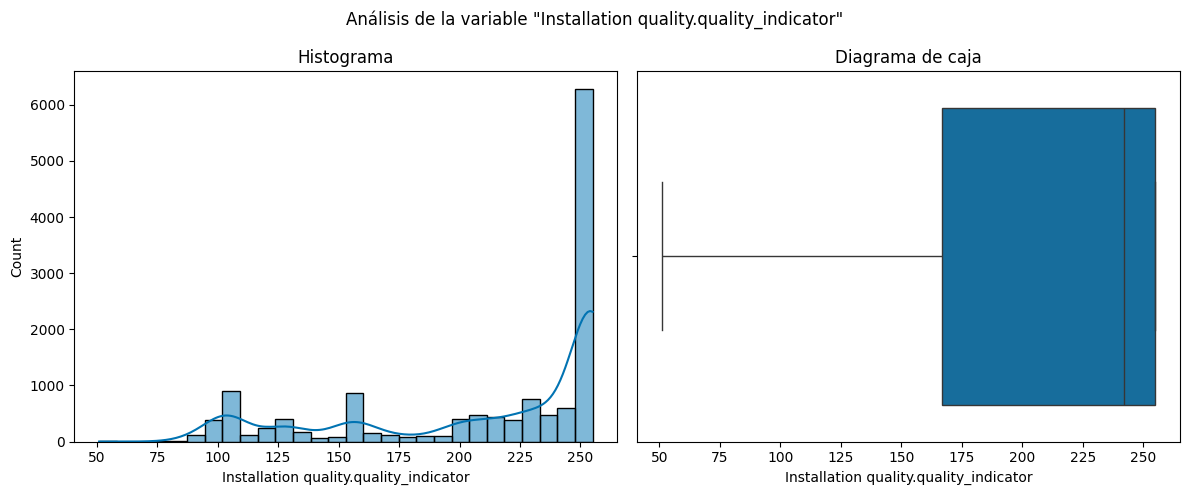

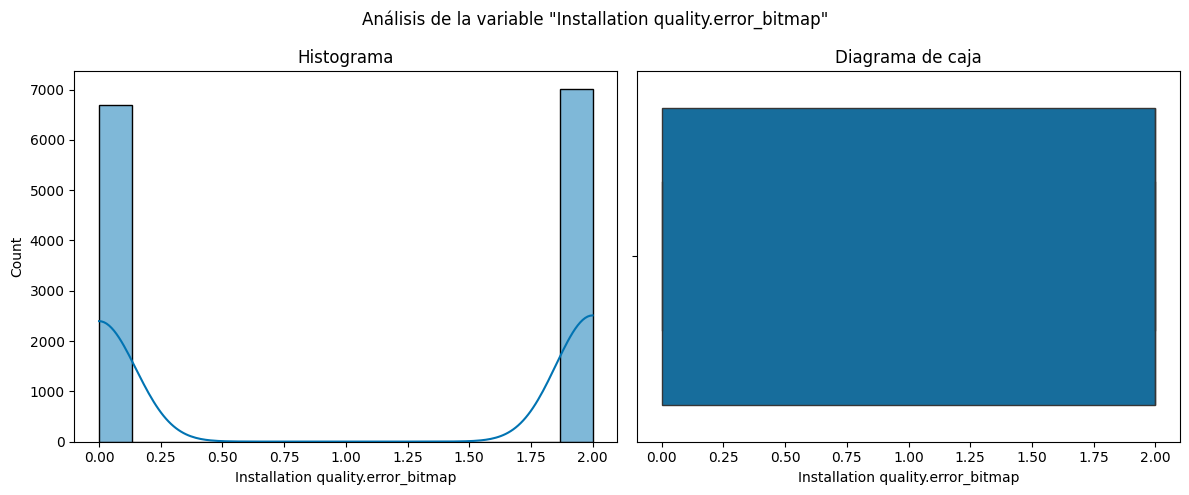

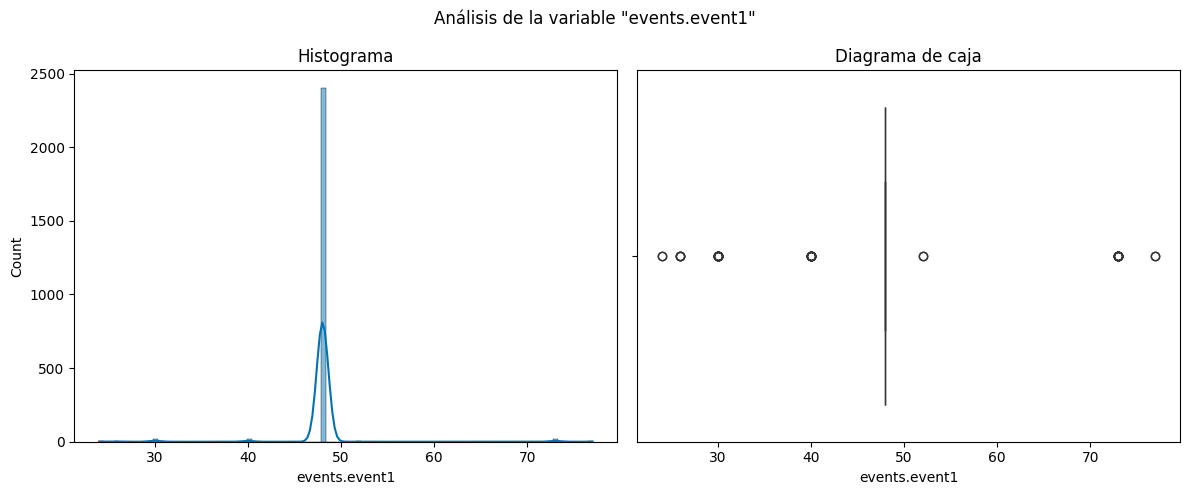

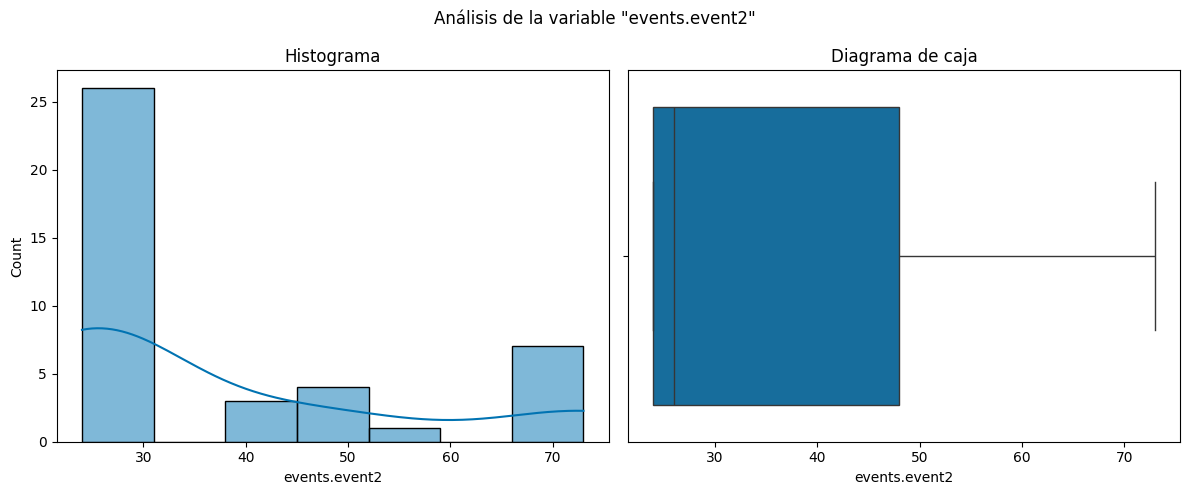

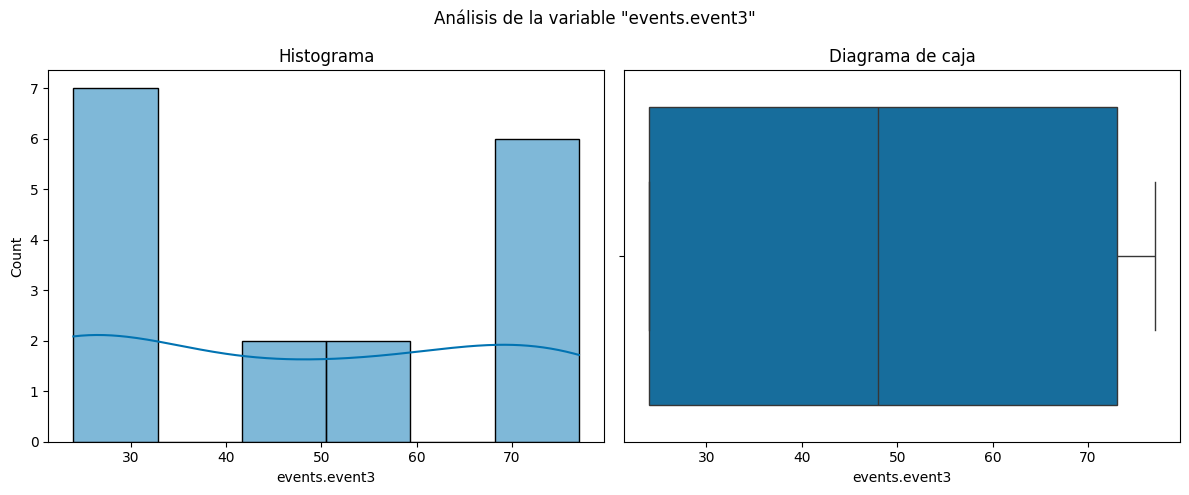

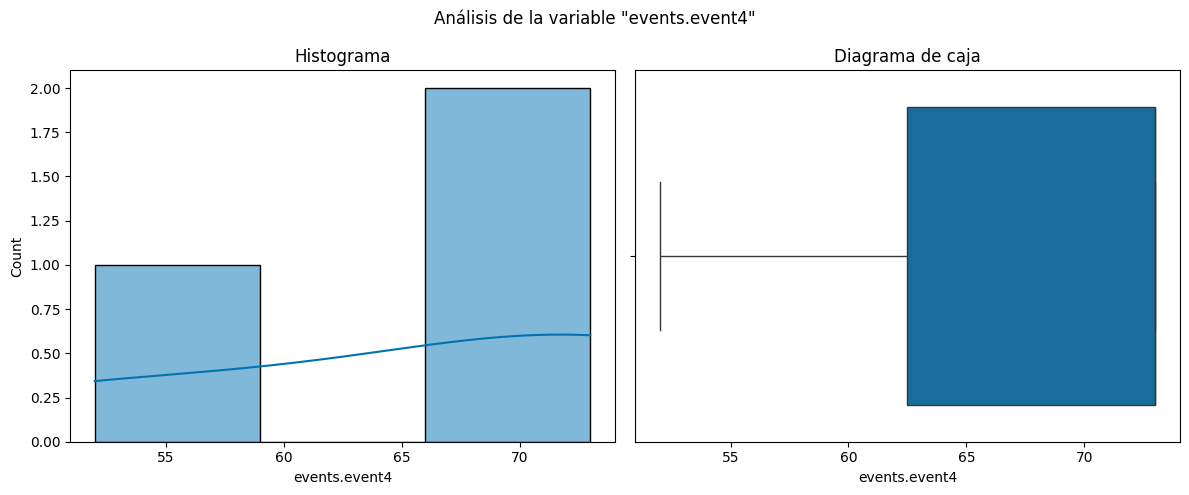

Columnas omitidas y razones:
- src: columna constante
- hops: columna constante
- inputState: columna constante
- error: columna constante
- hours_in_emergency: columna constante
- times_in_emergency: columna constante
- times_in_power: columna constante
- two_in_one_battery_level: columna constante
- configuration: columna constante
- last_hw_test_result: columna constante
- last_sw_test_result: columna constante
- pictogram: columna constante
- brightness: columna constante
- configured: columna constante
- sensors: columna constante
- device_type: columna constante
- error_code: columna constante
- model: columna constante
- battery_type: columna constante
- app_firmware_major: columna constante
- app_firmware_minor: columna constante
- app_firmware_maintenaince: columna constante
- app_firmware_devel: columna constante
- app_stack_major: columna constante
- app_stack_minor: columna constante
- app_stack_maintenaince: columna constante
- app_stack_devel: columna constante
- app_TFT_

In [15]:
X_src15 = X_train[X_train["src"] == 15]
skipped = {}
for column in numerical_features:
    try:
        # Extraer la columna
        x = X_src15[column]

        # Comprobar que queda más de 1 valor
        if len(x) < 2:
            skipped[column] = "menos de 2 valores"
            continue

        # Evitar columnas constantes (boxplot rompe si no varían)
        if x.nunique() < 2:
            skipped[column] = "columna constante"
            continue

        # Graficar
        plt.figure(figsize=(12,5))

        # Histograma
        plt.subplot(1, 2, 1)
        sns.histplot(x, kde=True)
        plt.title("Histograma")

        # Boxplot
        plt.subplot(1, 2, 2)
        sns.boxplot(x=x)
        plt.title("Diagrama de caja")

        plt.suptitle(f'Análisis de la variable \"{column}\"')
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"❌ Error en la columna '{column}': {e}")

print("Columnas omitidas y razones:")
for col, reason in skipped.items():
    print(f"- {col}: {reason}")

### 3.3. Análisis y manejo de valores faltantes

Ahora podemos usar `missingno` para visualizar la magnitud y la estructura de estas ausencias. En particular, usaremos **`msno.matrix()`**, que muestra una matriz de todo el conjunto de datos. Las barras negras representan datos presentes, y las **líneas blancas representan datos faltantes**. Nos permite ver patrones: ¿tienden a faltar valores en las mismas filas?

<Figure size 1500x500 with 0 Axes>

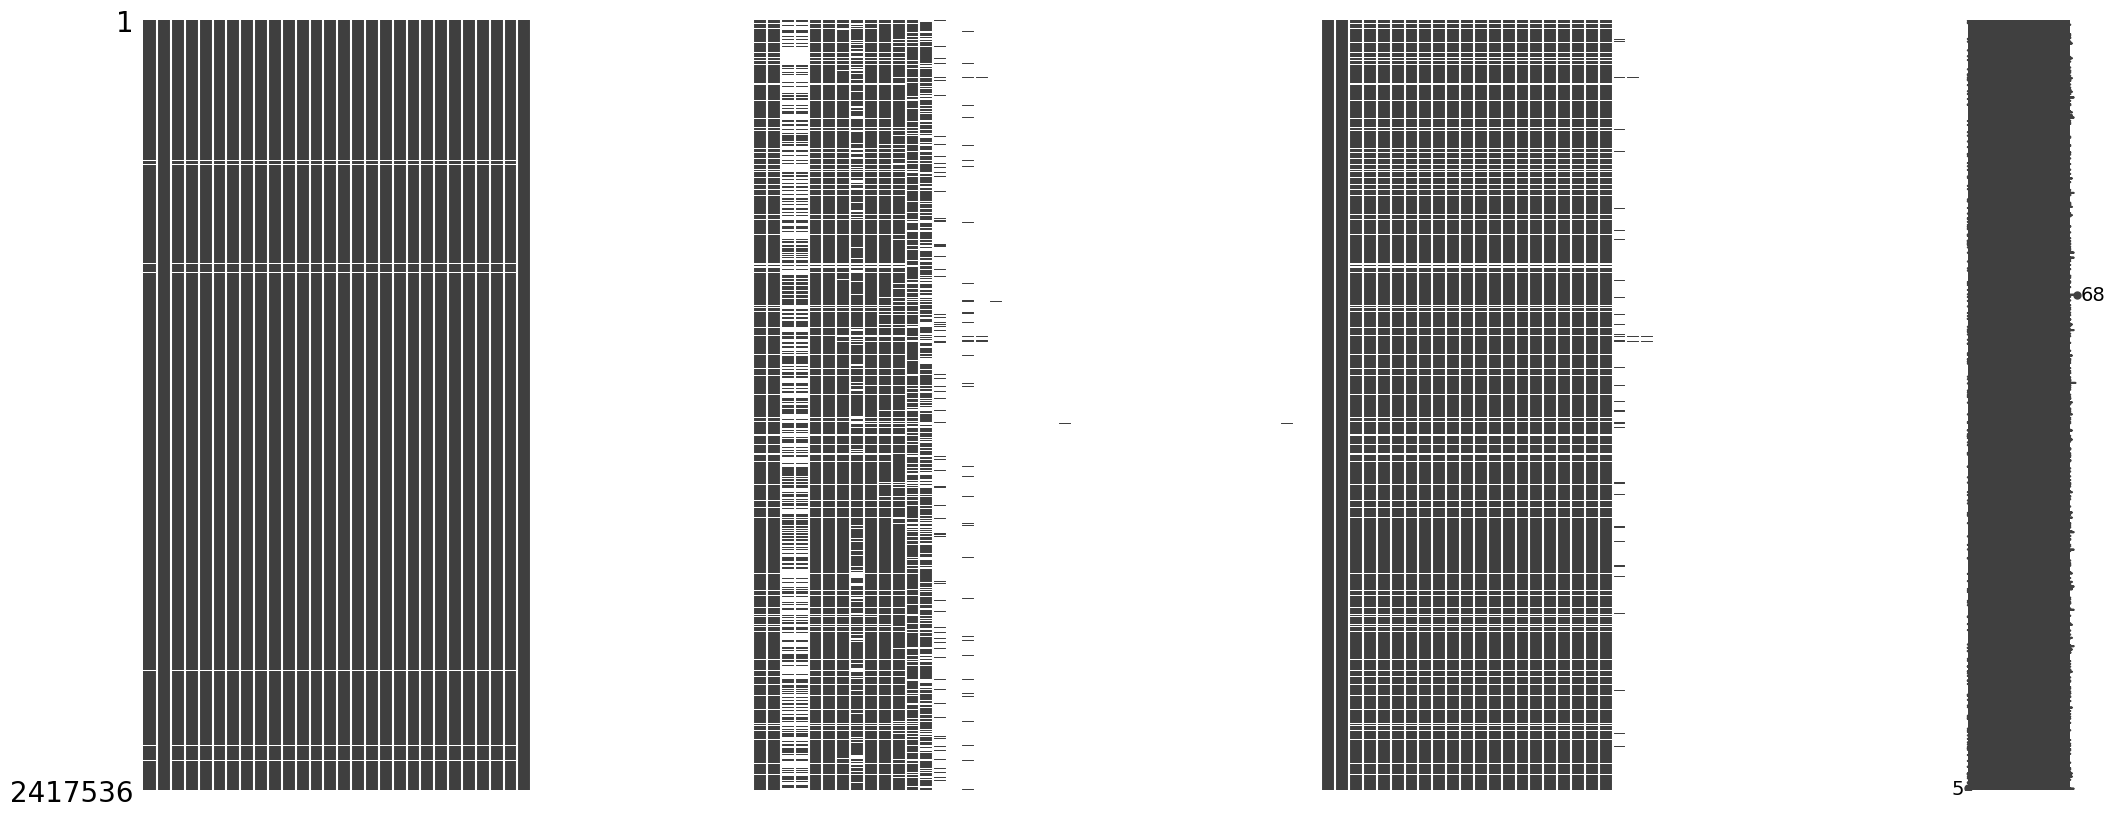

In [9]:
plt.figure(figsize=(15,5))  # aumentar tamaño horizontal
msno.matrix(X_train)
plt.xticks(rotation=45)      # rotar nombres de columnas
plt.show()

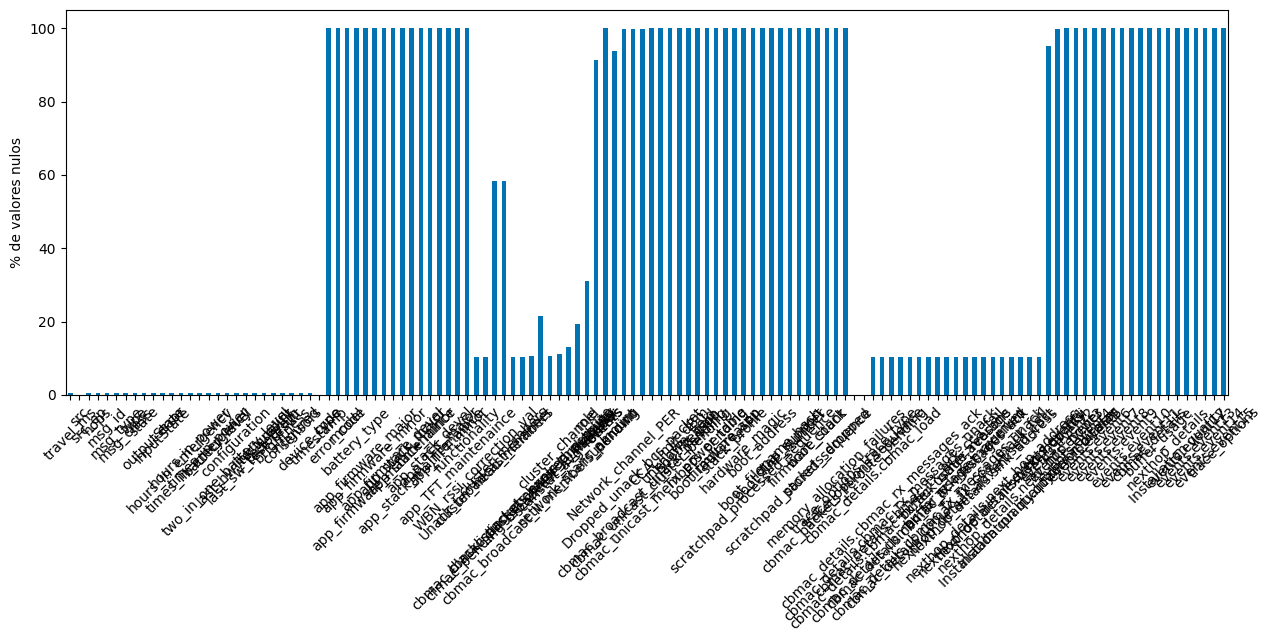

In [10]:
null_pct = X_train.isnull().mean() * 100
null_pct.plot(kind="bar", figsize=(15,5))
plt.ylabel("% de valores nulos")
plt.xticks(rotation=45)
plt.show()

In [10]:
null_pct = X_train.isnull().mean() * 100  # porcentaje de nulos
null_summary = null_pct.sort_values(ascending=False).reset_index()
null_summary.columns = ["Variable", "% Nulos"]

print("Resumen de valores nulos por columna:")
print(null_summary.to_string(index=False))

Resumen de valores nulos por columna:
                                Variable    % Nulos
                                  events 100.000000
                            buffer_usage 100.000000
                           cbmac_details 100.000000
                         nexthop_details 100.000000
                    Installation quality 100.000000
                           trace_options 100.000000
              memory_allocation_failures  99.999917
           cbmac_packets_reroute_pending  99.999710
                         packets_dropped  99.999669
                          events.event15  99.999090
                          events.event14  99.999007
                          events.event13  99.998883
                          events.event12  99.998800
                          hardware_magic  99.998759
                                 Rx_gain  99.998759
                             Boot_reason  99.998759
                          Tx_power_table  99.998759
                          

#### 3.2.2. Categóricas

Para las variables categóricas, no nos interesa la media o la mediana, sino:

* **Cardinalidad:** Cuántos valores únicos (`unique`) tiene cada una. Una cardinalidad alta (muchas categorías) puede ser problemática.
* **Frecuencia:** Cuál es el valor más frecuente (`top`) y cuántas veces aparece (`freq`).
* **Valores faltantes ocultos:** Si el valor más frecuente (`top`) o la lista de valores únicos revela la presencia de `"unknown"` u otros marcadores.

In [12]:
X_train['msg_class'] = X_train['msg_class'].astype('category')
X_train['msg_type'] = X_train['msg_type'].astype('category')
X_train['trace_options.trace_type'] = X_train['trace_options.trace_type'].astype('category')
X_train['configured'] = X_train['configured'].astype('category')
X_train['device_type'] = X_train['device_type'].astype('category')
X_train['error'] = X_train['error'].astype('category')
X_train['configuration'] = X_train['configuration'].astype('category')
X_train['inputState'] = X_train['inputState'].astype('category')
X_train['last_hw_test_result'] = X_train['last_hw_test_result'].astype('category')
X_train['last_sw_test_result'] = X_train['last_sw_test_result'].astype('category')
X_train['sensors'] = X_train['sensors'].astype('category')
X_train['pictogram'] = X_train['pictogram'].astype('category')
X_train['cbmac_packets_expired_pending'] = X_train['cbmac_packets_expired_pending'].astype('category')
X_train['Dropped_unack_bcs_packet'] = X_train['Dropped_unack_bcs_packet'].astype('category')
X_train['cbmac_broadcast_unack_pending'] = X_train['cbmac_broadcast_unack_pending'].astype('category')

include = ["object", "category"]  # Data types to include
categorical_features = X_train.select_dtypes(include=include).columns.tolist()
X_train[categorical_features].describe().T

,count,unique,top,freq
msg_type,2405118,2,0,2404487
msg_class,2405118,5,StatusData,2404487
type,2405118,5,StatusData,2404487
inputState,2404487,2,0,2265647
error,2404487,13,128,2090164
configuration,2404487,1,9,2404487
last_hw_test_result,2404487,1,0,2404487
last_sw_test_result,2404487,1,0,2404487
pictogram,2404487,5,0,2182189
configured,2404487,1,0,2404487


### 3.4. Detección de duplicados e inconsistencias

En esta etapa se identifican registros duplicados y se verifican inconsistencias básicas, como formatos incorrectos o valores fuera de los rangos esperados, con el fin de garantizar la calidad y coherencia del conjunto de datos. Dado que ya se realizó una revisión de los rangos durante la exploración inicial de las variables, no es necesario repetir este análisis en esta fase.

In [13]:
hashable_cols = [col for col in data.columns if data[col].apply(lambda x: isinstance(x, (int, float, str, type(None)))).all()]
duplicates = data[hashable_cols].duplicated()
num_duplicates = duplicates.sum()
print(f"Número de columnas hasheables {len(hashable_cols)}\nNúmero de filas duplicadas: {num_duplicates}")

Número de columnas hasheables 124
Número de filas duplicadas: 0


Tal como se observa, no existen registros duplicados en el conjunto de datos.

No obstante, también es posible identificar duplicados parciales, es decir, registros que comparten el mismo identificador pero presentan diferencias en otros campos.

In [14]:
# Detect duplicate indices
keep = False  # Mark all duplicates as "True"
mask = data.index.duplicated(keep=keep)
duplicated_indices = data.index[mask]

# Filter records with duplicate indices
duplicated_records = data.loc[duplicated_indices]

# Verify if, for each duplicated index, the records are different
# Group by index and check if there are multiple unique rows
level = 0  # Group by index level
function = lambda group: group.drop_duplicates().shape[0] > 1
grouped = duplicated_records.groupby(level=level).filter(function)

# Display the found records
print("Duplicados parciales (mismo índice, datos diferentes):")
grouped

Duplicados parciales (mismo índice, datos diferentes):


,travel_ms,src,src_ep,hops,msg_id,msg_type,msg_class,type,state,outputState,...,events.event11,cbmac_details,buffer_usage,nexthop_details,Installation quality,events.event12,events.event13,events.event14,events.event15,trace_options


## 4. Modificación dataset



Eliminamos los atributos que tienen como nulos más del 32% de los valores


In [62]:
null_over_32pct = null_pct[null_pct > 32].index.tolist()
print(f"Atributos totales: {len(X_train.columns)}\nAtributos con nulos < 32%:", len(X_train.columns) - len(null_over_32pct))
dropped_cols = set(null_over_32pct.copy())
dropped_cols


Atributos totales: 126
Atributos con nulos < 32%: 60


{'Boot_reason',
 'CCA_limit_dBm',
 'Dropped_unack_bcs_packet',
 'Installation quality',
 'Network_channel_PER',
 'Rx_gain',
 'Tx_power_table',
 'app_TFT_maintenaince',
 'app_TFT_major',
 'app_TFT_minor',
 'app_firmware_devel',
 'app_firmware_maintenaince',
 'app_firmware_major',
 'app_firmware_minor',
 'app_stack_devel',
 'app_stack_maintenaince',
 'app_stack_major',
 'app_stack_minor',
 'battery_type',
 'boot_address',
 'boot_count',
 'boot_fault_reason',
 'boot_filename_hash',
 'boot_line_number',
 'buffer_usage',
 'cbmac_broadcast_unack_pending',
 'cbmac_details',
 'cbmac_packets_reroute_pending',
 'cbmac_unicast_cluster_pending',
 'cbmac_unicast_members_pending',
 'cluster_head_members',
 'cluster_members',
 'code',
 'error_code',
 'events',
 'events.event1',
 'events.event10',
 'events.event11',
 'events.event12',
 'events.event13',
 'events.event14',
 'events.event15',
 'events.event2',
 'events.event3',
 'events.event4',
 'events.event5',
 'events.event6',
 'events.event7',
 'ev

Eliminamos los atributos que son constantes

In [63]:
const_cols = []
threshold = 1e-3

for col in X_train.columns:
    if col in ['src', 'timestamp']:   # columnas a ignorar
        continue
    
    try:
        # solo entra si los valores son hashables
        if X_train[col].std(skipna=True) < threshold or X_train[col].nunique() == 1:
            const_cols.append(col)
            
    except TypeError as e:
        # si hay listas u objetos no-hashables la saltamos
        print(f"Saltada columna: {col}\t{e}")
        continue

dropped_cols.update(const_cols)
print(f"Número de atributos constantes: {len(const_cols)}")
print("Número de atributos a eliminar: ",len(dropped_cols))
dropped_cols

Saltada columna: msg_class	could not convert string to float: 'StatusData'
Saltada columna: type	could not convert string to float: 'StatusData'
Saltada columna: unknown_field	setting an array element with a sequence.
Saltada columna: Tx_power_table	setting an array element with a sequence.
Saltada columna: firmware_app	could not convert string to float: '1.1.1.12'
Saltada columna: firmware_stack	could not convert string to float: '5.3.0.89'
Número de atributos constantes: 20
Número de atributos a eliminar:  73


{'Boot_reason',
 'CCA_limit_dBm',
 'Dropped_unack_bcs_packet',
 'Installation quality',
 'Network_channel_PER',
 'Rx_gain',
 'Tx_power_table',
 'app_TFT_maintenaince',
 'app_TFT_major',
 'app_TFT_minor',
 'app_firmware_devel',
 'app_firmware_maintenaince',
 'app_firmware_major',
 'app_firmware_minor',
 'app_stack_devel',
 'app_stack_maintenaince',
 'app_stack_major',
 'app_stack_minor',
 'battery_type',
 'boot_address',
 'boot_count',
 'boot_fault_reason',
 'boot_filename_hash',
 'boot_line_number',
 'buffer_usage',
 'cbmac_broadcast_unack_pending',
 'cbmac_details',
 'cbmac_packets_reroute_pending',
 'cbmac_unicast_cluster_pending',
 'cbmac_unicast_members_pending',
 'cluster_head_members',
 'cluster_members',
 'code',
 'configuration',
 'configured',
 'device_type',
 'error_code',
 'events',
 'events.event1',
 'events.event10',
 'events.event11',
 'events.event12',
 'events.event13',
 'events.event14',
 'events.event15',
 'events.event2',
 'events.event3',
 'events.event4',
 'events.

Al no haberse podido tratar msg_class, type, unkownk_field, Tx_power_table, firmware_app y firmware_stack se eliminarán por los siguientes motivos:

- msg_class: es practicamente coninua con 2405118 ocurrencias y apareciendo el mismo valor 2404487 veces -> 99,97% de entradas con el mismo valor
- type: es practicamente continua con 2405118 ocurrencias y apareciendo el mismo valor 2404487 veces -> 99,97% de entradas con el mismo valor
- unknownk_field: se desconoce que indica por lo que se eliminará para eliminar ruido
- Tx_power_table: todos sus valores son practicamente nulos con unicamente 30 apariciones no nulo -> 99,999% de valores nulos
- firmware_app: todos sus valores son practicamente nulos con unicamente 30 apariciones no nulo -> 99,999% de valores nulos
- firmware_stack: todos sus valores son practicamente nulos con unicamente 30 apariciones no nulo -> 99,999% de valores nulos



In [64]:
cols = ["msg_class", "type", "unknown_field", "Tx_power_table", "firmware_app", "firmware_stack"]
dropped_cols.update(cols)

Eliminamos los atributos que son casi consistentes

In [65]:
alm_const_cols = []
for col in X_train.columns:
    if col in ['src', 'timestamp']:   # columnas a ignorar
        continue
    
    try:
        top_freq = X_train[col].value_counts(normalize=True, dropna=False).max()
        if top_freq >= 0.95:
            print(f"Columna casi constante detectada: {col} (frecuencia máxima: {top_freq:.2%})")
            alm_const_cols.append(col)
    except TypeError as e:
        print(f"⚠️  Error en la columna '{col}': {e}")
        continue

dropped_cols.update(alm_const_cols)
print(f"Número de atributos casi constantes: {len(alm_const_cols)}")
dropped_cols

Columna casi constante detectada: src_ep (frecuencia máxima: 99.48%)
Columna casi constante detectada: msg_type (frecuencia máxima: 99.46%)
Columna casi constante detectada: msg_class (frecuencia máxima: 99.46%)
Columna casi constante detectada: type (frecuencia máxima: 99.46%)
Columna casi constante detectada: state (frecuencia máxima: 99.34%)
Columna casi constante detectada: two_in_one_battery_level (frecuencia máxima: 99.46%)
Columna casi constante detectada: configuration (frecuencia máxima: 99.46%)
Columna casi constante detectada: last_hw_test_result (frecuencia máxima: 99.46%)
Columna casi constante detectada: last_sw_test_result (frecuencia máxima: 99.46%)
Columna casi constante detectada: configured (frecuencia máxima: 99.46%)
Columna casi constante detectada: sensors (frecuencia máxima: 99.46%)
Columna casi constante detectada: device_type (frecuencia máxima: 99.46%)
Columna casi constante detectada: code (frecuencia máxima: 99.97%)
Columna casi constante detectada: error_co

{'Boot_reason',
 'CCA_limit_dBm',
 'Dropped_unack_bcs_packet',
 'Installation quality',
 'Network_channel_PER',
 'Rx_gain',
 'Tx_power_table',
 'app_TFT_maintenaince',
 'app_TFT_major',
 'app_TFT_minor',
 'app_firmware_devel',
 'app_firmware_maintenaince',
 'app_firmware_major',
 'app_firmware_minor',
 'app_stack_devel',
 'app_stack_maintenaince',
 'app_stack_major',
 'app_stack_minor',
 'battery_type',
 'boot_address',
 'boot_count',
 'boot_fault_reason',
 'boot_filename_hash',
 'boot_line_number',
 'buffer_usage',
 'cbmac_broadcast_unack_pending',
 'cbmac_details',
 'cbmac_packets_reroute_pending',
 'cbmac_unicast_cluster_pending',
 'cbmac_unicast_members_pending',
 'cluster_head_members',
 'cluster_members',
 'code',
 'configuration',
 'configured',
 'device_type',
 'error_code',
 'events',
 'events.event1',
 'events.event10',
 'events.event11',
 'events.event12',
 'events.event13',
 'events.event14',
 'events.event15',
 'events.event2',
 'events.event3',
 'events.event4',
 'events.

Por último eliminamos las variables que no aportan información relevante para la detección de anomalías como msg_id

In [66]:
cols = ['timestamp', 'nexthop_details.sink_address', 'msg_id']
dropped_cols.update(cols)

In [67]:
X_train_cleaned = X_train.drop(columns=dropped_cols)

Tratamos los valores nulos que aún existen en nuestro dataset

In [68]:
for _, row in null_summary.iterrows():
    if row['Variable'] in dropped_cols:
        continue
    if row['% Nulos'] < 32:
        X_train_cleaned[row['Variable']] = X_train_cleaned[row['Variable']].fillna(X_train_cleaned[row['Variable']].mode()[0])

Tratamos los valores extremos

In [69]:
factor = 10 # Es el valor tradicional recomendado por Tukey. Un valor más alto es más conservador y elimina menos outliers
num_atr = X_train_cleaned.select_dtypes(include=['number']).columns.tolist()

for col in num_atr:
    q1 = X_train_cleaned[col].quantile(0.25)
    q3 = X_train_cleaned[col].quantile(0.75)
    iqr = q3 - q1
    
    mask = (X_train_cleaned[col] >= q1 - factor*iqr) & (X_train_cleaned[col] <= q3 + factor*iqr) # Devuelve una mascara de booleanos que indica si el valor es o no un outlier
    X_train_cleaned = X_train_cleaned[mask] # Al aplicar la mascara se eliminan las columnas con false

Normalizamos los datos excepto por las características que son identificadores

In [71]:
cols_to_keep = ['src', 'nexthop_details.next_hop_address', 'cfmac_pending_broadcast_le_member', 'Unack_broadcast_channel']
cols_to_scale = [col for col in X_train_cleaned.columns if col not in cols_to_keep]


scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_train_cleaned[cols_to_scale]), columns=cols_to_scale)

X_train_cleaned = pd.concat([X_scaled, X_train_cleaned[cols_to_keep]], axis=1)

In [73]:
# Describimos el dataset modificado
print("Total number of atributes", len(X_train_cleaned.columns) - 1)  # restamos 2 por src y timestamp
attr = [c for c in X_train_cleaned.columns if c not in ['src']]
print("Final Attributes: ", attr)
print("Total number of records", len(X_train_cleaned))
pd.set_option('display.max_rows', None)      # muestra todas las filas
pd.set_option('display.max_columns', None)   # muestra todas las columnas
pd.set_option('display.width', 2000)         # ancho total para evitar saltos
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:.3f}'.format)
X_train_cleaned.describe().T

Total number of atributes 43
Final Attributes:  ['travel_ms', 'hops', 'outputState', 'inputState', 'error', 'hours_in_emergency', 'hours_in_power', 'times_in_emergency', 'times_in_power', 'battery_level', 'link_quality', 'pictogram', 'brightness', 'WBN_rssi_correction_val', 'cbmac_blacklisting_channels_min_to_40', 'cbmac_packets_expired_pending', 'cbmac_broadcast_ll_members_pending', 'cluster_channel_reliability', 'cluster_channel', 'scanstat_avg_routers', 'network_scans_amount', 'role', 'trace_options.sequence', 'cbmac_details.cbmac_load', 'cbmac_details.cbmac_rx_messages_ack', 'cbmac_details.cbmac_rx_messages_unack', 'cbmac_details.cbmac_rx_ack_other_reasons', 'cbmac_details.cbmac_tx_ack_cca_fail', 'cbmac_details.cbmac_tx_ack_not_received', 'cbmac_details.cbmac_tx_messages_ack', 'cbmac_details.cbmac_tx_messages_unack', 'cbmac_details.cbmac_tx_cca_unack_fail', 'buffer_usage.average', 'buffer_usage.maximum', 'nexthop_details.advertised_cost', 'nexthop_details.next_hop_quality', 'nextho

,count,mean,std,min,25%,50%,75%,max
travel_ms,239857.000,0.000,1.000,-1.131,-0.587,-0.298,0.282,8.760
hops,239857.000,0.000,1.000,-1.929,-0.933,0.062,0.560,4.044
outputState,239857.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
inputState,239857.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
error,239857.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
hours_in_emergency,239857.000,0.000,1.000,-0.803,-0.803,-0.803,1.013,2.980
hours_in_power,239857.000,0.000,1.000,-3.839,-0.054,0.263,0.349,1.561
times_in_emergency,239857.000,-0.000,1.000,-0.758,-0.758,-0.221,0.048,3.004
times_in_power,239857.000,-0.000,1.000,-1.098,-0.543,-0.543,0.289,3.340
battery_level,239857.000,0.000,1.000,-2.023,-0.544,0.010,0.749,8.326


Dataset para una única luminaria

In [74]:
counts = X_train['src'].value_counts()
for src, count in counts.items():
    print(f"Total number of records for lum {src} --> {count}")

Total number of records for lum 14 --> 83663
Total number of records for lum 110 --> 24708
Total number of records for lum 80 --> 24687
Total number of records for lum 49 --> 24483
Total number of records for lum 75 --> 24202
Total number of records for lum 187 --> 24198
Total number of records for lum 148 --> 24075
Total number of records for lum 39 --> 24055
Total number of records for lum 191 --> 23669
Total number of records for lum 89 --> 23605
Total number of records for lum 52 --> 23592
Total number of records for lum 152 --> 23283
Total number of records for lum 121 --> 23267
Total number of records for lum 157 --> 23262
Total number of records for lum 150 --> 23247
Total number of records for lum 24 --> 23042
Total number of records for lum 36 --> 22565
Total number of records for lum 85 --> 22496
Total number of records for lum 194 --> 22470
Total number of records for lum 184 --> 22454
Total number of records for lum 158 --> 22443
Total number of records for lum 193 --> 2238